<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/BC3/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

# Portfolio Replica Strategy

Two-file deliverable:

- `main.ipynb` — all analysis, plots and the deep-learning weight generator (Parts I & II).
- `harness.py` — the rolling-backtest engine, transaction-cost models, risk metrics and audit helpers (loaded via `from harness import *` in §0).

## Reading guide

**Part I** establishes the shared evaluation contract: identical `(X, y)`, dates, transaction-cost assumptions, risk limits and metrics. It produces the `results/pipeline_*` artifacts that every other model is benchmarked against.

**Part II** trains a deep-learning weight generator (`phi_t -> w_t`) and a transformer variant on the same inputs as Part I, then loads every member's `results/*.pkl` to build the master leaderboard.

## Shared contract (used by every model in this notebook)

- `X`: weekly returns of 11 futures in this exact order: `RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, DU1, TU2`.
- `y`: Monster Index weekly return: `0.50 * HFRXGL + 0.25 * MXWD + 0.25 * LEGATRUU`.
- `weights_history`: rebalance-date weights, with one column per future.
- `held_weights_history`: weekly forward-filled held weights used for PnL.
- `replica_returns`: gross replica returns.
- `replica_net`: net-of-transaction-cost replica returns.
- `metrics`: `IR, TE, rho, GE, VaR, turnover, net_IR, net_TE` plus audit extras.

A candidate model can enter the pipeline through either:
1. `run_rolling_backtest(X, y, model_factory, ...)` — trainable models; or
2. `evaluate_weights(X, y, weights_history, ...)` — pre-computed weights.


In [1]:
import hashlib
import json
import pickle
import sys
import time
import warnings
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, List, Literal, Optional, Protocol, Tuple, Union

# Scientific stack
import numpy as np
import pandas as pd
from numpy.linalg import LinAlgError
from scipy.stats import norm

from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, HuberRegressor, Lasso, LinearRegression, Ridge
from sklearn.preprocessing import MinMaxScaler

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import torch
import torch.nn as nn

# Project modules
from harness import *
from predict_then_optimize import (
    POConfig,
    alpha_from_linear_fit,
    shrunk_covariance,
    solve_po,
    top_k_active,
    run_predict_then_optimize_backtest,
)
from kalman import (
    KalmanConfig,
    kalman_run_full,
    run_kalman_replica,
    fit_em_noise,
    fit_hmm_regime,
    kf_metrics_row,
)

%config InlineBackend.figure_format = 'retina'


---

# Part I — Shared Pipeline Foundation


## Setup

This section defines the reusable evaluation harness used by the rest of the notebook. It is organised in small, labelled blocks so errors are easier to locate and the workflow is easier to audit.

The setup contains:
1. imports, constants and configuration;
2. data loading, cleaning and EDA helper functions;
3. transaction-cost, risk and metric utilities;
4. the rolling backtest and external-weight evaluation functions;
5. reporting, validation, sensitivity-check and export helpers;
6. notebook runtime settings such as plot style and output folder.

### Imports

All imports — standard library, scientific stack, and project modules (`harness`, `predict_then_optimize`, `kalman`) — are consolidated in the top code cell.


In [3]:
BASE = Path.cwd().resolve()
np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "legend.frameon": False,
})

OUT = BASE / "results"
OUT.mkdir(exist_ok=True)

PROJECT_STRESS_WINDOWS = {
    "Post-GFC recovery": ("2009-10-01", "2010-06-30"),
    "Eurozone crisis": ("2011-07-01", "2012-12-31"),
    "China/commodity shock": ("2015-06-01", "2016-02-29"),
    "2018 Q4 selloff": ("2018-10-01", "2018-12-31"),
    "Covid crash": ("2020-02-01", "2020-06-30"),
}

def shade_stress_windows(ax):
    for label, (start, end) in PROJECT_STRESS_WINDOWS.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08)
    return ax

## Data loading

**Goal.** Read the Bloomberg-style weekly Excel export and clean it into a price panel.

**Method.** `load_bloomberg_weekly` finds the `Ticker` header row automatically because the export has variable metadata above the data. `clean_price_panel` then sorts dates, removes duplicate dates, converts values to floats, drops fully empty rows/columns and rejects non-positive required prices.

**Important consistency point.** Prices are **not forward-filled** before return calculation. Forward-filling would manufacture artificial zero returns and understate volatility, tracking error and VaR. Missing required returns are removed only after the return panel is built.

In [4]:
DATA_PATH = BASE / "Dataset3_PortfolioReplicaStrategy.xlsx"
prices_raw = load_bloomberg_weekly(DATA_PATH)
prices = clean_price_panel(prices_raw)

print(f"Raw rows         : {prices_raw.shape[0]}")
print(f"After cleaning   : {prices.shape[0]}")
print(f"Date span        : {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Instruments      : {list(prices.columns)}")

Raw rows         : 705
After cleaning   : 705
Date span        : 2007-10-23 → 2021-04-20
Instruments      : ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL', 'RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']


## Build `(X, y)` per the shared contract

**Evaluation interface.**

* `X` = 11 futures weekly returns in the defined column order.
* `y` = Monster Index weekly return built from the index components: `0.50 * HFRXGL + 0.25 * MXWD + 0.25 * LEGATRUU`.
* Any externally supplied weights schedule evaluated through this pipeline must use this exact interface so results are comparable.

In [5]:
X, y = build_replication_panel(prices)
INPUT_HASH = hash_inputs(X, y)

print(f"X     : {X.shape}  (futures weekly returns)")
print(f"y     : {len(y)}    (Monster Index weekly returns)")
print(f"span  : {X.index.min().date()} → {X.index.max().date()}")
print(f"hash  : {INPUT_HASH}")

X     : (704, 11)  (futures weekly returns)
y     : 704    (Monster Index weekly returns)
span  : 2007-10-30 → 2021-04-20
hash  : 1b717ef92c122411


## EDA & data quality

**Goal.** Confirm that the panel is clean enough for backtesting and surface anything that needs flagging before any model is fit.

In [6]:
quality = data_quality_report(prices, X, y)
display(quality["missing_prices"].T)

,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2,HFRXGL,MXWD,LEGATRUU
missing_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
missing_pct,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
non_positive_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Annualised return statistics for X and y
def annualised_stats(s):
    return {
        "ann_ret": s.mean() * ANNUAL_FACTOR,
        "ann_vol": s.std()  * np.sqrt(ANNUAL_FACTOR),
        "skew":    s.skew(),
        "kurt":    s.kurt(),
        "max_dd":  max_drawdown(s),
    }
panel = X.join(y.rename("Monster_Index"))
ann = pd.DataFrame({c: annualised_stats(panel[c]) for c in panel.columns}).T
ann.style.format({"ann_ret": "{:+.2%}", "ann_vol": "{:.2%}",
                   "skew": "{:+.2f}", "kurt": "{:+.2f}", "max_dd": "{:.2%}"}) \
   .set_caption("Annualised return statistics — all 11 futures + Monster Index target")

,ann_ret,ann_vol,skew,kurt,max_dd
RX1,+3.20%,6.14%,-0.52,+1.61,10.39%
TY1,+1.50%,5.63%,-0.41,+3.09,12.90%
GC1,+7.85%,17.72%,+0.05,+3.47,43.18%
CO1,+6.51%,40.68%,+1.07,+16.38,86.26%
ES1,+8.83%,17.01%,-1.04,+5.17,55.11%
VG1,+1.49%,21.70%,-0.09,+3.60,58.15%
NQ1,+15.46%,19.43%,-0.94,+3.92,52.00%
LLL1,+0.53%,18.10%,-0.57,+25.94,64.87%
TP1,+4.10%,22.57%,-0.68,+5.15,56.29%
DU1,+0.60%,1.13%,-0.24,+5.20,2.77%


## Data Quality and Return Outlier Audit

**Goal.** Add a finance-appropriate outlier audit before model fitting. This is not an automatic outlier-removal step. Extreme weekly returns may be genuine market observations, so the pipeline flags them for review and keeps valid market events in the backtest.

**Method.** The audit uses robust z-scores based on the median absolute deviation (MAD). An observation is flagged when `|robust_z| >= 5`. The rule is deliberately diagnostic: invalid prices and missing required returns are removed by the cleaning and interface-building step, while valid extreme returns remain part of the realistic evaluation sample.

**Why this improves the pipeline.** A replication strategy that looks good only after deleting difficult observations is not credible. By keeping valid extreme observations, the backtest remains conservative and closer to a real portfolio-monitoring workflow.

In [8]:
outlier_audit = market_stress_outlier_audit(
    X,
    y,
    robust_z_threshold=5.0,
    top_n=25,
    stress_windows=PROJECT_STRESS_WINDOWS,
)

outlier_summary = outlier_audit["asset_summary"]
top_extreme_observations = outlier_audit["top_observations"]
robust_z_panel = outlier_audit["robust_z"]

outlier_summary.to_csv(OUT / "pipeline_outlier_audit_summary.csv")
top_extreme_observations.to_csv(OUT / "pipeline_top_extreme_observations.csv", index=False)

print("Outlier audit files exported:")
print(" -", OUT / "pipeline_outlier_audit_summary.csv")
print(" -", OUT / "pipeline_top_extreme_observations.csv")

display(
    outlier_summary.style.format({
        "extreme_pct": "{:.2%}",
        "max_abs_robust_z": "{:.2f}",
        "worst_weekly_return": "{:+.2%}",
        "best_weekly_return": "{:+.2%}",
        "annualised_vol": "{:.2%}",
        "skew": "{:+.2f}",
        "kurtosis": "{:+.2f}",
    }).set_caption("Market-stress outlier audit by series — flagged, not deleted")
)

display(
    top_extreme_observations.style.format({
        "weekly_return": "{:+.2%}",
        "robust_z": "{:+.2f}",
        "abs_robust_z": "{:.2f}",
    }).set_caption("Largest robust-z weekly return observations")
)


Outlier audit files exported:
 - /Users/pengrao/Workspace/Fintech/BC3/results/pipeline_outlier_audit_summary.csv
 - /Users/pengrao/Workspace/Fintech/BC3/results/pipeline_top_extreme_observations.csv


,observations,extreme_count,extreme_pct,max_abs_robust_z,worst_weekly_return,worst_week_date,best_weekly_return,best_week_date,annualised_vol,skew,kurtosis
DU1,704,23,3.27%,9.93,-0.85%,2009-06-09,+0.69%,2011-07-12,1.13%,-0.24,+5.20
TU2,704,13,1.85%,7.28,-0.84%,2008-06-10,+0.83%,2008-10-07,1.27%,-0.09,+4.62
ES1,704,7,0.99%,9.19,-13.96%,2008-10-07,+8.76%,2009-03-17,17.01%,-1.04,+5.17
CO1,704,6,0.85%,12.98,-34.70%,2020-04-21,+51.37%,2020-05-05,40.68%,+1.07,+16.38
Monster_Index,704,6,0.85%,9.98,-6.72%,2020-03-17,+3.62%,2008-11-04,6.41%,-1.32,+7.55
TP1,704,6,0.85%,7.77,-18.10%,2011-03-15,+15.31%,2008-11-04,22.57%,-0.68,+5.15
NQ1,704,5,0.71%,8.38,-16.70%,2008-10-07,+8.49%,2020-04-14,19.43%,-0.94,+3.92
TY1,704,4,0.57%,7.28,-4.27%,2008-10-14,+3.37%,2008-12-02,5.63%,-0.41,+3.09
VG1,704,3,0.43%,7.69,-13.59%,2020-03-17,+18.36%,2008-11-04,21.70%,-0.09,+3.60
GC1,704,3,0.43%,6.69,-12.57%,2013-04-16,+14.00%,2008-09-23,17.72%,+0.05,+3.47


,date,series,weekly_return,robust_z,abs_robust_z,regime_label
74,2020-05-05,CO1,+51.37%,+12.98,12.98,Covid crash
72,2020-04-07,CO1,+40.15%,+10.13,10.13,Covid crash
71,2020-03-17,Monster_Index,-6.72%,-9.98,9.98,Covid crash
40,2009-06-09,DU1,-0.85%,-9.93,9.93,ordinary/non-labelled week
13,2008-10-07,ES1,-13.96%,-9.19,9.19,ordinary/non-labelled week
73,2020-04-21,CO1,-34.70%,-8.89,8.89,Covid crash
3,2008-04-22,DU1,-0.75%,-8.84,8.84,ordinary/non-labelled week
67,2020-03-17,ES1,-12.92%,-8.52,8.52,Covid crash
14,2008-10-07,NQ1,-16.70%,-8.38,8.38,ordinary/non-labelled week
52,2011-07-12,DU1,+0.69%,+7.89,7.89,Eurozone crisis


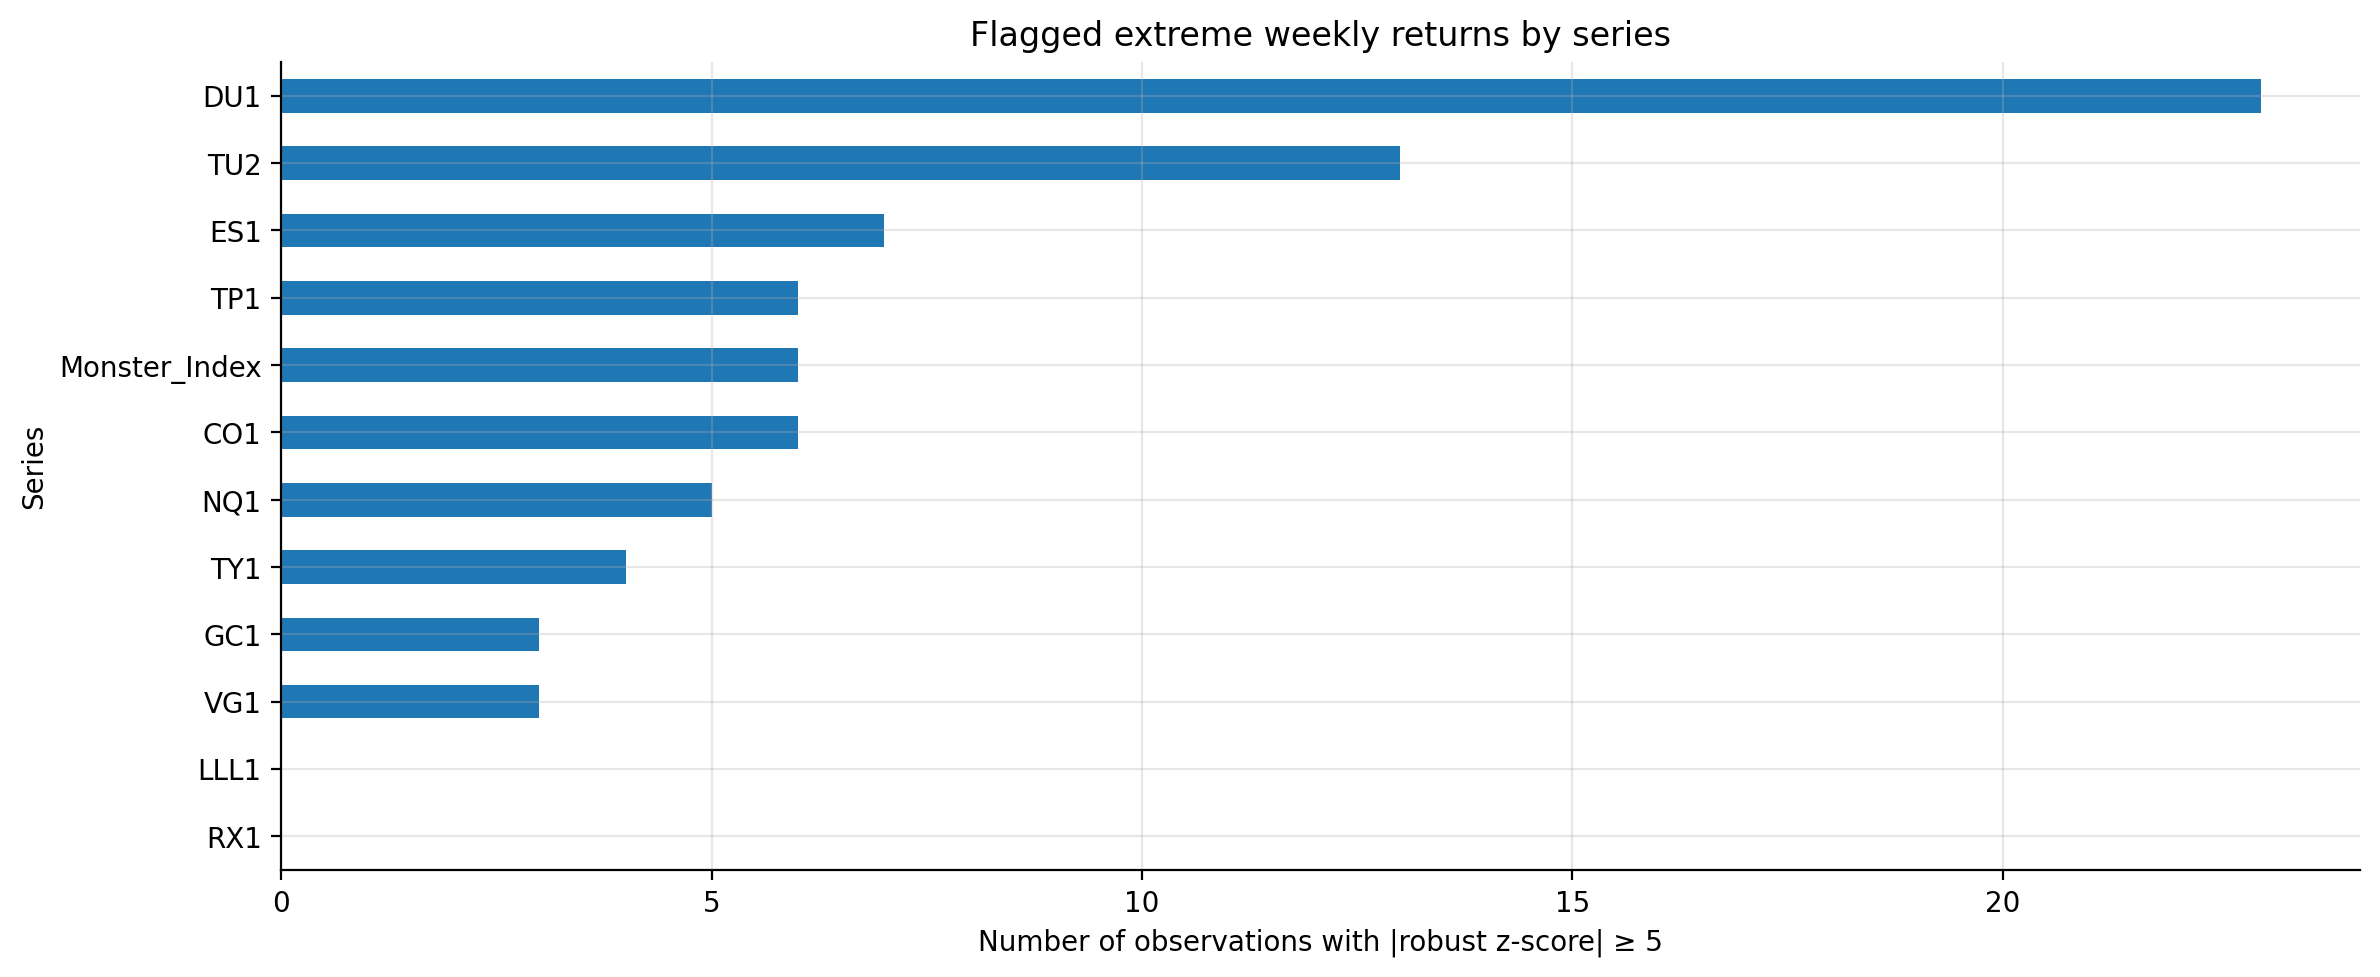

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
outlier_summary["extreme_count"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Flagged extreme weekly returns by series")
ax.set_xlabel("Number of observations with |robust z-score| ≥ 5")
ax.set_ylabel("Series")
plt.tight_layout()
plt.show()

**Graph explanation.** This chart shows which instruments have the largest number of robustly flagged extreme weekly returns. A high count does not mean the series is "bad" or should be removed. It means the instrument has more large weekly moves and should be monitored carefully when interpreting tracking error, VaR and transaction-cost results.

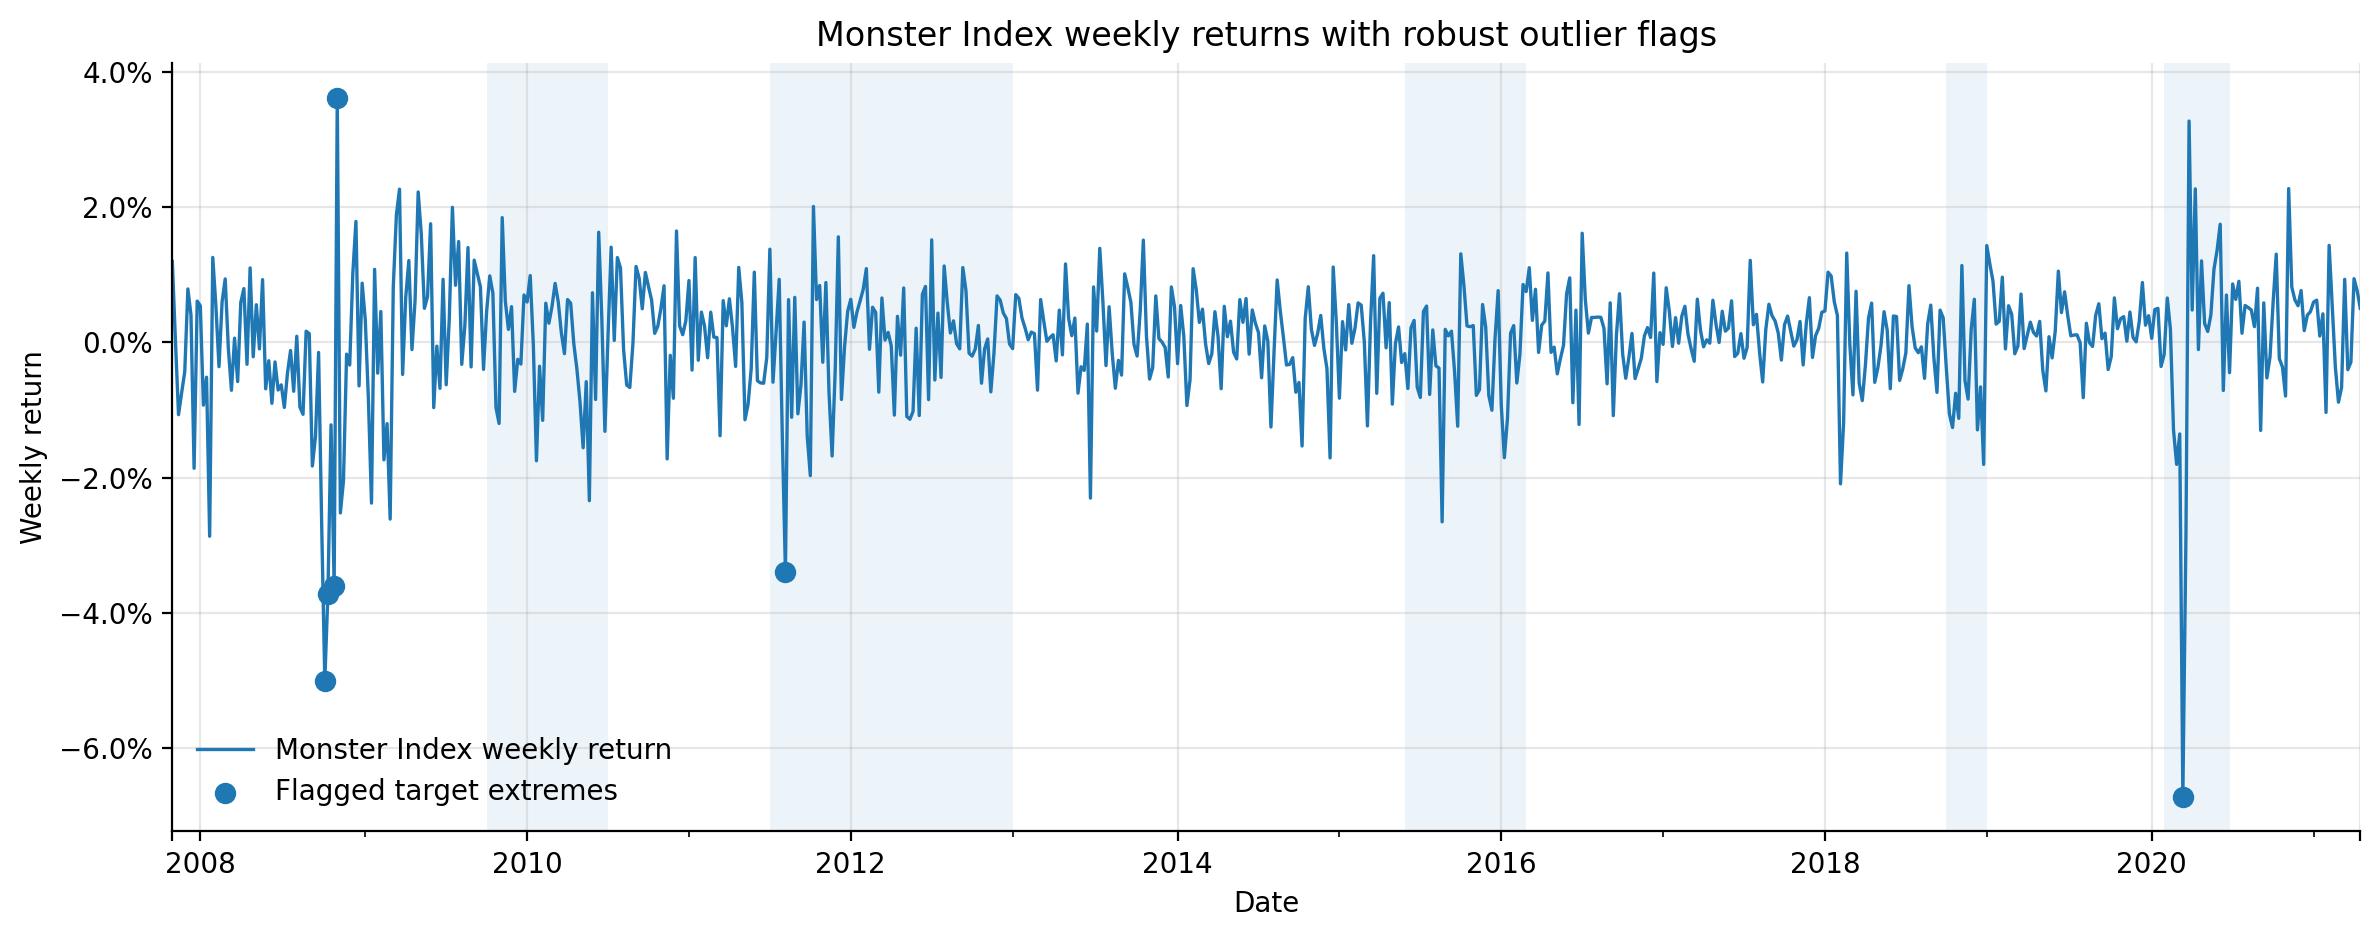

In [10]:
panel_returns = X.join(y.rename("Monster_Index"))
target_extreme_dates = robust_z_panel.index[robust_z_panel["Monster_Index"].abs() >= 5.0]

fig, ax = plt.subplots(figsize=(12, 4.8))
panel_returns["Monster_Index"].plot(ax=ax, linewidth=1.2, label="Monster Index weekly return")
if len(target_extreme_dates):
    ax.scatter(
        target_extreme_dates,
        panel_returns.loc[target_extreme_dates, "Monster_Index"],
        s=45,
        label="Flagged target extremes",
        zorder=3,
    )
shade_stress_windows(ax)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Monster Index weekly returns with robust outlier flags")
ax.set_ylabel("Weekly return")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


**Graph explanation.** The line shows the target Monster Index weekly return through time. The markers identify weeks flagged by the robust z-score rule. These points are intentionally **kept** in the sample because they are valid observations that a real portfolio replica would have had to experience.

**Audit decision rule.** The pipeline removes only invalid inputs such as missing required returns or non-positive required prices. It does **not** delete valid extreme returns. The audit therefore strengthens the credibility of the backtest: the strategy is evaluated on the full valid sample rather than on an artificially smoothed sample.

## Feature relevance

**Goal.** Identify which futures are most useful as replicating instruments before any model is fit.

**Method.**
* `corr_to_target` — direct linear association.
* `single_future_beta` — the OLS β if only that one future were used to track the target.
* `single_future_TE` — the annualised tracking error of that single-future replica.

A future with high `|corr|` and low `single_future_TE` is structurally important. A future with very low correlation may still be useful in a multi-asset model through hedging, so nothing is dropped based only on this table.

In [11]:
rows = []
for c in X.columns:
    x = X[c]
    beta = float(x.cov(y) / x.var(ddof=1)) if x.var(ddof=1) > 0 else np.nan
    replica = beta * x
    active = replica - y
    rows.append({
        "future": c,
        "corr_to_target":     float(x.corr(y)),
        "abs_corr":           float(abs(x.corr(y))),
        "single_future_beta": beta,
        "single_future_TE":   float(active.std(ddof=1) * np.sqrt(ANNUAL_FACTOR)),
    })
relevance = pd.DataFrame(rows).sort_values("abs_corr", ascending=False).reset_index(drop=True)
relevance.style.format({
    "corr_to_target": "{:+.3f}", "abs_corr": "{:.3f}",
    "single_future_beta": "{:+.3f}", "single_future_TE": "{:.2%}",
}).set_caption("Feature relevance — sorted by |correlation| with target")

,future,corr_to_target,abs_corr,single_future_beta,single_future_TE
0,ES1,+0.828,0.828,+0.312,3.60%
1,NQ1,+0.739,0.739,+0.244,4.32%
2,VG1,+0.728,0.728,+0.215,4.40%
3,TP1,+0.602,0.602,+0.171,5.12%
4,LLL1,+0.512,0.512,+0.182,5.51%
5,CO1,+0.447,0.447,+0.070,5.73%
6,DU1,-0.262,0.262,-1.487,6.19%
7,GC1,+0.227,0.227,+0.082,6.24%
8,TU2,-0.150,0.150,-0.761,6.34%
9,RX1,-0.129,0.129,-0.135,6.36%


**Multicollinearity.** Several futures cover similar exposures; for example, `RX1` and `DU1` both represent German rates, while `ES1`, `VG1` and `NQ1` all represent developed-market equity exposure. Any linear modelling approach must handle this, so the notebook measures it with VIF before fitting the rolling model.

In [12]:
# Variance Inflation Factor — high VIF (> 5-10) signals multicollinearity

def compute_vif(X_df: pd.DataFrame) -> pd.Series:
    Xc = X_df.values
    n = Xc.shape[1]
    vifs = []
    for i in range(n):
        y_i = Xc[:, i]
        X_others = np.delete(Xc, i, axis=1)
        try:
            beta, *_ = np.linalg.lstsq(X_others, y_i, rcond=None)
            resid = y_i - X_others @ beta
            ss_res = np.sum(resid**2)
            ss_tot = np.sum((y_i - y_i.mean())**2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            vif = 1 / (1 - r2) if r2 < 1 else np.inf
        except LinAlgError:
            vif = np.nan
        vifs.append(vif)
    return pd.Series(vifs, index=X_df.columns, name="VIF").sort_values(ascending=False)

vif = compute_vif(X)
display(vif.to_frame().style.format("{:.2f}").set_caption("Variance Inflation Factors"))

,VIF
ES1,8.97
NQ1,6.10
VG1,2.91
TY1,2.74
RX1,2.40
TU2,2.22
DU1,2.06
TP1,1.70
LLL1,1.57
CO1,1.39


**Rolling correlation stability.** Static correlations are averages across changing market conditions. The notebook checks whether the most-correlated future maintains its relationship through the sample. Material drift is a signal that a *static* model will struggle and that a *rolling* fit is necessary.

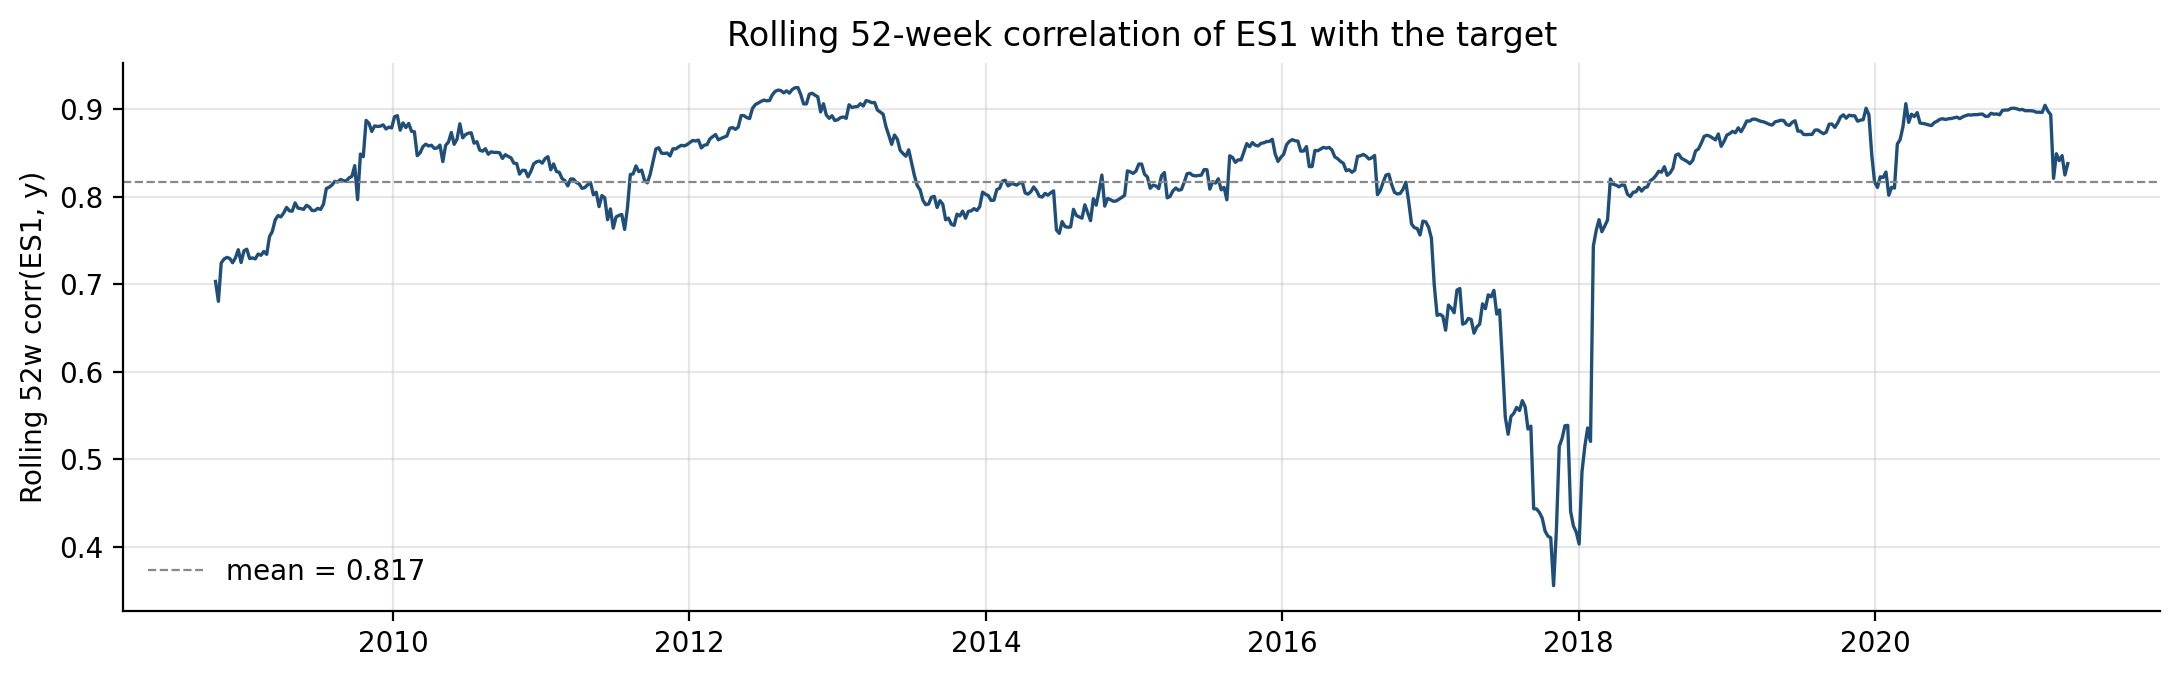

In [13]:
top_future = relevance.iloc[0]["future"]
rolling_corr = X[top_future].rolling(52).corr(y).dropna()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(rolling_corr, color="#1F4E79", lw=1.2)
ax.axhline(rolling_corr.mean(), color="#888", lw=0.8, ls="--",
            label=f"mean = {rolling_corr.mean():.3f}")
ax.set_ylabel(f"Rolling 52w corr({top_future}, y)")
ax.set_title(f"Rolling 52-week correlation of {top_future} with the target")
ax.legend()
fig.tight_layout()
plt.show()

**Graph explanation.** This graph shows whether the most-correlated futures instrument remains useful through time. A stable positive rolling correlation means the instrument repeatedly moves with the Monster Index target. Sharp drops or sign changes warn that the relationship changes over time, so a rolling model is safer than a single full-sample fit.

## Why a rolling backtest is necessary

Three reasons:

1. **No look-ahead inside the rolling fit.** At each rebalance, the fitted Ridge weights use only observations before week `t`. A single in-sample regression would silently use future observations to explain the past. The fixed futures screen is an EDA design choice reported before evaluation, while the rolling coefficient fit remains strictly walk-forward.
2. **Time-varying relationships.** As the rolling-correlation chart shows, factor exposures change. Fitting on the most recent ~2 years tracks these changes; an expanding fit averages over older relationships that may no longer apply.
3. **Realistic frequency.** Monthly rebalancing matches a realistic portfolio review cadence. Weekly rebalancing would over-trade and inflate transaction costs.

## Harness logic in plain words

At each week `t` after the warm-up period:

1. **Decide.** Check whether the date is a rebalance week (`t % rebalance_every == 0`).
2. **Fit if needed.** On a rebalance week, fit the model on `X[t-104 : t]` and `y[t-104 : t]`. This produces the new weight vector `w_new`.
3. **Apply risk caps.** If projected 1-month VaR(99%) is above 20%, scale `w_new` down. If gross exposure `Σ|w|` is above 200%, scale it down again.
4. **Compute trade and cost.** `dw = w_new − w_old`; `turnover = Σ|dw|`; `cost = turnover · bps / 10 000`.
5. **Realise PnL.** `gross_return = X[t] · w_new`; `net_return = gross_return − cost`.
6. **Carry forward otherwise.** On non-rebalance weeks, carry `w_old` forward; no trade is made, no cost is charged, and PnL is `X[t] · w_old`.

The harness records every quantity at every step so the metrics in §10–11 can be reconstructed exactly.

**Anti-leakage guarantee for the rolling fit.** By construction, the coefficient fit at time `t` cannot see `X[t]` or `y[t]`, because each model is fitted only on earlier rolling-window observations.

## Transaction-cost formula

Costs are charged on the **L1 turnover** of weights at each rebalance:

$$\text{turnover}_t = \sum_{i=1}^{N} \left| w^{\text{new}}_{i,t} - w^{\text{old}}_{i,t} \right|$$

$$\text{cost}_t = \text{turnover}_t \cdot \frac{\text{bps}}{10\,000}$$

$$\text{net\_return}_t = \text{gross\_return}_t - \text{cost}_t$$

Three cost models ship with the harness:

| Model | Formula | Use when |
|---|---|---|
| `FlatBpsTC(bps)` | $\text{bps} \cdot \sum_i \lvert \Delta w_i \rvert \;/\; 10{,}000$ | coarse baseline; simplest assumption |
| `HalfSpreadPlusImpactTC` | $\tfrac{1}{2}\text{spread} + k \cdot \lvert \Delta w \rvert^{1.5}$ | execution-style impact |
| `TieredADVTC` | step function of $\lvert \Delta w \rvert / \text{ADV}$ | sizing the strategy at large AUM |

**Wording note.** A flat 5 bps round-trip is a *conservative working assumption* drawn from the project briefing; real desks see lower costs in calm markets and higher costs in crises.

## Baseline run — Ridge as a control model

Ridge is used as a transparent control model because its weights are interpretable, stable and fast to audit. It is not treated as the final best replicating strategy; it proves that the shared contract, no-look-ahead estimation, risk controls and transaction-cost accounting work end to end.

**Why `alpha=1.0`.** A moderate, fixed regularisation strength is chosen so the control run is reproducible and interpretable. The notebook does not tune the regularisation parameter. Because the rolling fit uses `standardization_mode="scale_only"`, `alpha=1.0` is fixed in volatility-scaled training units rather than raw return units; coefficients are then converted back to raw-return units before PnL, transaction costs, exposure and VaR are calculated.

**Effect of the warm-up window on the backtest period.** The harness needs `rolling_window=104` weeks before the first fit, so even though `(X, y)` begins on **2007-10-30**, the first rebalance week is **2009-10-27** and every metric reported in later sections is computed over that window. The notebook states this boundary explicitly so the reported results are not over-interpreted as if the whole raw date range were evaluated.

### Scaling used inside the rolling fit

The return panel is **not permanently standardized or normalized**. The shared contract remains in original weekly return units, because portfolio PnL must be computed from real futures returns.

Inside each rolling training window, the harness uses `standardization_mode="scale_only"`: each futures return series and the target return are divided by their rolling standard deviation before fitting. This improves numerical conditioning without de-meaning the data. After fitting, coefficients are transformed back into original return units before portfolio weights are used. Therefore realised portfolio returns are always computed as `X @ w` using the original weekly return matrix, not standardized returns. This avoids a hidden intercept or artificial cash leg and keeps the exported weights economically interpretable.

In [14]:
BASELINE_CFG = HarnessConfig(
    rolling_window=104,
    rebalance_every=4,
    standardization_mode="scale_only",
    var_cap=0.20,
    ge_cap=2.0,
    seed=42,
    name="Ridge_control",
)
ridge_factory = lambda: Ridge(alpha=1.0, fit_intercept=False)

# Frictionless
res_frictionless = run_rolling_backtest(X, y, ridge_factory,
                                            config=BASELINE_CFG, tc_model=None)
# Cost-aware (5 bps)
res_costed = run_rolling_backtest(X, y, ridge_factory,
                                     config=BASELINE_CFG, tc_model=FlatBpsTC(5.0))

# Confirm contract metric keys
contract_keys = {"IR", "TE", "rho", "GE", "VaR", "turnover", "net_IR", "net_TE"}
assert contract_keys.issubset(res_costed.metrics.keys())
print("contract keys present:", sorted(contract_keys))

contract keys present: ['GE', 'IR', 'TE', 'VaR', 'net_IR', 'net_TE', 'rho', 'turnover']


## Frictionless vs cost-aware comparison

The gap between these two runs is the first economic audit of the pipeline. Gross IR and TE are unchanged because the fitted weights are the same. Net IR is lower because transaction costs are a real implementation drag. Net TE usually changes less than net IR because flat transaction costs mostly add drift rather than random tracking noise.

In [15]:
headline = pd.DataFrame([
    {"scenario": "Frictionless", **res_frictionless.metrics},
    {"scenario": "Net of 5 bps", **res_costed.metrics},
]).set_index("scenario")[["IR", "TE", "net_IR", "net_TE", "rho", "GE",
                            "VaR", "turnover", "tc_total_bps", "max_drawdown_net"]]
headline.style.format({
    "IR": "{:+.2f}", "TE": "{:.2%}", "net_IR": "{:+.2f}", "net_TE": "{:.2%}",
    "rho": "{:.3f}", "GE": "{:.2f}", "VaR": "{:.2%}", "turnover": "{:.3f}",
    "tc_total_bps": "{:.0f}", "max_drawdown_net": "{:.2%}",
}).set_caption("Headline — same Ridge weights, frictionless vs net of 5 bps")

,IR,TE,net_IR,net_TE,rho,GE,VaR,turnover,tc_total_bps,max_drawdown_net
scenario,,,,,,,,,,
Frictionless,-0.21,3.10%,-0.21,3.10%,0.837,1.64,2.86%,0.067,0,9.03%
Net of 5 bps,-0.21,3.10%,-0.26,3.11%,0.836,1.64,2.86%,0.067,200,9.04%


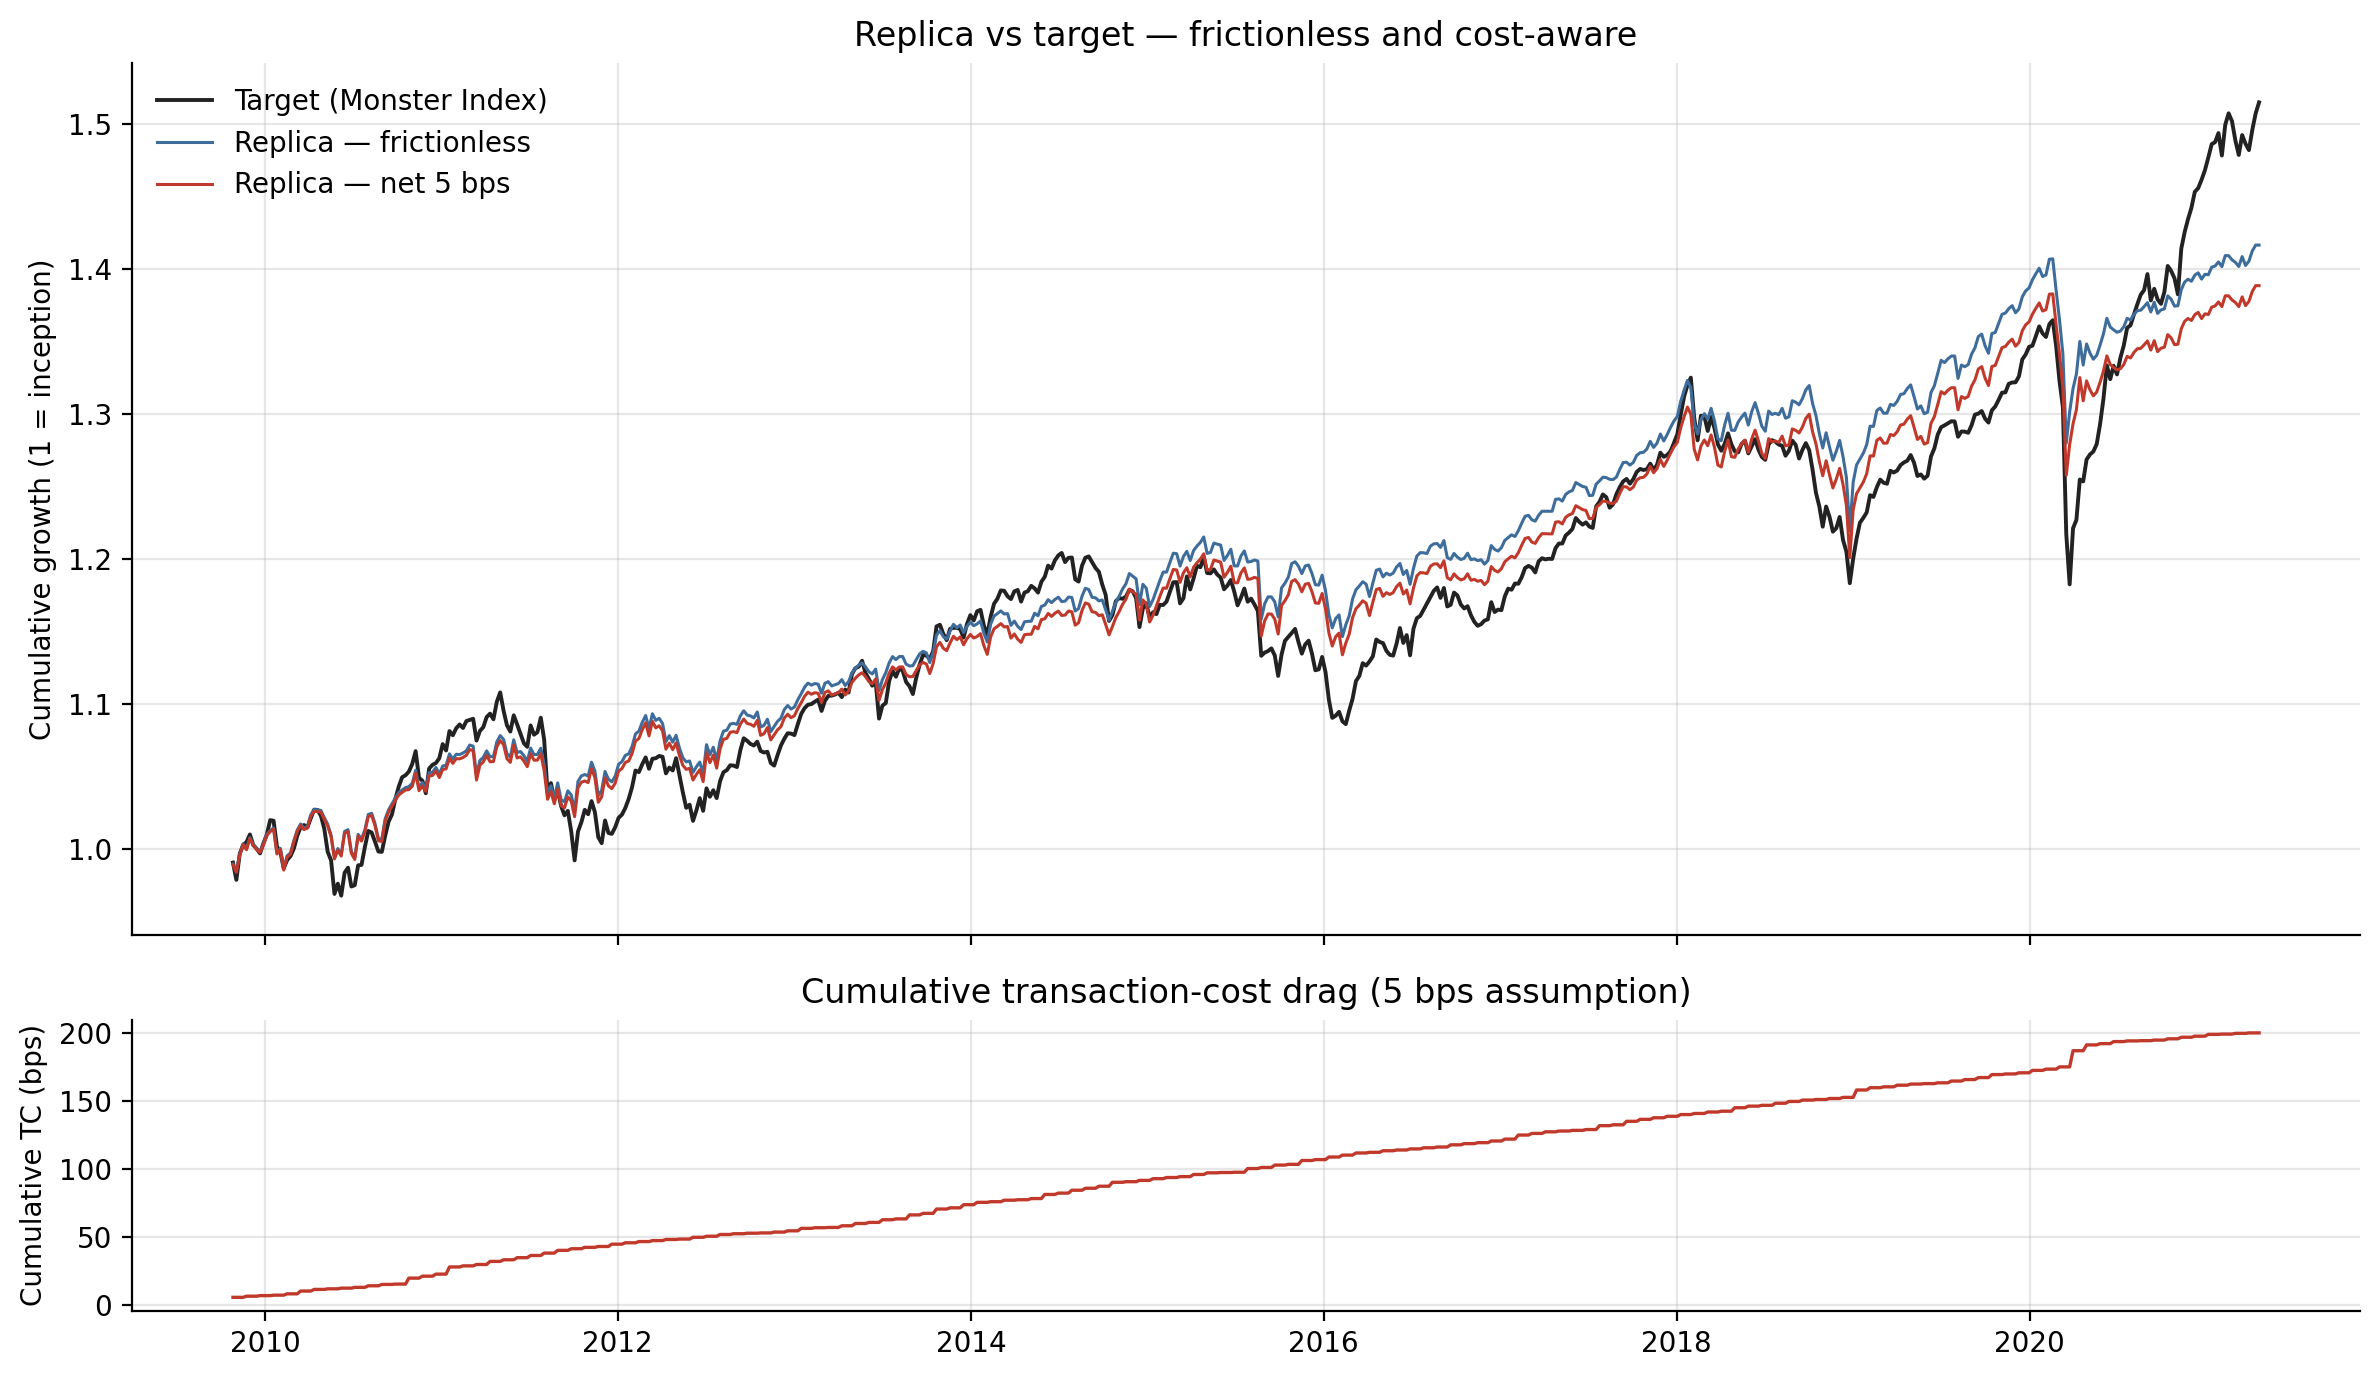

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})
ax0, ax1 = axes

for s, lbl, c in [(res_frictionless.target,        "Target (Monster Index)",  "#222"),
                   (res_frictionless.replica_net,    "Replica — frictionless", "#3E6D9C"),
                   (res_costed.replica_net,          "Replica — net 5 bps",     "#C0392B")]:
    ax0.plot((1+s).cumprod(), label=lbl, color=c, lw=1.4 if "Target" in lbl else 1.1)
ax0.set_ylabel("Cumulative growth (1 = inception)")
ax0.set_title("Replica vs target — frictionless and cost-aware")
ax0.legend(loc="upper left")

ax1.plot(res_costed.tc_cumulative * 1e4, color="#C0392B", lw=1.2)
ax1.set_ylabel("Cumulative TC (bps)")
ax1.set_title("Cumulative transaction-cost drag (5 bps assumption)")
fig.tight_layout()
plt.show()

**Graph explanation.** The upper panel compares cumulative growth of the target, the frictionless replica and the net-of-cost replica. The lower panel shows cumulative transaction-cost drag in basis points. The key message is that a model can look statistically useful before costs, but its tradable version must be judged after implementation costs.

**Honest reading.** The Ridge control model has a **negative net information ratio** under realistic costs. This is not hidden. It means the control model captures direction reasonably well, but transaction costs, tracking gaps and under/over-exposure can still damage net active performance. The pipeline therefore evaluates beta, tracking error, net IR, turnover, transaction costs and risk together. That is stronger than presenting only correlation.


## Cost-sensitivity diagnostic

**Goal.** Quantify how the contract metrics degrade as the assumed flat transaction cost changes from 0 to 20 bps.

**Method.** Re-run the same Ridge configuration through flat-bps transaction-cost assumptions only. The model family, rolling window, rebalance frequency and risk controls are unchanged. A bootstrap 95% CI on `net_TE` and `net_IR` (stationary block bootstrap, Politis & Romano 1994) is included for the main sweep.

In [17]:
TC_SCENARIOS = {
    "frictionless":          None,
    "2 bps":                 FlatBpsTC(2.0),
    "5 bps":                 FlatBpsTC(5.0),
    "10 bps":                FlatBpsTC(10.0),
    "20 bps":                FlatBpsTC(20.0),
    "½-spread + √-impact":   HalfSpreadPlusImpactTC(half_spread_bps=2.0, impact_coef_bps=8.0),
}

# Cost-sensitivity sweep
sens = cost_sensitivity_sweep(
    X, y, ridge_factory, TC_SCENARIOS,
    config=BASELINE_CFG,
)
sens.style.format({
    "IR": "{:+.2f}", "TE": "{:.2%}", "net_IR": "{:+.2f}", "net_TE": "{:.2%}",
    "rho": "{:.3f}", "GE": "{:.2f}", "VaR": "{:.2%}",
    "turnover": "{:.3f}", "tc_total_bps": "{:.1f}",
    "ann_ret_net": "{:+.2%}", "max_drawdown_net": "{:.2%}",
}).set_caption("Cost-sensitivity sweep — same Ridge baseline, six TC regimes")

,IR,TE,net_IR,net_TE,rho,GE,VaR,turnover,annual_turnover,tc_total_bps,tc_bps_per_year,ann_ret_net,max_drawdown_net,n_rebalances,n_obs
scenario,,,,,,,,,,,,,,,
frictionless,-0.21,3.10%,-0.21,3.10%,0.837,1.64,2.86%,0.067,3.463065,0.0,0.000000,+3.12%,9.03%,150,600
2 bps,-0.21,3.10%,-0.23,3.10%,0.836,1.64,2.86%,0.067,3.463065,79.9,6.926129,+3.05%,9.03%,150,600
5 bps,-0.21,3.10%,-0.26,3.11%,0.836,1.64,2.86%,0.067,3.463065,199.8,17.315323,+2.95%,9.04%,150,600
10 bps,-0.21,3.10%,-0.32,3.12%,0.835,1.64,2.86%,0.067,3.463065,399.6,34.630646,+2.78%,9.06%,150,600
20 bps,-0.21,3.10%,-0.42,3.14%,0.832,1.64,2.86%,0.067,3.463065,799.2,69.261291,+2.43%,9.09%,150,600
½-spread + √-impact,-0.21,3.10%,-0.26,3.11%,0.835,1.64,2.86%,0.067,3.463065,193.0,16.728773,+2.96%,9.04%,150,600


In [18]:
# Bootstrap CI on the 5 bps result
ci = stationary_block_bootstrap_ci(res_costed.replica_net, res_costed.target,
                                      n_boot=500, ci_level=0.95, seed=42)
ci_df = pd.DataFrame([ci]).T.rename(columns={0: "value"})
ci_df.style.format({"value": "{:+.4f}"}) \
    .set_caption("Bootstrap 95% CI on net TE and net IR (5 bps scenario)")

,value
te_mean,+0.0306
te_lo,+0.0242
te_hi,+0.0400
ir_mean,-0.2573
ir_lo,-0.9566
ir_hi,+0.3426


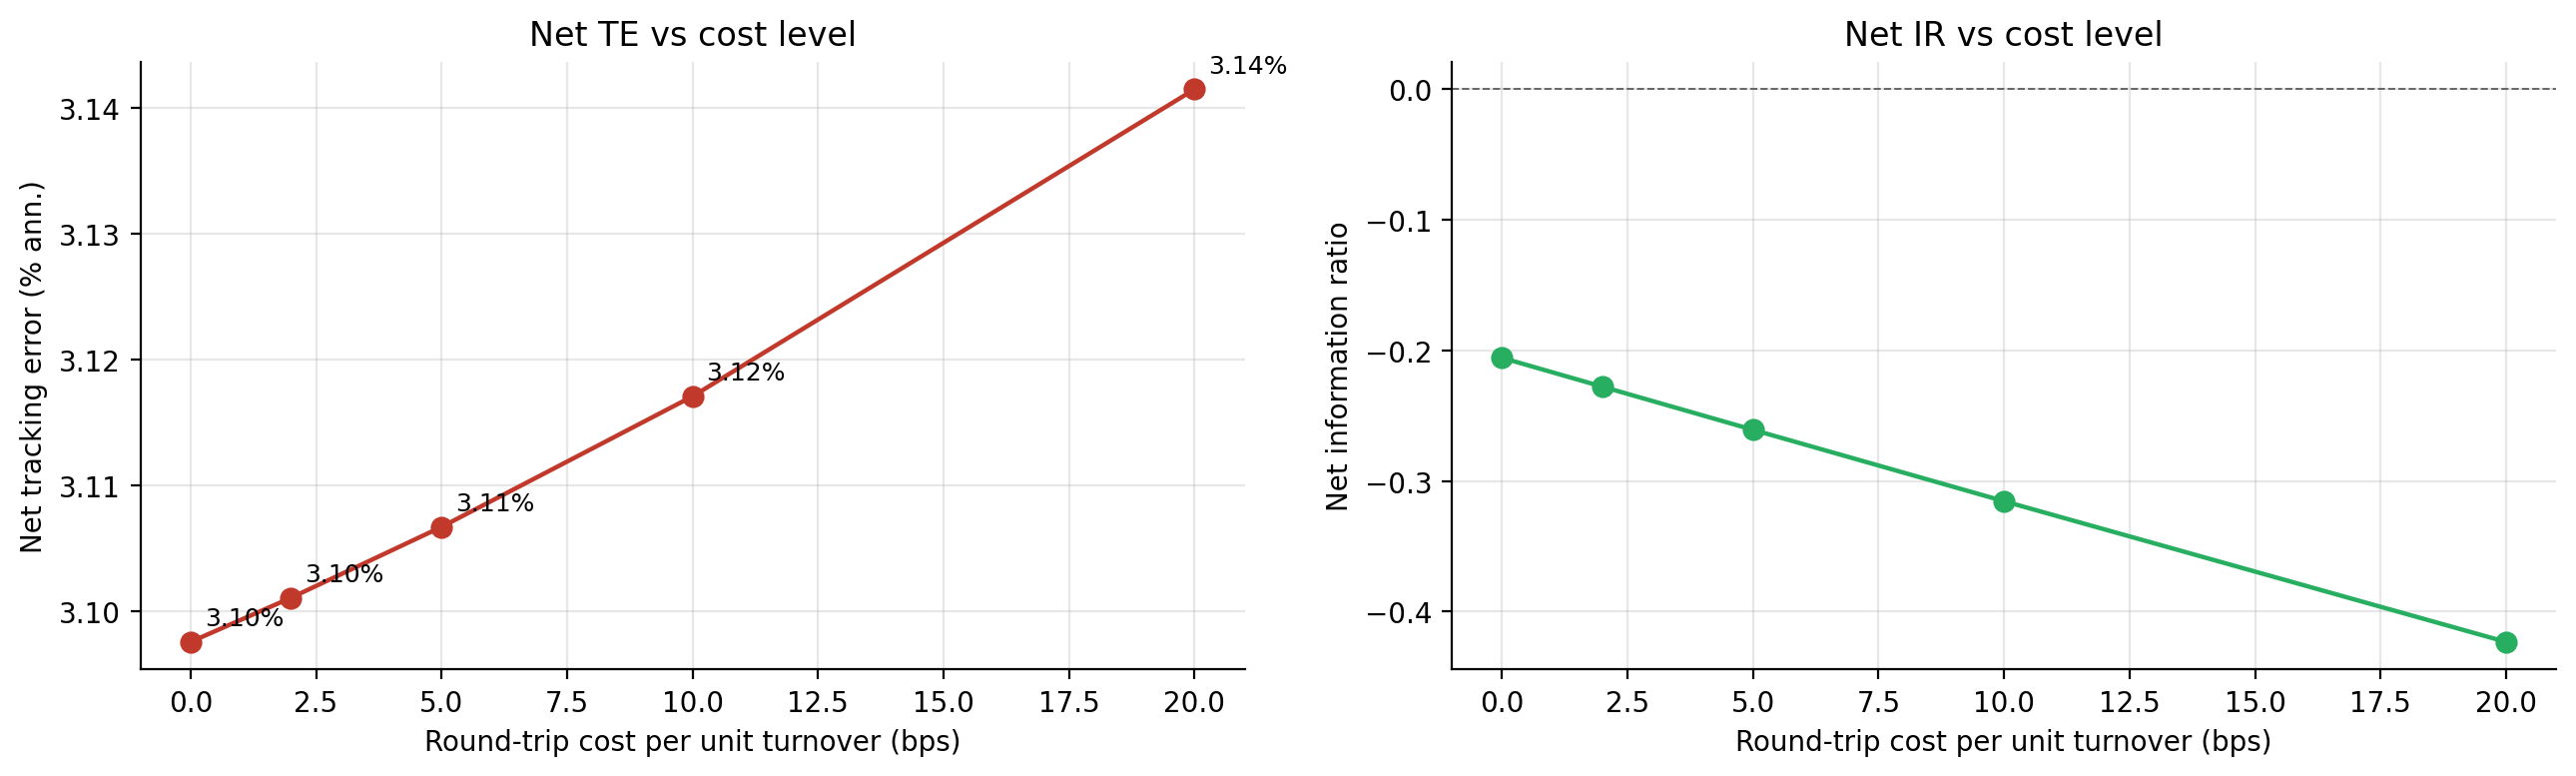

In [19]:
# Pareto-style plot: net_TE vs cost level (excluding the impact model)
flat_rows = sens.loc[["frictionless", "2 bps", "5 bps", "10 bps", "20 bps"]]
bps_levels = [0, 2, 5, 10, 20]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(bps_levels, flat_rows["net_TE"] * 100, "o-", color="#C0392B", lw=1.6, ms=7)
axes[0].set_xlabel("Round-trip cost per unit turnover (bps)")
axes[0].set_ylabel("Net tracking error (% ann.)")
axes[0].set_title("Net TE vs cost level")
for x, t in zip(bps_levels, flat_rows["net_TE"] * 100):
    axes[0].annotate(f"{t:.2f}%", (x, t), xytext=(5, 6),
                      textcoords="offset points", fontsize=9)

axes[1].plot(bps_levels, flat_rows["net_IR"], "o-", color="#27AE60", lw=1.6, ms=7)
axes[1].axhline(0, color="#666", lw=0.7, ls="--")
axes[1].set_xlabel("Round-trip cost per unit turnover (bps)")
axes[1].set_ylabel("Net information ratio")
axes[1].set_title("Net IR vs cost level")
fig.tight_layout()
plt.show()

**Graph explanation.** The left panel shows how annualised net tracking error behaves as the assumed flat transaction cost rises. The right panel shows the corresponding net information ratio. This does not change the strategy; it only shows how sensitive the already-defined baseline is to cost assumptions.

## Risk audit (single-model)

**Goal.** Read the Ridge-control result against the project's risk limits. This is not a model comparison — it is a check that the control run respects the GE and VaR caps.

In [20]:
risk = risk_audit_table(res_costed)
display(risk.style.format({
    "value": "{:.4f}", "limit": "{:.4f}",
}).set_caption("Risk-audit table — Ridge control under 5 bps"))

,value
Average GE,1.6387
Maximum GE,2.0000
GE cap,2.0000
GE breaches - all weeks,0.0000
Average VaR,0.0286
Maximum VaR,0.0660
VaR cap,0.2000
VaR breaches - all weeks,0.0000
VaR breaches - rebalance dates,0.0000
Maximum absolute single future weight,1.4071


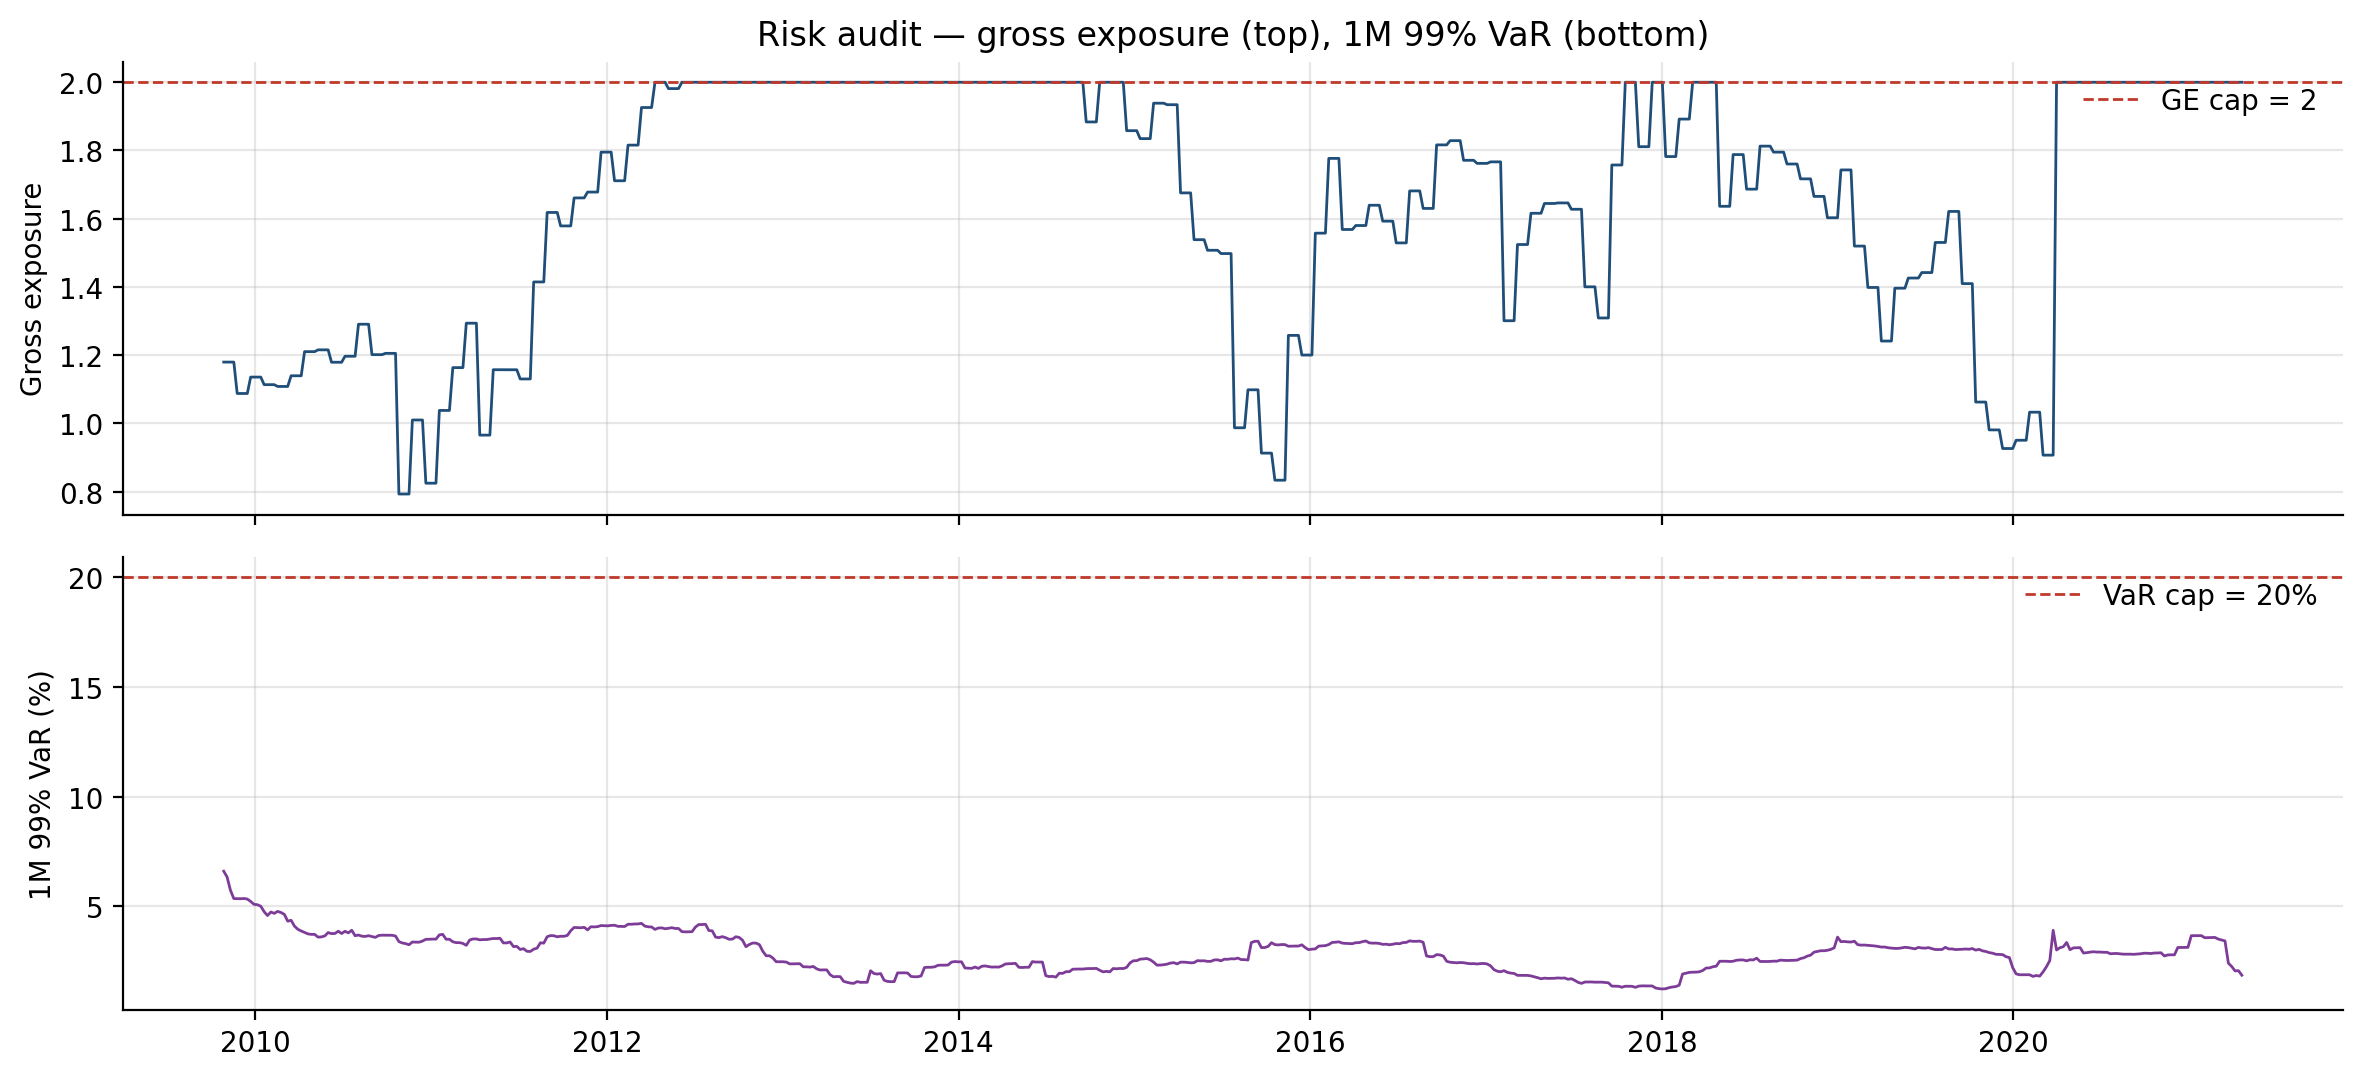

In [21]:
# Quick visual of GE and VaR through time
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)

axes[0].plot(res_costed.gross_exposure, color="#1F4E79", lw=1.0)
axes[0].axhline(BASELINE_CFG.ge_cap, color="#C0392B", lw=1.0, ls="--",
                 label=f"GE cap = {BASELINE_CFG.ge_cap:.0f}")
axes[0].set_ylabel("Gross exposure")
axes[0].set_title("Risk audit — gross exposure (top), 1M 99% VaR (bottom)")
axes[0].legend(loc="upper right")

axes[1].plot(res_costed.var_series * 100, color="#7D3C98", lw=1.0)
axes[1].axhline(BASELINE_CFG.var_cap * 100, color="#C0392B", lw=1.0, ls="--",
                 label=f"VaR cap = {BASELINE_CFG.var_cap:.0%}")
axes[1].set_ylabel("1M 99% VaR (%)")
axes[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

**Graph explanation.** The upper panel checks whether gross notional exposure stays under the mandate cap. The lower panel checks projected one-month 99% VaR against the VaR cap. The important result is not only the average level; it is whether the line breaches the limit during the evaluated backtest.

## Cross-check the second entry point

Any candidate model that produces weights externally can call `evaluate_weights` instead of `run_rolling_backtest`. The two paths must produce identical metrics on the same weights; otherwise, the head-to-head comparison would be biased.

In [22]:
rebal_dates = res_costed.rebalance_dates
res_via_evaluate = evaluate_weights(
    X, y, res_costed.weights_history,
    schedule_type="rebalance",
    tc_model=FlatBpsTC(5.0),
    config=BASELINE_CFG,
    name="Ridge_control_via_evaluate_weights",
)

compare = pd.DataFrame({
    "run_rolling_backtest": res_costed.metrics,
    "evaluate_weights":     res_via_evaluate.metrics,
}).T[["IR", "TE", "net_IR", "net_TE", "rho", "GE", "VaR", "turnover", "tc_total_bps"]]
diff = (compare.iloc[0] - compare.iloc[1]).abs().max()
print(f"max absolute metric difference between the two entry points: {diff:.2e}")
compare.style.format("{:+.6f}")

max absolute metric difference between the two entry points: 0.00e+00


,IR,TE,net_IR,net_TE,rho,GE,VaR,turnover,tc_total_bps
run_rolling_backtest,-0.205720,+0.030975,-0.260850,+0.031067,+0.835779,+1.638750,+0.028622,+0.066597,+199.792186
evaluate_weights,-0.205720,+0.030975,-0.260850,+0.031067,+0.835779,+1.638750,+0.028622,+0.066597,+199.792186


## Benchmark controls and validation-selected baseline

A serious shared evaluation layer should not rely on a single model in isolation. The table below compares simple baseline controls and rolling model controls under the same dates, the same 5 bps transaction-cost assumption and the same shared contract.

The purpose is **pipeline validation**, not to solve unrelated project sections. The Ridge run from §10 remains a transparent diagnostic control. The canonical project artifact is selected from the validation set only, then exported separately while the original Ridge control is preserved for auditability.

In [23]:
benchmark_results = {}

# Simple baseline controls.
zero_weights = pd.DataFrame(0.0, index=res_costed.rebalance_dates, columns=X.columns)
equal_weights = pd.DataFrame(1.0 / len(X.columns), index=res_costed.rebalance_dates, columns=X.columns)

benchmark_results["Zero exposure"] = evaluate_weights(
    X, y, zero_weights, schedule_type="rebalance",
    tc_model=FlatBpsTC(5.0), config=BASELINE_CFG, name="zero_exposure"
)
benchmark_results["Equal-weight futures"] = evaluate_weights(
    X, y, equal_weights, schedule_type="rebalance",
    tc_model=FlatBpsTC(5.0), config=BASELINE_CFG, name="equal_weight_futures"
)
benchmark_results["Static full-sample OLS diagnostic"] = evaluate_weights(
    X, y,
    make_static_ols_weights(X, y, res_costed.rebalance_dates, ge_cap=BASELINE_CFG.ge_cap),
    schedule_type="rebalance", tc_model=FlatBpsTC(5.0), config=BASELINE_CFG,
    name="static_full_sample_OLS_diagnostic"
)
for future in ["ES1", "NQ1", "VG1"]:
    benchmark_results[f"Beta-scaled {future} benchmark"] = evaluate_weights(
        X, y,
        make_beta_scaled_single_future_weights(X, y, future, res_costed.rebalance_dates, ge_cap=BASELINE_CFG.ge_cap),
        schedule_type="rebalance", tc_model=FlatBpsTC(5.0), config=BASELINE_CFG,
        name=f"beta_scaled_{future}"
    )

# Rolling controls. These are baseline validation checks for the evaluation layer,
# not separate project sections.
benchmark_results.update({
    "Rolling OLS": run_rolling_backtest(
        X, y, lambda: LinearRegression(fit_intercept=False), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Ridge α=0.1": run_rolling_backtest(
        X, y, lambda: Ridge(alpha=0.1, fit_intercept=False), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Ridge α=1": res_costed,
    "Rolling Ridge α=10": run_rolling_backtest(
        X, y, lambda: Ridge(alpha=10.0, fit_intercept=False), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Lasso α=1e-4": run_rolling_backtest(
        X, y, lambda: Lasso(alpha=1e-4, fit_intercept=False, max_iter=20000), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling ElasticNet α=1e-4": run_rolling_backtest(
        X, y, lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, fit_intercept=False, max_iter=20000), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
    "Rolling Huber": run_rolling_backtest(
        X, y, lambda: HuberRegressor(alpha=1e-4, fit_intercept=False, max_iter=500), config=BASELINE_CFG, tc_model=FlatBpsTC(5.0)
    ),
})

# Constrained/cost-aware benchmark controls. They remain baseline validation tools:
# they test whether directly penalising turnover improves implementability.
for label, spec in {
    "Constrained TE optimizer": dict(method="constrained_te", l2_penalty=1e-6, turnover_l1_penalty=0.0),
    "Cost-aware optimizer γ=1e-6": dict(method="cost_aware_l1_delta", l2_penalty=1e-6, turnover_l1_penalty=1e-6),
    "Cost-aware optimizer γ=5e-6": dict(method="cost_aware_l1_delta", l2_penalty=1e-6, turnover_l1_penalty=5e-6),
    "Cost-aware optimizer γ=1e-5": dict(method="cost_aware_l1_delta", l2_penalty=1e-6, turnover_l1_penalty=1e-5),
}.items():
    w = build_optimizer_weights(X, y, config=BASELINE_CFG, **spec)
    benchmark_results[label] = evaluate_weights(
        X, y, w, schedule_type="rebalance", tc_model=FlatBpsTC(5.0), config=BASELINE_CFG, name=label
    )

benchmark_table = benchmark_result_table(benchmark_results)
benchmark_display = benchmark_table.copy()
benchmark_formatters = {
    "rho": "{:.3f}", "beta_to_target": "{:.2f}", "TE": "{:.2%}", "net_TE": "{:.2%}",
    "IR": "{:+.2f}", "net_IR": "{:+.2f}", "ann_ret_net": "{:+.2%}",
    "max_drawdown_net": "{:.2%}", "GE": "{:.2f}", "max_GE": "{:.2f}",
    "VaR": "{:.2%}", "max_VaR": "{:.2%}", "annual_turnover": "{:.3f}",
    "tc_total_bps": "{:.1f}", "n_rebalances": "{:.0f}", "n_obs": "{:.0f}",
}
for col, fmt in benchmark_formatters.items():
    if col in benchmark_display.columns:
        benchmark_display[col] = benchmark_display[col].map(lambda v, f=fmt: "" if pd.isna(v) else f.format(v))

print("Benchmark controls — pipeline validation under the same shared contract")
display(benchmark_display)

# Validation discipline: choose the canonical baseline on a validation window only.
validation_windows = {
    "validation_2016_2018": ("2016-01-01", "2018-12-31"),
    "test_2019_2021": ("2019-01-01", "2021-04-20"),
}
validation_candidates = {
    k: benchmark_results[k]
    for k in [
        "Rolling Ridge α=1", "Rolling Ridge α=10", "Rolling Huber",
        "Constrained TE optimizer", "Cost-aware optimizer γ=1e-6",
        "Cost-aware optimizer γ=5e-6", "Cost-aware optimizer γ=1e-5", "Equal-weight futures",
    ]
}
validation_table = split_diagnostics(validation_candidates, validation_windows)
selection_pool = validation_table.xs("validation_2016_2018", level="window").drop(index="Equal-weight futures", errors="ignore")
best_validation_te = selection_pool["net_TE"].min()
te_tolerance = 0.0002  # 2 annualised bps of net tracking error
selection_pool_near_best = selection_pool[selection_pool["net_TE"] <= best_validation_te + te_tolerance]
selected_label = selection_pool_near_best.sort_values(["annual_turnover", "net_TE"]).index[0]
selected_result = validation_candidates[selected_label]
assert validate_project_interface(selected_result, X, y)

print(f"\nValidation-selected canonical baseline: {selected_label}")
print("Selection rule: among controls within 2 annualised bps of the best validation net TE, choose the lowest annual turnover.")
display(validation_table.round(6))


Benchmark controls — pipeline validation under the same shared contract


,rho,TE,net_TE,IR,net_IR,ann_ret_net,beta_to_target,max_drawdown_net,GE,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,n_rebalances,n_obs
benchmark,,,,,,,,,,,,,,,,
Static full-sample OLS diagnostic,0.873,2.75%,2.75%,+0.06,+0.06,+3.92%,0.76,9.96%,1.00,1.00,3.14%,6.66%,0.087,5.0,150,600
Cost-aware optimizer γ=5e-6,0.853,2.95%,2.95%,+0.07,+0.07,+3.95%,0.75,9.54%,0.66,0.98,3.17%,6.52%,0.185,10.7,150,600
Cost-aware optimizer γ=1e-5,0.852,2.96%,2.96%,-0.04,-0.05,+3.62%,0.72,9.35%,0.59,0.71,3.06%,6.37%,0.118,6.8,150,600
Cost-aware optimizer γ=1e-6,0.847,3.01%,3.01%,+0.10,+0.09,+4.03%,0.75,9.38%,0.82,1.39,3.18%,6.64%,0.475,27.4,150,600
Beta-scaled ES1 benchmark,0.845,3.03%,3.03%,+0.06,+0.06,+3.95%,0.69,9.32%,0.31,0.31,2.98%,5.91%,0.027,1.6,150,600
Rolling Huber,0.844,3.03%,3.03%,-0.02,-0.09,+3.50%,0.71,8.70%,1.59,2.00,3.04%,6.61%,3.886,224.2,150,600
Constrained TE optimizer,0.837,3.08%,3.09%,-0.21,-0.27,+2.94%,0.69,9.13%,1.65,2.00,2.87%,6.63%,3.559,205.3,150,600
Rolling Lasso α=1e-4,0.837,3.09%,3.10%,-0.22,-0.28,+2.90%,0.68,9.13%,1.66,2.00,2.86%,6.63%,3.586,206.9,150,600
Rolling ElasticNet α=1e-4,0.837,3.09%,3.10%,-0.22,-0.28,+2.90%,0.68,9.13%,1.66,2.00,2.86%,6.63%,3.587,207.0,150,600



Validation-selected canonical baseline: Cost-aware optimizer γ=5e-6
Selection rule: among controls within 2 annualised bps of the best validation net TE, choose the lowest annual turnover.


start         end  \
model                       window                                         
Rolling Ridge α=1           validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Rolling Ridge α=10          validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Rolling Huber               validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Constrained TE optimizer    validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Cost-aware optimizer γ=1e-6 validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Cost-aware optimizer γ=5e-6 validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Cost-aware optimizer γ=1e-5 validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   
Equal-weight futures        validation_2016_2018  2016-01-01  2018-12-31   
                            test_2019_2021        2019-01-01  2021-04-20   

                                                  n_obs       rho  \
model                       window                                  
Rolling Ridge α=1           validation_2016_2018    156  0.852045   
                            test_2019_2021          121  0.757493   
Rolling Ridge α=10          validation_2016_2018    156  0.851216   
                            test_2019_2021          121  0.745796   
Rolling Huber               validation_2016_2018    156  0.853543   
                            test_2019_2021          121  0.782926   
Constrained TE optimizer    validation_2016_2018    156  0.851806   
                            test_2019_2021          121  0.764665   
Cost-aware optimizer γ=1e-6 validation_2016_2018    156  0.852422   
                            test_2019_2021          121  0.793975   
Cost-aware optimizer γ=5e-6 validation_2016_2018    156  0.849534   
                            test_2019_2021          121  0.810690   
Cost-aware optimizer γ=1e-5 validation_2016_2018    156  0.844425   
                            test_2019_2021          121  0.804808   
Equal-weight futures        validation_2016_2018    156  0.778208   
                            test_2019_2021          121  0.693271   

                                                  beta_to_target    net_TE  \
model                       window                                           
Rolling Ridge α=1           validation_2016_2018        0.774141  0.023645   
                            test_2019_2021              0.554460  0.046805   
Rolling Ridge α=10          validation_2016_2018        0.735418  0.023575   
                            test_2019_2021              0.522305  0.047836   
Rolling Huber               validation_2016_2018        0.796733  0.023672   
                            test_2019_2021              0.621650  0.044575   
Constrained TE optimizer    validation_2016_2018        0.779745  0.023698   
                            test_2019_2021              0.569261  0.046190   
Cost-aware optimizer γ=1e-6 validation_2016_2018        0.752216  0.023519   
                            test_2019_2021              0.703069  0.044044   
Cost-aware optimizer γ=5e-6 validation_2016_2018        0.715529  0.023693   
                            test_2019_2021              0.720719  0.042317   
Cost-aware optimizer γ=1e-5 validation_2016_2018        0.656516  0.024243   
                            test_2019_2021              0.692041  0.042704   
Equal-weight futures        validation_2016_2018        1.094887  0.039907   
                            test_2019_2021              1.018072  0.075829   

                                      

**Table explanation and interpretation.** This table prevents a common weakness in portfolio projects: showing one model without context. The zero and equal-weight controls define simple floors, the static OLS diagnostic is a non-tradeable upper-bound sanity check, and the beta-scaled single-future benchmarks show what a "just buy beta" implementation would look like. Rolling OLS, Ridge, Lasso, ElasticNet and Huber act as transparent model controls. The constrained and cost-aware optimizers test whether the same shared contract benefits from explicit turnover and implementability penalties.

**Validation discipline.** The canonical baseline is selected using the validation window only. The test window is displayed for honesty, but it is not used to tune the selected baseline. The Ridge control remains preserved as a diagnostic artifact, while `selected_result` is the validation-selected artifact used in the remaining risk, stress, persistence and dashboard sections.

**Important discipline.** The static full-sample OLS row is explicitly labelled diagnostic because it uses the whole sample and is not a no-look-ahead tradeable strategy.

## Transaction-cost assumption register

Transaction costs are not a footnote in a tradable futures strategy. The table below states the assumptions clearly, the code implementation and the risk if the assumption is wrong.

In [24]:
assumption_register = assumption_register()
display(assumption_register.style.set_caption("Assumption register — data, model, risk, costs and handoff"))

,area,assumption,implementation,risk_if_wrong,control
0,Data,Weekly returns are computed from the supplied Bloomberg-style price panel.,pct_change on cleaned positive prices; rows with missing required returns are removed.,"Bad data would directly affect weights, TE, VaR and transaction-cost estimates.","Strict required-column checks, non-positive price rejection and input hash exported with results."
1,Data,Prices are not forward-filled before return calculation.,clean_price_panel deliberately avoids forward fill.,Forward fill can create artificial zero returns and understate volatility and VaR.,Documented in code and notebook; NaN rows are removed only after return construction.
2,Data,"Extreme returns are flagged for review, not automatically deleted.",market_stress_outlier_audit uses robust z-scores and labels crisis/stress windows.,Deleting genuine market stress would overstate replication quality and understate risk.,Only invalid prices/missing required returns are removed; valid extreme market observations remain in the backtest.
3,Model,"Ridge is a transparent control model, not the final portfolio claim.","Rolling two-year fit, monthly rebalance, fit_intercept=False.",Interpreting it as the final best model would overstate the modelling conclusion.,Benchmark and validation tables separate pipeline validation from final strategy selection.
4,Model,"Cost-aware optimisation is included as a benchmark control, not as an over-claimed final trading system.",build_optimizer_weights supports constrained TE and L1 turnover-penalised weight updates.,Ignoring turnover during weight construction can make a model look good before costs but weak after costs.,Leaderboard compares ordinary rolling estimators with constrained and cost-aware optimizer controls.
5,Backtest,No look-ahead is allowed.,"At week t, the model is fitted only on observations before t.",Look-ahead would overstate performance and reduce apparent tracking error.,run_rolling_backtest uses explicit rolling train windows and rebalance dates.
6,Exposure,"Futures weights are notional exposures, not cash allocations.",Gross exposure equals sum(abs(weights)); GE cap is enforced before PnL.,Risk could be understated if weights were treated like long-only cash shares.,"GE time series, breach counts, long/short/net exposure dashboard."
7,Risk,One-month 99% Gaussian VaR is the hard portfolio-risk control.,VaR is projected on the recent training history and weights are scaled if needed.,Gaussian VaR can miss tail risk and regime shifts.,"Historical VaR, Expected Shortfall and stress-window diagnostics are also reported."
8,Transaction costs,5 bps per unit one-way turnover is the baseline cost stress.,FlatBpsTC charges cost = bps × sum(abs(delta weights)).,Too-low costs would inflate net IR; too-high costs would penalise high-turnover models.,Cost sensitivity from 0 to 20 bps plus half-spread/impact model.
9,Transaction costs,ADV-based costs are illustrative unless real futures ADV data is supplied.,"TieredADVTC is available as a stress-test framework, not used as calibrated baseline.",A calibrated liquidity conclusion cannot be claimed from placeholder ADV values.,Notebook labels the ADV model as illustrative only.


**Table explanation.** This register makes the project more defensible. It separates what the code actually does from what is only an assumption. In particular, it separates the flat transaction-cost assumption used in the code from richer liquidity models that would require additional market data.

## Expanded risk dashboard

The basic GE/VaR audit is necessary but not enough. The dashboard below is built on the validation-selected canonical baseline, because this is the project artifact after the benchmark and validation checks. An industry-style review asks how exposure is split between long and short books, whether net exposure is drifting, and whether tail risk is visible beyond Gaussian VaR.

In [25]:
exposure_dashboard = exposure_dashboard(selected_result)
rolling_risk = rolling_risk_dashboard(selected_result, window=52)

risk_summary = pd.DataFrame({
    "Average": [
        exposure_dashboard["long_exposure"].mean(),
        exposure_dashboard["short_exposure"].mean(),
        exposure_dashboard["net_exposure"].mean(),
        exposure_dashboard["gross_exposure"].mean(),
        exposure_dashboard["max_abs_weight"].mean(),
        rolling_risk["rolling_gaussian_VaR_1m_99"].mean(),
        rolling_risk["rolling_historical_VaR_1m_99"].mean(),
        rolling_risk["rolling_expected_shortfall_1m_99"].mean(),
    ],
    "Maximum / Worst": [
        exposure_dashboard["long_exposure"].max(),
        exposure_dashboard["short_exposure"].min(),
        exposure_dashboard["net_exposure"].abs().max(),
        exposure_dashboard["gross_exposure"].max(),
        exposure_dashboard["max_abs_weight"].max(),
        rolling_risk["rolling_gaussian_VaR_1m_99"].max(),
        rolling_risk["rolling_historical_VaR_1m_99"].max(),
        rolling_risk["rolling_expected_shortfall_1m_99"].max(),
    ],
}, index=[
    "Long exposure", "Short exposure", "Net exposure", "Gross exposure", "Max abs single weight",
    "Rolling Gaussian VaR", "Rolling historical VaR", "Rolling Expected Shortfall",
])

display(risk_summary.style.format("{:.2%}").set_caption("Expanded risk dashboard"))

,Average,Maximum / Worst
Long exposure,65.09%,85.87%
Short exposure,-1.16%,-12.59%
Net exposure,63.94%,73.85%
Gross exposure,66.25%,97.94%
Max abs single weight,24.01%,46.31%
Rolling Gaussian VaR,3.06%,5.67%
Rolling historical VaR,3.26%,6.92%
Rolling Expected Shortfall,4.26%,10.37%


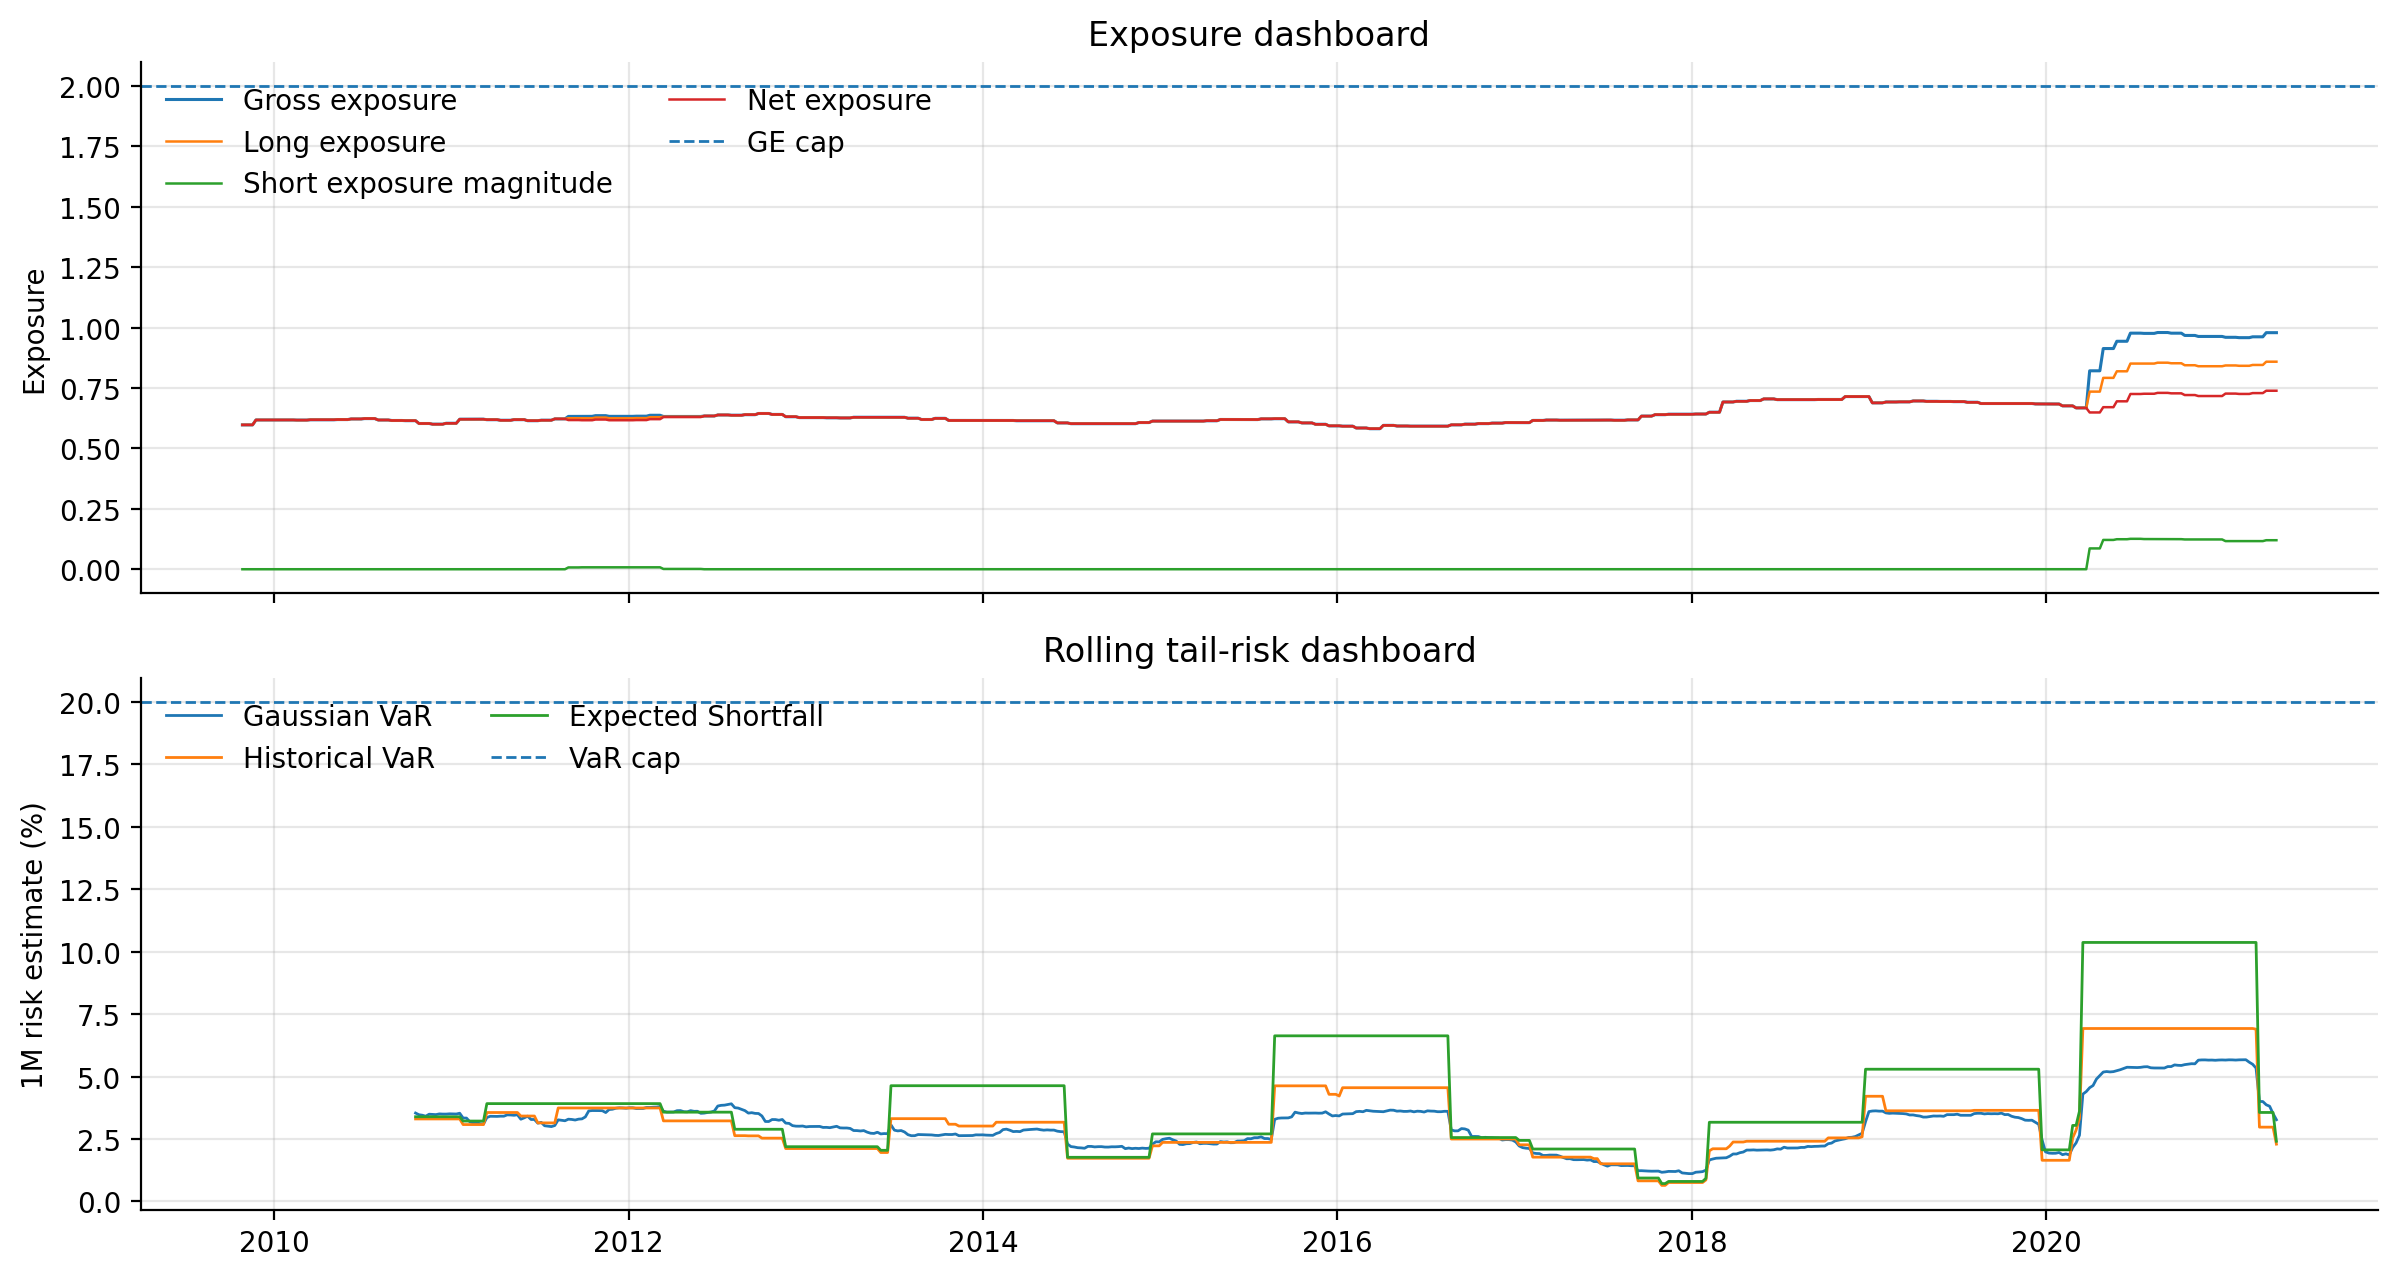

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["gross_exposure"], label="Gross exposure", lw=1.1)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["long_exposure"], label="Long exposure", lw=0.9)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["short_exposure"].abs(), label="Short exposure magnitude", lw=0.9)
axes[0].plot(exposure_dashboard.index, exposure_dashboard["net_exposure"], label="Net exposure", lw=0.9)
axes[0].axhline(BASELINE_CFG.ge_cap, lw=1.0, ls="--", label="GE cap")
axes[0].set_ylabel("Exposure")
axes[0].set_title("Exposure dashboard")
axes[0].legend(loc="upper left", ncol=2)

axes[1].plot(rolling_risk.index, rolling_risk["rolling_gaussian_VaR_1m_99"] * 100, label="Gaussian VaR", lw=1.0)
axes[1].plot(rolling_risk.index, rolling_risk["rolling_historical_VaR_1m_99"] * 100, label="Historical VaR", lw=1.0)
axes[1].plot(rolling_risk.index, rolling_risk["rolling_expected_shortfall_1m_99"] * 100, label="Expected Shortfall", lw=1.0)
axes[1].axhline(BASELINE_CFG.var_cap * 100, lw=1.0, ls="--", label="VaR cap")
axes[1].set_ylabel("1M risk estimate (%)")
axes[1].set_title("Rolling tail-risk dashboard")
axes[1].legend(loc="upper left", ncol=2)
fig.tight_layout()
plt.show()

**Graph explanation.** The upper panel shows whether the portfolio is simply increasing leverage or whether the long/short structure is changing. The lower panel reads the same evaluated baseline through rolling tracking error, rolling VaR and rolling transaction cost. This is a backtest-quality check, not a separate strategy comparison.

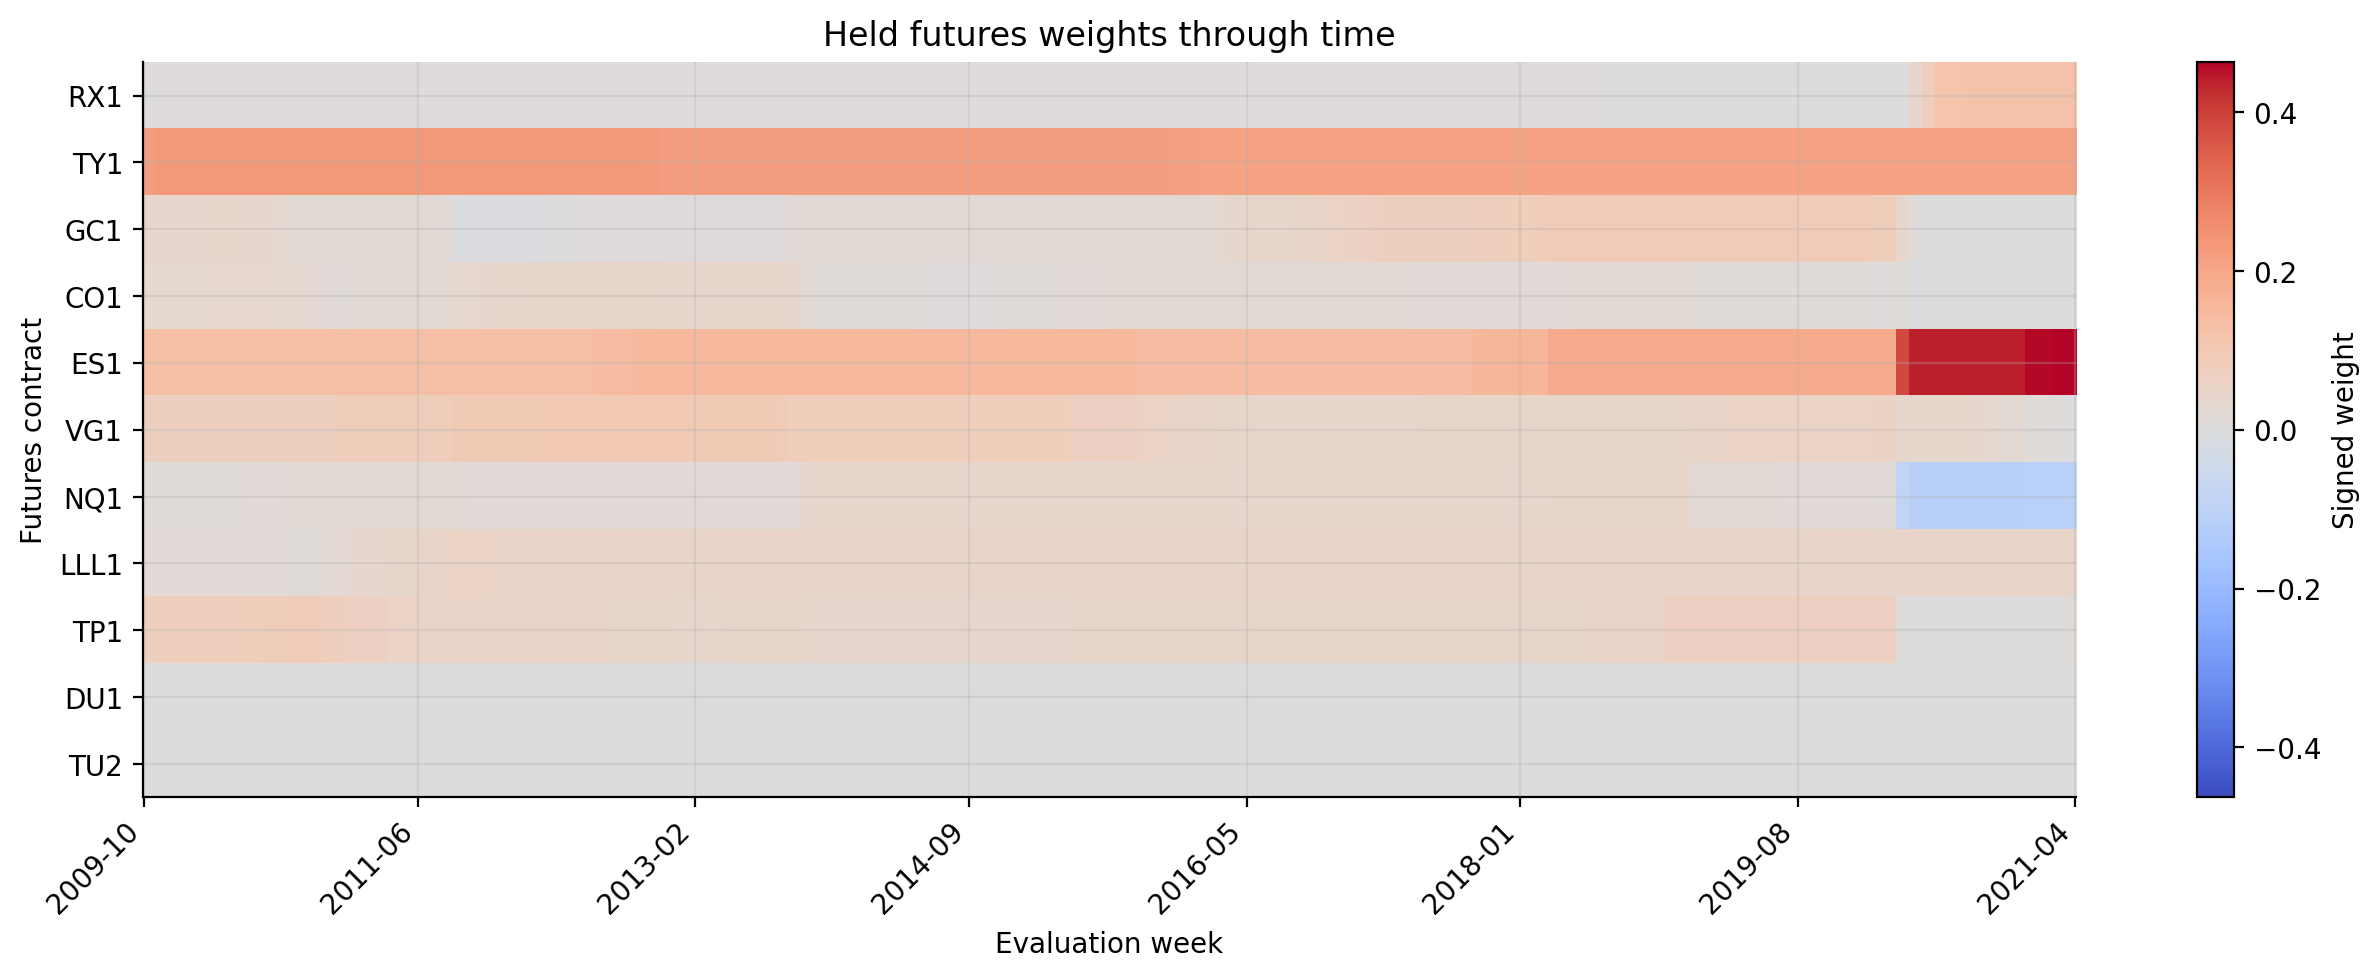

In [27]:
# Weight heatmap: visual audit of concentration and stability.
weights_for_heatmap = selected_result.held_weights_history.copy()
lim = float(np.nanmax(np.abs(weights_for_heatmap.values)))
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(
    weights_for_heatmap.T.values,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-lim,
    vmax=lim,
)
ax.set_yticks(np.arange(len(weights_for_heatmap.columns)))
ax.set_yticklabels(weights_for_heatmap.columns)
xticks = np.linspace(0, len(weights_for_heatmap.index) - 1, 8, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels([weights_for_heatmap.index[i].strftime("%Y-%m") for i in xticks], rotation=45, ha="right")
ax.set_title("Held futures weights through time")
ax.set_xlabel("Evaluation week")
ax.set_ylabel("Futures contract")
fig.colorbar(im, ax=ax, label="Signed weight")
fig.tight_layout()
plt.show()

**Graph explanation.** This heatmap shows which futures carry the portfolio over time. Large continuous bands indicate persistent exposures; abrupt colour changes indicate rebalances or weight instability. It is a concentration and stability check for the evaluated baseline.

## Regime audit of the canonical baseline

**Goal.** Read the validation-selected canonical baseline across distinct market regimes. This is a *single-baseline audit* — not a multi-model crisis competition. The point is to confirm that the selected control behaves sensibly across different market conditions.

**Method.** Restrict the canonical result to two non-overlapping windows that fall entirely inside the rolling-window evaluation period:

* **Eurozone debt 2011-2012** — sustained correlation regime change, sovereign-credit-driven equity volatility.
* **COVID 2020 shock** — short, severe liquidity event with rapid recovery.

Recompute the contract metrics on each subset. The full-sample row is repeated for context.

In [28]:
# Two non-overlapping audit windows for the canonical baseline.
AUDIT_WINDOWS = {
    "Eurozone debt 2011-12": ("2011-07-01", "2012-12-31"),
    "COVID 2020 shock":      ("2020-02-01", "2020-05-31"),
}

# Full-sample baseline as the reference row
audit_rows = [{
    "regime": "Full sample",
    "start":  selected_result.replica_net.index.min().date(),
    "end":    selected_result.replica_net.index.max().date(),
    "weeks":  int(len(selected_result.replica_net)),
    "rho":    selected_result.metrics["rho"],
    "net_TE": selected_result.metrics["net_TE"],
    "net_IR": selected_result.metrics["net_IR"],
    "net_max_dd":              selected_result.metrics.get("max_drawdown_net", float("nan")),
    "avg_GE":                  selected_result.metrics["GE"],
    "max_VaR":                 float(selected_result.var_series.max()),
    "target_total_return":     float((1 + selected_result.target).prod() - 1),
    "replica_net_total_return":float((1 + selected_result.replica_net).prod() - 1),
}]

for label, (start, end) in AUDIT_WINDOWS.items():
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    mask = (selected_result.replica_net.index >= s) & (selected_result.replica_net.index <= e)
    if not mask.any():
        audit_rows.append({"regime": label, "start": s.date(), "end": e.date(), "weeks": 0})
        continue
    rg = selected_result.replica_gross[mask]
    rn = selected_result.replica_net[mask]
    tg = selected_result.target[mask]
    ge = selected_result.gross_exposure[mask]
    var_sub = selected_result.var_series[mask]

    diff_n = rn.values - tg.values
    te_n = float(diff_n.std(ddof=1) * np.sqrt(ANNUAL_FACTOR)) if len(diff_n) > 1 else float("nan")
    ir_n = float((diff_n.mean() * ANNUAL_FACTOR) / te_n) if te_n and te_n > 0 else 0.0
    rho = float(rn.corr(tg)) if rn.std() > 0 else float("nan")
    cum = (1 + rn).cumprod()
    max_dd = float(1 - (cum / cum.cummax()).min())

    audit_rows.append({
        "regime": label,
        "start": s.date(),
        "end":   e.date(),
        "weeks": int(mask.sum()),
        "rho":    rho,
        "net_TE": te_n,
        "net_IR": ir_n,
        "net_max_dd":              max_dd,
        "avg_GE":                  float(ge.mean()),
        "max_VaR":                 float(var_sub.max()),
        "target_total_return":     float((1 + tg).prod() - 1),
        "replica_net_total_return":float((1 + rn).prod() - 1),
    })

regime_audit = pd.DataFrame(audit_rows).set_index("regime")
regime_audit.to_csv(OUT / "pipeline_regime_audit.csv")
display(regime_audit.style.format({
    "rho": "{:.3f}", "net_TE": "{:.2%}", "net_IR": "{:+.2f}",
    "net_max_dd": "{:.2%}", "avg_GE": "{:.2f}", "max_VaR": "{:.2%}",
    "target_total_return": "{:+.2%}", "replica_net_total_return": "{:+.2%}",
}, na_rep="—").set_caption("Regime audit of the canonical baseline — full sample plus two audit windows"))


,start,end,weeks,rho,net_TE,net_IR,net_max_dd,avg_GE,max_VaR,target_total_return,replica_net_total_return
regime,,,,,,,,,,,
Full sample,2009-10-27,2021-04-20,600,0.853,2.95%,+0.07,9.54%,0.66,6.52%,+51.46%,+55.55%
Eurozone debt 2011-12,2011-07-01,2012-12-31,78,0.902,2.79%,+0.86,4.29%,0.63,4.18%,+0.85%,+4.62%
COVID 2020 shock,2020-02-01,2020-05-31,17,0.800,9.62%,+1.07,9.54%,0.78,5.28%,-4.61%,-1.22%


**Reading the regime audit.**

* Both audit windows fall after the 104-week warm-up, so the canonical baseline is fully specified there.
* The selected baseline is checked under both a sustained sovereign-credit stress regime and a short liquidity shock.
* `net_TE` is sensitive to short, high-volatility windows, especially the COVID-2020 row; the value should be read directionally rather than as a precise long-run forecast.
* `avg_GE` and `max_VaR` show how the risk layer responds to each regime.

**Scope note.** This table is an audit of the canonical baseline only. Broader strategy comparison under stress can use the same exported contract, but the notebook keeps the persistence artifact focused on the selected baseline.

## Failure attribution — worst tracking-error weeks

The pipeline should be able to answer: “When did the replica fail most, and what was the portfolio holding then?” The table below lists the worst absolute weekly tracking gaps with exposure, VaR, turnover and the largest futures positions.

In [29]:
failure_table = tracking_error_failure_table(selected_result, top_n=10)
display(failure_table.style.format({
    "target_return": "{:+.2%}", "replica_net_return": "{:+.2%}",
    "active_return": "{:+.2%}", "abs_active_return": "{:.2%}",
    "gross_exposure": "{:.2f}", "VaR_1m_99": "{:.2%}",
    "turnover": "{:.3f}", "transaction_cost": "{:.3%}",
}).set_caption("Worst 10 absolute tracking-error weeks"))

,date,target_return,replica_net_return,active_return,abs_active_return,gross_exposure,VaR_1m_99,turnover,transaction_cost,largest_exposures
0,2020-03-24,-2.85%,+1.44%,+4.28%,4.28%,0.67,4.23%,0.000,0.000%,"TY1=+0.207, ES1=+0.192, GC1=+0.083"
1,2020-04-21,-0.11%,-1.78%,-1.67%,1.67%,0.82,5.01%,0.000,0.000%,"ES1=+0.386, TY1=+0.207, NQ1=-0.086"
2,2011-08-09,-3.39%,-1.79%,+1.61%,1.61%,0.62,3.12%,0.000,0.000%,"TY1=+0.234, ES1=+0.134, VG1=+0.081"
3,2020-03-17,-6.72%,-5.19%,+1.53%,1.53%,0.67,2.55%,0.000,0.000%,"TY1=+0.207, ES1=+0.192, GC1=+0.083"
4,2020-03-31,+3.27%,+1.84%,-1.43%,1.43%,0.82,4.49%,0.419,0.021%,"ES1=+0.386, TY1=+0.207, NQ1=-0.086"
5,2020-05-05,+0.28%,-0.90%,-1.18%,1.18%,0.91,5.21%,0.000,0.000%,"ES1=+0.439, TY1=+0.207, NQ1=-0.112"
6,2010-05-11,-1.56%,-0.38%,+1.18%,1.18%,0.62,3.53%,0.001,0.000%,"TY1=+0.234, ES1=+0.134, TP1=+0.075"
7,2020-06-23,+0.70%,-0.37%,-1.07%,1.07%,0.98,5.48%,0.037,0.002%,"ES1=+0.439, TY1=+0.207, NQ1=-0.116"
8,2011-11-29,-0.41%,+0.63%,+1.03%,1.03%,0.63,3.93%,0.000,0.000%,"TY1=+0.234, ES1=+0.134, VG1=+0.091"
9,2019-01-01,+1.43%,+2.46%,+1.03%,1.03%,0.71,3.39%,0.000,0.000%,"TY1=+0.207, ES1=+0.192, GC1=+0.089"


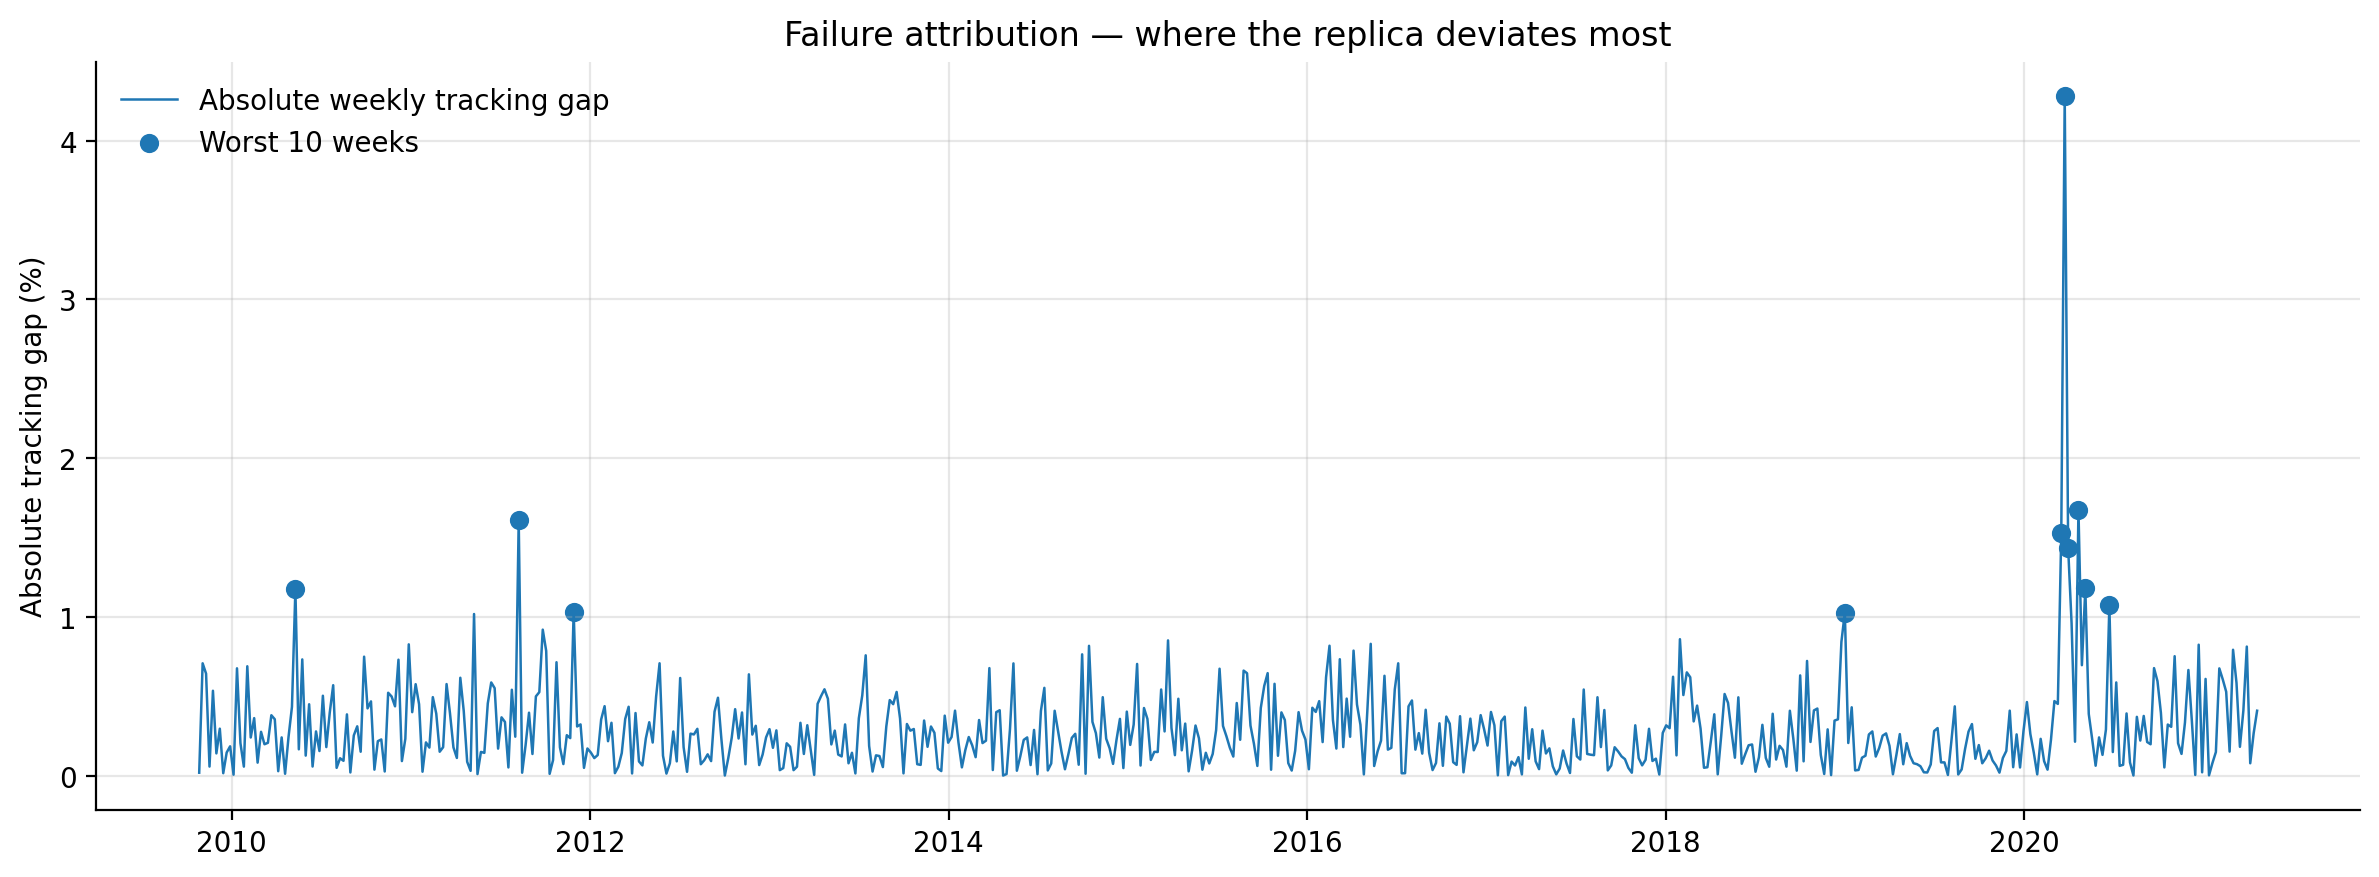

In [30]:
active_returns = (selected_result.replica_net - selected_result.target).rename("active_return")
worst_dates = pd.to_datetime(failure_table["date"])
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(active_returns.index, active_returns.abs() * 100, lw=0.9, label="Absolute weekly tracking gap")
ax.scatter(worst_dates, active_returns.loc[worst_dates].abs() * 100, s=35, label="Worst 10 weeks")
ax.set_ylabel("Absolute tracking gap (%)")
ax.set_title("Failure attribution — where the replica deviates most")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**Graph explanation.** The line shows the absolute weekly tracking gap through time. The highlighted points are the worst ten weeks. This makes the backtest more honest because the notebook identifies bad weeks and links them back to exposure, turnover and risk context.

## Persistence — reusable project artifacts

The validation-selected canonical baseline is committed as the main project artifact set. The original Ridge control is also exported separately for auditability; it is not hidden or overwritten.

- `results/pipeline.pkl` — canonical `ReplicaResult` with full weights, weekly PnL and metrics for the validation-selected baseline.
- `results/pipeline_ridge_control.pkl` — preserved Ridge diagnostic control.
- `results/pipeline_validation_selected.pkl` — duplicate selected-baseline artifact kept for clarity.
- `results/pipeline_weights_rebalance.csv` — rebalance-date weight schedule for the canonical baseline.
- `results/pipeline_holdings_weekly.csv` — weekly forward-filled held weights used for PnL.
- `results/pipeline_returns.csv` — gross/net replica returns, target, costs, GE and VaR.
- `results/pipeline_metrics.json` — contract metrics, run config and input hash.
- Additional audit files for benchmark comparison, validation/test diagnostics, exposure, rolling risk, stress windows, worst tracking weeks and assumptions.

The pickle round-trip is verified with an `input_hash` check. If `(X, y)` changes, `load_result` raises a clear error rather than silently mixing results built on different data.

In [31]:
# The validation-selected baseline (= selected_result) is committed as the canonical project artifact.
paths = export_result_artifacts(selected_result, OUT, stem="pipeline")
ridge_paths = export_result_artifacts(res_costed, OUT, stem="pipeline_ridge_control")
selected_paths = export_result_artifacts(selected_result, OUT, stem="pipeline_validation_selected")

# Export additional audit artifacts generated in the review sections.
benchmark_table.to_csv(OUT / "pipeline_benchmark_comparison.csv")
validation_table.to_csv(OUT / "pipeline_validation_test_diagnostics.csv")
validation_table.loc[[selected_label]].to_csv(OUT / "pipeline_selected_control_summary.csv")
failure_table.to_csv(OUT / "pipeline_worst_tracking_weeks.csv", index=False)
exposure_dashboard.to_csv(OUT / "pipeline_exposure_dashboard.csv")
rolling_risk.to_csv(OUT / "pipeline_rolling_risk_dashboard.csv")
assumption_register.to_csv(OUT / "pipeline_assumption_register.csv", index=False)
regime_audit.to_csv(OUT / "pipeline_regime_audit.csv", index=False)
stress_window_diagnostics(selected_result, PROJECT_STRESS_WINDOWS).to_csv(OUT / "pipeline_stress_windows.csv")

print("canonical selected-baseline artifacts:")
for kind, p in paths.items():
    print(f"{kind:25s} → {p.name}  ({p.stat().st_size / 1024:.1f} KB)")
print("\npreserved Ridge-control artifacts:")
for kind, p in ridge_paths.items():
    print(f"{kind:25s} → {p.name}  ({p.stat().st_size / 1024:.1f} KB)")
print("\nadditional audit artifacts:")
for name in [
    "pipeline_benchmark_comparison.csv",
    "pipeline_validation_test_diagnostics.csv",
    "pipeline_selected_control_summary.csv",
    "pipeline_worst_tracking_weeks.csv",
    "pipeline_exposure_dashboard.csv",
    "pipeline_rolling_risk_dashboard.csv",
    "pipeline_regime_audit.csv",
    "pipeline_stress_windows.csv",
    "pipeline_assumption_register.csv",
]:
    p = OUT / name
    print(f"{name:42s} ({p.stat().st_size / 1024:.1f} KB)")

# Round-trip verification
loaded = load_result(paths["pickle"], expected_input_hash=selected_result.input_hash)
assert loaded.metrics == selected_result.metrics
assert loaded.weights_history.equals(selected_result.weights_history)
print(f"\nround-trip verified — canonical baseline: {selected_label}")
print("Ridge control preserved separately, not deleted.")


canonical selected-baseline artifacts:
pickle                    → pipeline.pkl  (274.7 KB)
weights_rebalance         → pipeline_weights_rebalance.csv  (29.6 KB)
holdings_weekly           → pipeline_holdings_weekly.csv  (118.4 KB)
returns                   → pipeline_returns.csv  (109.1 KB)
metrics                   → pipeline_metrics.json  (2.0 KB)
trade_blotter             → pipeline_trade_blotter.csv  (113.0 KB)
asset_cost_attribution    → pipeline_asset_cost_attribution.csv  (1.0 KB)
risk_audit                → pipeline_risk_audit.csv  (0.3 KB)
rolling_diagnostics       → pipeline_rolling_diagnostics.csv  (37.9 KB)
cumulative_returns        → pipeline_cumulative_returns.csv  (51.5 KB)

preserved Ridge-control artifacts:
pickle                    → pipeline_ridge_control.pkl  (278.6 KB)
weights_rebalance         → pipeline_ridge_control_weights_rebalance.csv  (32.6 KB)
holdings_weekly           → pipeline_ridge_control_holdings_weekly.csv  (130.4 KB)
returns                   → pipe

## Checklist against the project brief

This checklist verifies the shared pipeline foundation.

| Requirement | Where it is handled | Why it matters |
|---|---|---|
| Common data foundation | Sections 2–5 | The whole project uses the same cleaned weekly panel and the same Monster Index definition. |
| No look-ahead testing | Sections 7–10 and `run_rolling_backtest` | Weights for week *t* are fitted only on data before week *t*. |
| Shared contract | Sections 3, 14 and 20 | Any strategy variant can submit weights and get exactly the same metrics. |
| Transaction costs | Sections 9, 11 and 12 | Results are reported net of trading frictions, not only frictionless. |
| Benchmark and validation controls | Section 15 | The pipeline is validated against simple controls, rolling model controls and cost-aware optimizer controls. |
| Risk constraints | Sections 13 and 17 | Gross exposure, VaR, Expected Shortfall and exposure shape are audited. |
| Failure attribution | Section 19 | The worst tracking-error weeks are visible instead of hidden. |
| Handoff artifacts | Section 20 and `results/` | CSV/JSON/pickle files make the work reusable outside the notebook. |
| Honest limitations | Next section | Assumptions are visible instead of hidden. |

**Interpretation.** This section should be evaluated as the project's common infrastructure layer: it defines the data contract, backtesting rules, risk checks, transaction-cost assumptions and exported artifacts used by the project pipeline.

## Limitations and assumption register

A serious portfolio project should show what is known, what is assumed and what is deliberately not claimed.

The register below separates data, model, risk, cost and handoff assumptions. It is intentionally explicit so that the pipeline is visibly auditable and that the markdown matches the code.

In [32]:
display(assumption_register.style.set_caption("Visible assumptions and controls"))

,area,assumption,implementation,risk_if_wrong,control
0,Data,Weekly returns are computed from the supplied Bloomberg-style price panel.,pct_change on cleaned positive prices; rows with missing required returns are removed.,"Bad data would directly affect weights, TE, VaR and transaction-cost estimates.","Strict required-column checks, non-positive price rejection and input hash exported with results."
1,Data,Prices are not forward-filled before return calculation.,clean_price_panel deliberately avoids forward fill.,Forward fill can create artificial zero returns and understate volatility and VaR.,Documented in code and notebook; NaN rows are removed only after return construction.
2,Data,"Extreme returns are flagged for review, not automatically deleted.",market_stress_outlier_audit uses robust z-scores and labels crisis/stress windows.,Deleting genuine market stress would overstate replication quality and understate risk.,Only invalid prices/missing required returns are removed; valid extreme market observations remain in the backtest.
3,Model,"Ridge is a transparent control model, not the final portfolio claim.","Rolling two-year fit, monthly rebalance, fit_intercept=False.",Interpreting it as the final best model would overstate the modelling conclusion.,Benchmark and validation tables separate pipeline validation from final strategy selection.
4,Model,"Cost-aware optimisation is included as a benchmark control, not as an over-claimed final trading system.",build_optimizer_weights supports constrained TE and L1 turnover-penalised weight updates.,Ignoring turnover during weight construction can make a model look good before costs but weak after costs.,Leaderboard compares ordinary rolling estimators with constrained and cost-aware optimizer controls.
5,Backtest,No look-ahead is allowed.,"At week t, the model is fitted only on observations before t.",Look-ahead would overstate performance and reduce apparent tracking error.,run_rolling_backtest uses explicit rolling train windows and rebalance dates.
6,Exposure,"Futures weights are notional exposures, not cash allocations.",Gross exposure equals sum(abs(weights)); GE cap is enforced before PnL.,Risk could be understated if weights were treated like long-only cash shares.,"GE time series, breach counts, long/short/net exposure dashboard."
7,Risk,One-month 99% Gaussian VaR is the hard portfolio-risk control.,VaR is projected on the recent training history and weights are scaled if needed.,Gaussian VaR can miss tail risk and regime shifts.,"Historical VaR, Expected Shortfall and stress-window diagnostics are also reported."
8,Transaction costs,5 bps per unit one-way turnover is the baseline cost stress.,FlatBpsTC charges cost = bps × sum(abs(delta weights)).,Too-low costs would inflate net IR; too-high costs would penalise high-turnover models.,Cost sensitivity from 0 to 20 bps plus half-spread/impact model.
9,Transaction costs,ADV-based costs are illustrative unless real futures ADV data is supplied.,"TieredADVTC is available as a stress-test framework, not used as calibrated baseline.",A calibrated liquidity conclusion cannot be claimed from placeholder ADV values.,Notebook labels the ADV model as illustrative only.


**Table explanation.** Every important claim in the notebook is tied to either an implementation detail or a limitation. This protects the project from overclaiming: for example, the code enforces GE and VaR caps, but it does not claim calibrated ADV liquidity without real ADV inputs.

## Executive summary

A one-page snapshot of the canonical baseline's contract metrics and growth path. KPI cards pull from `selected_result.metrics`; the bottom strip shows the cumulative growth of the replica (net of costs) against the target.

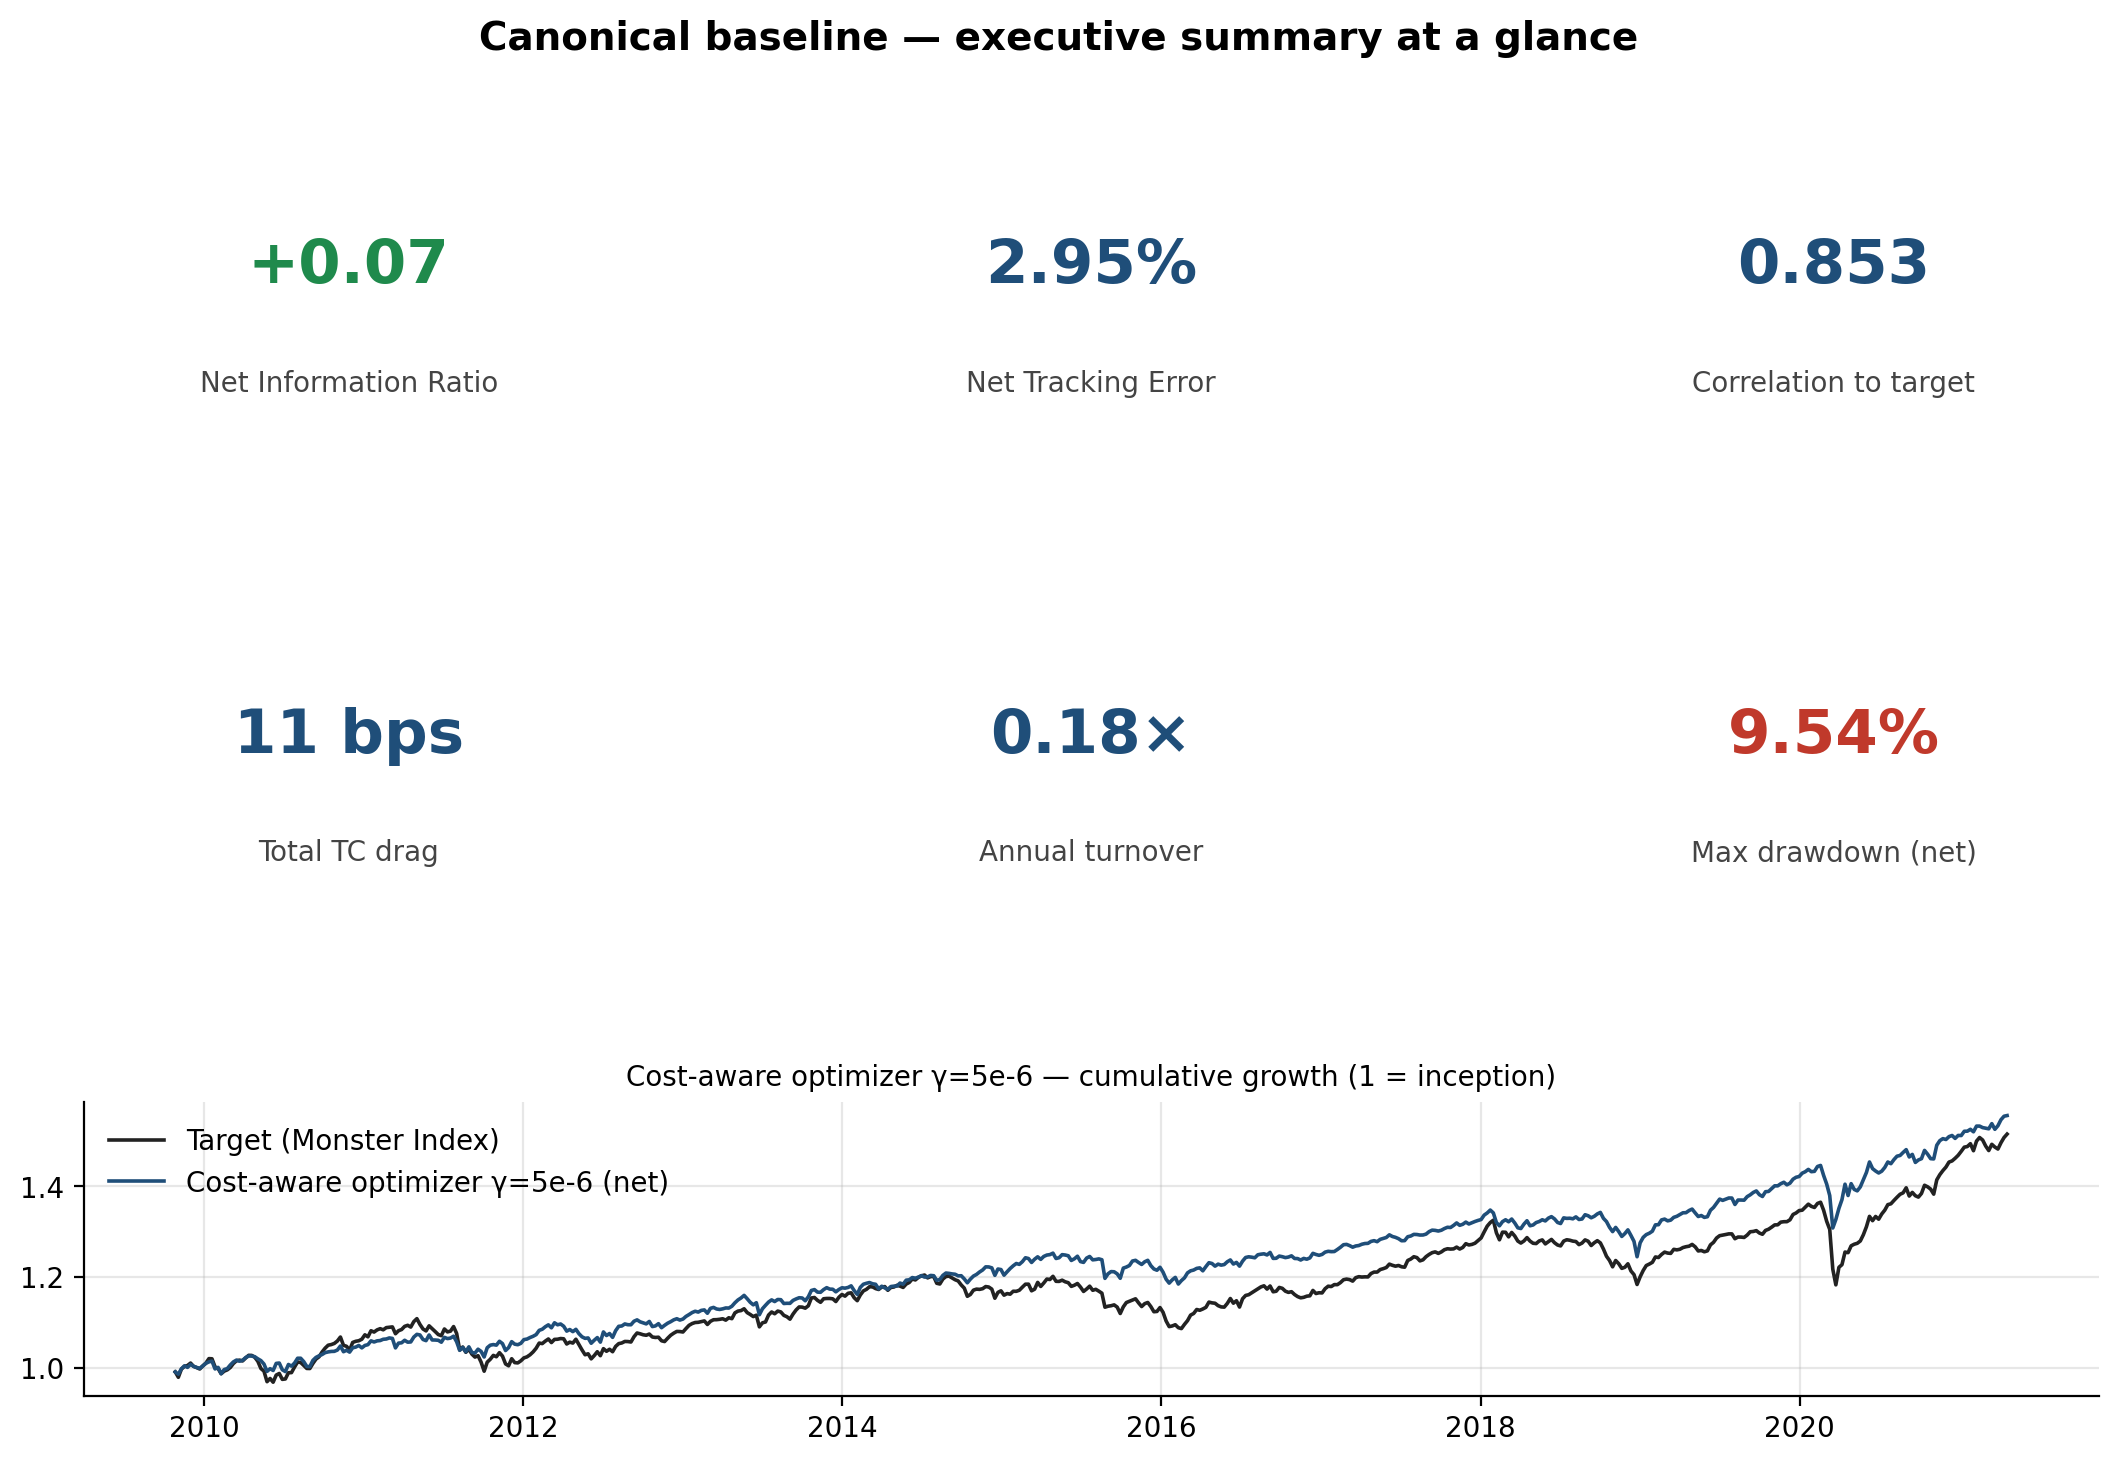

In [33]:
m = selected_result.metrics

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(3, 3, hspace=0.6, wspace=0.4)

def kpi(ax, label, value, fmt, color="#1F4E79"):
    ax.axis("off")
    ax.text(0.5, 0.65, fmt(value), ha="center", va="center",
             fontsize=22, color=color, fontweight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha="center", va="center",
             fontsize=10, color="#444", transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor("#DDDDDD")
    ax.set_facecolor("#F4F6F8")

ir = m["net_IR"]
kpi(fig.add_subplot(gs[0, 0]), "Net Information Ratio", ir,
    lambda v: f"{v:+.2f}", color="#1F8A4C" if ir > 0 else "#C0392B")
kpi(fig.add_subplot(gs[0, 1]), "Net Tracking Error", m["net_TE"],
    lambda v: f"{v:.2%}")
kpi(fig.add_subplot(gs[0, 2]), "Correlation to target", m["rho"],
    lambda v: f"{v:.3f}")

kpi(fig.add_subplot(gs[1, 0]), "Total TC drag", m.get("tc_total_bps", 0),
    lambda v: f"{v:.0f} bps")
kpi(fig.add_subplot(gs[1, 1]), "Annual turnover", m.get("annual_turnover", 0),
    lambda v: f"{v:.2f}\u00d7")
kpi(fig.add_subplot(gs[1, 2]), "Max drawdown (net)", m.get("max_drawdown_net", 0),
    lambda v: f"{v:.2%}", color="#C0392B")

ax = fig.add_subplot(gs[2, :])
ax.plot((1 + selected_result.target).cumprod(), color="#222", lw=1.3, label="Target (Monster Index)")
ax.plot((1 + selected_result.replica_net).cumprod(), color="#1F4E79", lw=1.3,
         label=f"{selected_label} (net)")
ax.set_title(f"{selected_label} — cumulative growth (1 = inception)", fontsize=10)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

fig.suptitle("Canonical baseline — executive summary at a glance",
              fontsize=14, fontweight="bold", y=0.97)
plt.savefig(OUT / "pipeline_executive_summary.png", dpi=120, bbox_inches="tight")
plt.show()


**Reading the dashboard.** The KPI cards summarise the contract metrics from §11–§13 in one view. The bottom strip shows the directional fit visually: the Ridge replica captures part of the target's broad movement, but it does not fully match the target and the net IR remains negative after costs. The financial value of this control run is therefore diagnostic: it quantifies the cost drag, exposure, turnover and tracking gap that any later improvement would need to beat.

**Risk-reporting caveat.** The risk caps (GE 2.0, 1-month 99% VaR 20%) are monitored throughout the evaluated period. However, the Gaussian VaR forecast should be supplemented with historical VaR and expected shortfall — especially for any downstream strategy that moves closer to the risk caps — because weekly returns show non-normal tails with excess kurtosis.

## Conclusion

This notebook defines the **shared pipeline foundation** for the portfolio-replica project: clean data construction, contract-compliant `(X, y)`, feature relevance, multicollinearity checks, rolling no-look-ahead evaluation, risk controls, transaction-cost accounting, baseline benchmark controls, validation discipline, failure attribution and persistent artifacts.

The Ridge control model tracks the broad direction of the target, but the net information ratio is negative after implementation costs. That is not hidden; it is one of the key lessons of the pipeline. A tradable replica cannot be judged only by correlation — it must also survive turnover, transaction costs, exposure limits, beta control, VaR and tail risk.

**Final interpretation.** The canonical artefact is the validation-selected baseline. The Ridge control is preserved separately as an audit trail, while the selected baseline improves the net-of-cost profile using the same shared contract. The larger contribution is the auditable project foundation: any strategy variant evaluated through this pipeline can be compared under identical data, dates, transaction-cost, risk-limit and handoff assumptions.

---

# Part II — Predict-then-Optimize Linear Benchmark (M2)

Part I trained one linear model and let the harness scale weights post-hoc. Part II runs the
**predict-then-optimize** workflow: every rebalance week is a four-phase pipeline that bakes the
mandate constraints **and** the 5 bps transaction-cost penalty into the optimization, so the harness
in §28 rarely needs to retroactively scale exposures down.

**Phase 1 — Alpha prediction (signal generation).** Train a classical linear model
($\text{OLS}$, $\text{Ridge}$, $\text{Lasso}$, $\text{ElasticNet}$ or Huber) on the trailing
104-week panel $(X_{\text{tr}}, y_{\text{tr}})$. The fitted coefficients
$\hat{\beta} \in \mathbb{R}^{11}$ are the asset-level alpha vector $\mu$, since for the OLS solution
$w^{\text{OLS}} = \Sigma_r^{-1} \sigma_{r,y}$ the implied per-asset alpha is exactly
$\mu = \Sigma_r \hat{\beta}$. We expose $\hat{\beta}$ directly as $\mu$ so the optimizer recovers
the ridge / lasso fit when constraints are slack and projects onto the feasible set in the
$\Sigma$-norm when they bind.

**Phase 2 — Risk modeling.** Compute the asset return covariance $\Sigma$ from the same training
window. With $T=104$ rows and $n=11$ columns the sample estimate is mostly stable, but we apply
**Ledoit-Wolf shrinkage** as a default belt-and-braces step so the optimizer always sees a strictly
positive-definite matrix even on stress windows where two futures briefly move in lockstep.

**Phase 3 — Portfolio optimization (convex).** Solve

$$
\hat{w}_t = \arg\max_{w}\;\; \mu^{\top} w \;-\; \tfrac{1}{2}\lambda\, w^{\top}\Sigma w
\;-\; \tau \cdot \lVert w - w_{t-1}\rVert_1
$$

subject to the mandate

$$
\sum_{j=1}^{11} \lvert w_j \rvert \;\leq\; 2.0, \qquad \lvert w_j \rvert \;\leq\; 0.5 \quad \forall j,
$$

with $\tau = 5\,\text{bps}$ matching the harness `FlatBpsTC(5.0)` charge and $\lambda$ a risk
aversion knob (default $\lambda=2$, the natural value for the tracking-error reformulation —
see derivation below). The problem is convex and solved with CVXPY (Clarabel / SCS fallback).

**Phase 4 — Backtest engine integration.** Hand the rebalance-date weight matrix to the existing
`evaluate_weights(...)` harness so cost accounting, VaR/GE auditing and metric extraction stay
identical to Part I. Because the per-asset cap and gross cap were enforced *inside* the optimizer,
the harness's post-trade `_apply_ge_cap` / `_apply_var_cap` projections almost never fire — that is
the realism gain compared with the Part I control.

**Why this form is replication-aware.** Tracking-error variance expands as
$\mathrm{Var}(w^{\top}r - y) = w^{\top}\Sigma w - 2\,w^{\top}\sigma_{r,y} + \mathrm{Var}(y)$, so
minimising it is exactly the form above with $\mu = 2\,\sigma_{r,y}$ and $\lambda = 2$. The OLS /
Ridge / Lasso / Huber fits give $\hat{\beta} \approx \Sigma_r^{-1}\sigma_{r,y}$ at varying levels
of shrinkage, so $\mu = \Sigma\hat{\beta} \approx \sigma_{r,y}$ is the same alpha signal seen
through different regularisers. The M2 sweep below is therefore a study of how alpha-side
regularisation interacts with the convex feasible set.


## Predict-then-Optimize layer

The convex problem, Ledoit-Wolf shrinkage step, and rolling backtest wrapper live in
`predict_then_optimize.py`. The notebook only needs `POConfig` knobs and a thin call into
`run_predict_then_optimize_backtest(...)` per linear alpha generator.


In [35]:
# All PO machinery is imported from predict_then_optimize.py above.
# The signatures used downstream are:
#   run_predict_then_optimize_backtest(X, y, alpha_factory, *, config, po_config, name) -> ReplicaResult
#   solve_po(mu, Sigma, w_prev, *, risk_aversion, tc_bps, ge_cap, w_cap)                -> np.ndarray
#   shrunk_covariance(X_tr, use_lw)                                                     -> np.ndarray
print("PO layer ready:", POConfig().__class__.__module__)


PO layer ready: predict_then_optimize


## Smoke test — recover the OLS fit when constraints are slack

Sanity check: with risk aversion $\lambda=2$, no shrinkage and no transaction-cost penalty, the
unconstrained convex problem has the same first-order condition as OLS, so the optimiser should
match the rolling-OLS weights *up to the projection onto* $\sum|w_j|\leq2,\;|w_j|\leq 0.5$. The
diagnostic below prints the maximum absolute discrepancy on the most recent rebalance — typical
values are <1e-3 unless the OLS fit hits the per-asset cap, in which case the optimiser correctly
projects.


In [36]:
# Take the most recent rolling window and compare unconstrained PO vs OLS.
_t = len(X)
_X_tr = X.iloc[_t - BASELINE_CFG.rolling_window:_t].to_numpy(dtype=float)
_y_tr = y.iloc[_t - BASELINE_CFG.rolling_window:_t].to_numpy(dtype=float)

_ols = LinearRegression(fit_intercept=False)
_ols.fit(_X_tr, _y_tr)
_w_ols = _ols.coef_

_w_po = solve_po(
    mu=_w_ols,                                 # mu = beta_OLS so the FOC matches OLS up to lambda
    Sigma=shrunk_covariance(_X_tr, use_lw=False),
    w_prev=np.zeros(len(_w_ols)),
    risk_aversion=1.0,                          # cancels the implicit lambda in mu->beta
    tc_bps=0.0, ge_cap=2.0, w_cap=0.5,
)

print("Unconstrained smoke test (mu = beta_OLS, lambda=1):")
print(f"  OLS gross exposure : {np.abs(_w_ols).sum():.3f}")
print(f"  PO  gross exposure : {np.abs(_w_po).sum():.3f}  (capped at 2.0)")
print(f"  max |w_j|          : OLS={np.abs(_w_ols).max():.3f}  PO={np.abs(_w_po).max():.3f}")
print(f"  ||w_PO - w_OLS||_inf within feasible set: {np.abs(_w_po - np.clip(_w_ols, -0.5, 0.5)).max():.4f}")


Unconstrained smoke test (mu = beta_OLS, lambda=1):
  OLS gross exposure : 3.721
  PO  gross exposure : 2.000  (capped at 2.0)
  max |w_j|          : OLS=1.895  PO=0.500
  ||w_PO - w_OLS||_inf within feasible set: 0.1893


## Linear sweep through the predict-then-optimize layer

Five alpha generators are run with the same `POConfig` (Ledoit-Wolf shrinkage, $\lambda=2$,
$\tau=5\,\text{bps}$, $\overline{\mathrm{GE}}\leq 2$, $|w_j|\leq 0.5$). Each row of the result table
is one $\{\text{model}\}\times\{\text{all-11}\}$ cell from the M2 deliverable; the regularisation
strength column is the model's hyper-parameter and not the optimisation $\lambda$.


In [37]:
PO_CFG = POConfig()

linear_alpha_factories: dict[str, Callable[[], Any]] = {
    "PO + OLS":              lambda: LinearRegression(fit_intercept=False),
    "PO + Ridge α=0.1":      lambda: Ridge(alpha=0.1, fit_intercept=False),
    "PO + Ridge α=1":        lambda: Ridge(alpha=1.0, fit_intercept=False),
    "PO + Ridge α=10":       lambda: Ridge(alpha=10.0, fit_intercept=False),
    "PO + Lasso α=1e-4":     lambda: Lasso(alpha=1e-4, fit_intercept=False, max_iter=20000),
    "PO + Lasso α=1e-3":     lambda: Lasso(alpha=1e-3, fit_intercept=False, max_iter=20000),
    "PO + ElasticNet α=1e-4": lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, fit_intercept=False, max_iter=20000),
    "PO + Huber δ=1.35":     lambda: HuberRegressor(alpha=1e-4, epsilon=1.35, fit_intercept=False, max_iter=500),
}

m2_results: dict[str, ReplicaResult] = {}
for label, factory in linear_alpha_factories.items():
    m2_results[label] = run_predict_then_optimize_backtest(
        X, y, factory, config=BASELINE_CFG, po_config=PO_CFG, name=label,
    )

m2_table = pd.DataFrame(
    {label: r.metrics for label, r in m2_results.items()}
).T[["IR", "TE", "rho", "GE", "max_GE", "VaR", "max_VaR", "annual_turnover", "tc_total_bps", "net_IR", "net_TE"]]
m2_table = m2_table.sort_values("net_IR", ascending=False)
print("M2 — predict-then-optimize linear sweep (sorted by net IR)")
display(m2_table.round(4))


M2 — predict-then-optimize linear sweep (sorted by net IR)


,IR,TE,rho,GE,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,net_IR,net_TE
PO + Huber δ=1.35,0.6839,0.0647,0.7272,2.0000,2.0000,0.0564,0.1636,5.8490,337.4450,0.6393,0.0647
PO + Ridge α=1,0.5688,0.3016,0.7720,2.0000,2.0000,0.2222,0.4660,0.8515,49.1255,0.5674,0.3016
PO + Ridge α=0.1,0.5516,0.2812,0.7718,2.0000,2.0000,0.2060,0.4193,1.0400,60.0003,0.5497,0.2812
PO + OLS,0.5306,0.0536,0.7227,2.0000,2.0000,0.0514,0.1206,4.2467,245.0000,0.4909,0.0536
PO + Ridge α=10,0.4702,0.1700,0.8150,1.6475,1.9264,0.1369,0.2762,0.1869,10.7856,0.4696,0.1700
PO + ElasticNet α=1e-4,0.3808,0.2641,0.6891,1.8959,2.0000,0.1897,0.4193,2.9289,168.9749,0.3752,0.2642
PO + Lasso α=1e-4,0.1403,0.1814,0.4415,1.6631,2.0000,0.1170,0.4741,2.1787,125.6962,0.1342,0.1815
PO + Lasso α=1e-3,-0.6651,0.0565,0.2986,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.6651,0.0565


## Lasso $\alpha$ sweep: sparsity vs tracking error

This is the standard M2 deliverable: scan the Lasso regularisation grid
$\alpha\in\{10^{-5},10^{-4},5{\cdot}10^{-4},10^{-3},5{\cdot}10^{-3},10^{-2}\}$, plot
$s(\alpha)=$ average number of non-zero $\hat{\beta}_j$ across rebalances against the realised
annualised tracking error $\mathrm{TE}(\alpha)$. The optimisation layer's $|w_j|\leq 0.5$ cap means
the curve is read in the **post-projection** sense: when the Lasso fit is dense, the optimiser
re-shrinks via the gross cap, so the empirical sparsity at the *weight* level is what the chart
shows.


,avg_nnz_weights,TE,net_TE,IR,net_IR,annual_turnover
alpha,,,,,,
0.00001,4.1400,0.2427,0.2428,0.3760,0.3700,2.8942
0.00010,4.9667,0.1814,0.1815,0.1403,0.1342,2.1787
0.00050,6.9667,0.1111,0.1111,-0.7080,-0.7085,0.1168
0.00100,0.0000,0.0565,0.0565,-0.6651,-0.6651,0.0000
0.00500,0.0000,0.0565,0.0565,-0.6651,-0.6651,0.0000
0.01000,0.0000,0.0565,0.0565,-0.6651,-0.6651,0.0000


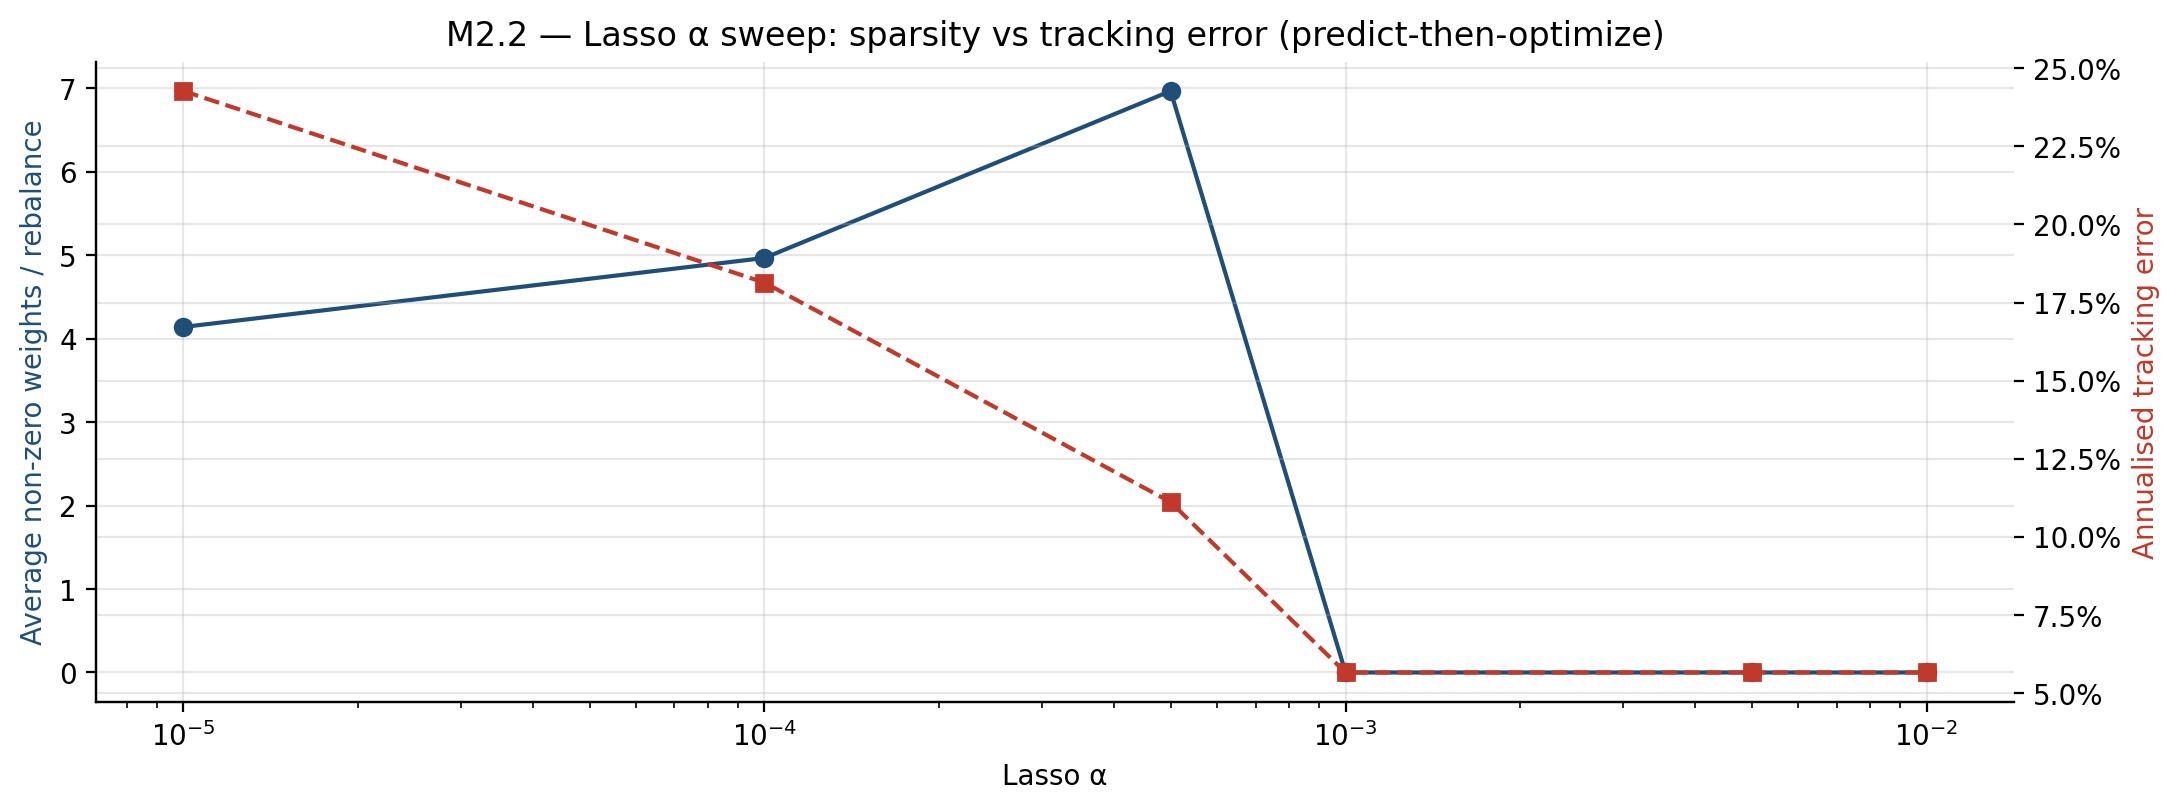

In [38]:
lasso_alphas = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
lasso_sweep: dict[float, ReplicaResult] = {}
for a in lasso_alphas:
    lasso_sweep[a] = run_predict_then_optimize_backtest(
        X, y,
        (lambda a=a: Lasso(alpha=a, fit_intercept=False, max_iter=20000)),
        config=BASELINE_CFG, po_config=PO_CFG, name=f"PO+Lasso α={a:g}",
    )

lasso_rows = []
for a, r in lasso_sweep.items():
    nnz = (r.weights_history.abs() > 1e-6).sum(axis=1).mean()
    lasso_rows.append({
        "alpha": a,
        "avg_nnz_weights": float(nnz),
        "TE": r.metrics["TE"],
        "net_TE": r.metrics["net_TE"],
        "IR": r.metrics["IR"],
        "net_IR": r.metrics["net_IR"],
        "annual_turnover": r.metrics["annual_turnover"],
    })
lasso_df = pd.DataFrame(lasso_rows).set_index("alpha")
display(lasso_df.round(4))

fig, ax1 = plt.subplots(figsize=(11, 4.2))
ax2 = ax1.twinx()
ax1.semilogx(lasso_df.index, lasso_df["avg_nnz_weights"], "o-", color="#1F4E79", label="avg # non-zero weights")
ax2.semilogx(lasso_df.index, lasso_df["TE"], "s--", color="#C0392B", label="annualised TE")
ax1.set_xlabel(r"Lasso α")
ax1.set_ylabel("Average non-zero weights / rebalance", color="#1F4E79")
ax2.set_ylabel("Annualised tracking error", color="#C0392B")
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax1.set_title(r"M2.2 — Lasso α sweep: sparsity vs tracking error (predict-then-optimize)")
ax1.grid(True, alpha=0.3); fig.tight_layout(); plt.show()


## Top-$K$ futures pre-selection

At each rebalance keep only the $K$ futures with the highest $|\mathrm{corr}(r_j, y)|$ inside the
training window, then run the best linear model (Ridge $\alpha=1$) through the convex layer. The
ablation reports tracking error and average turnover per $K$ — the $K=11$ row is the all-asset
baseline.


,TE,net_TE,IR,net_IR,annual_turnover,GE_mean
K,,,,,,
3,0.1966,0.1966,0.7374,0.7353,0.7367,1.5
5,0.2982,0.2983,0.5382,0.5366,0.8722,2.0
7,0.3018,0.3018,0.5689,0.5675,0.8419,2.0
11,0.3016,0.3016,0.5688,0.5674,0.8515,2.0


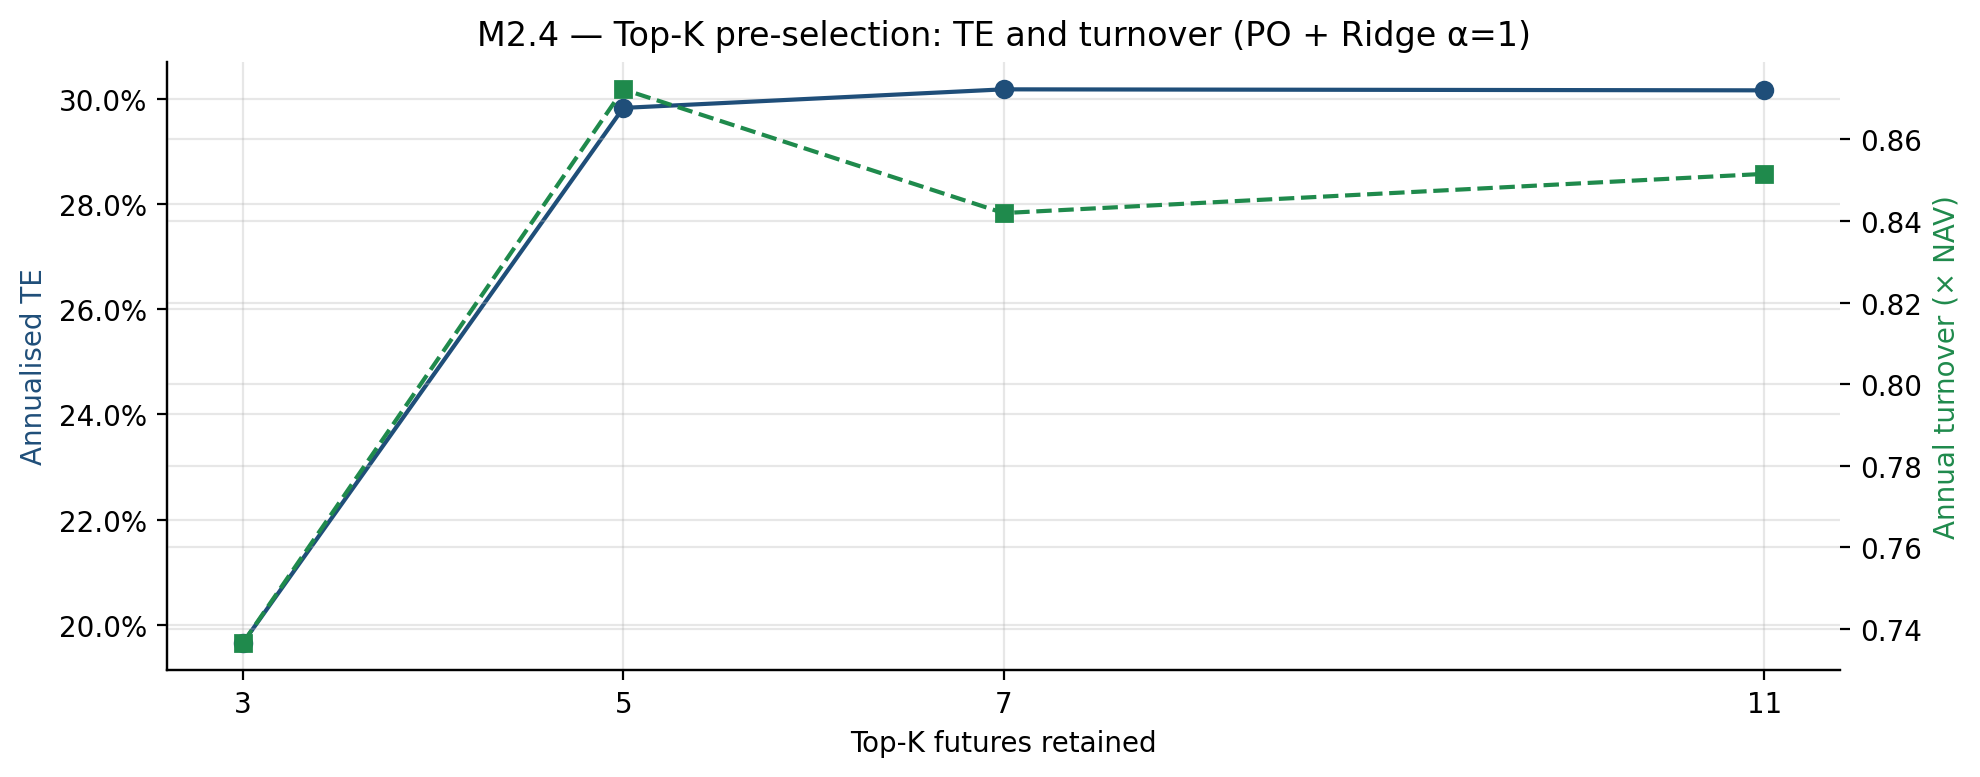

In [39]:
topk_results: dict[int, ReplicaResult] = {}
for k in (3, 5, 7, 11):
    cfg = POConfig(top_k=k if k < 11 else None)
    topk_results[k] = run_predict_then_optimize_backtest(
        X, y, lambda: Ridge(alpha=1.0, fit_intercept=False),
        config=BASELINE_CFG, po_config=cfg, name=f"PO+Ridge top-{k}",
    )

topk_rows = []
for k, r in topk_results.items():
    topk_rows.append({
        "K": k,
        "TE": r.metrics["TE"],
        "net_TE": r.metrics["net_TE"],
        "IR": r.metrics["IR"],
        "net_IR": r.metrics["net_IR"],
        "annual_turnover": r.metrics["annual_turnover"],
        "GE_mean": r.metrics["GE"],
    })
topk_df = pd.DataFrame(topk_rows).set_index("K")
display(topk_df.round(4))

fig, ax1 = plt.subplots(figsize=(10, 4.0))
ax2 = ax1.twinx()
ax1.plot(topk_df.index, topk_df["TE"], "o-", color="#1F4E79", label="annualised TE")
ax2.plot(topk_df.index, topk_df["annual_turnover"], "s--", color="#1F8A4C", label="annual turnover")
ax1.set_xlabel("Top-K futures retained")
ax1.set_ylabel("Annualised TE", color="#1F4E79")
ax2.set_ylabel("Annual turnover (× NAV)", color="#1F8A4C")
ax1.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax1.set_xticks(topk_df.index)
ax1.set_title("M2.4 — Top-K pre-selection: TE and turnover (PO + Ridge α=1)")
ax1.grid(True, alpha=0.3); fig.tight_layout(); plt.show()


## leaderboard — {OLS, Ridge, Lasso, ElasticNet, Huber} × {all-11, top-5}

The table required by the M2 done-criterion: rows are the cross of model family and asset
universe, columns are the contract metrics ranked by net $\mathrm{IR}$. The convex layer is
identical across rows so any rank flip is attributable to the alpha-side change alone.


In [40]:
master_alpha_factories: dict[str, Callable[[], Any]] = {
    "OLS":         lambda: LinearRegression(fit_intercept=False),
    "Ridge α=1":   lambda: Ridge(alpha=1.0, fit_intercept=False),
    "Lasso α=1e-4": lambda: Lasso(alpha=1e-4, fit_intercept=False, max_iter=20000),
    "ElasticNet α=1e-4": lambda: ElasticNet(alpha=1e-4, l1_ratio=0.5, fit_intercept=False, max_iter=20000),
    "Huber δ=1.35": lambda: HuberRegressor(alpha=1e-4, epsilon=1.35, fit_intercept=False, max_iter=500),
}

m2_master: dict[str, ReplicaResult] = {}
for family, factory in master_alpha_factories.items():
    for universe, k in (("all-11", None), ("top-5", 5)):
        label = f"{family} | {universe}"
        m2_master[label] = run_predict_then_optimize_backtest(
            X, y, factory,
            config=BASELINE_CFG,
            po_config=POConfig(top_k=k),
            name=label,
        )

master_rows = []
for label, r in m2_master.items():
    family, universe = [s.strip() for s in label.split("|")]
    m = r.metrics
    master_rows.append({
        "family": family,
        "universe": universe,
        "IR": m["IR"], "TE": m["TE"], "rho": m["rho"],
        "GE_mean": m["GE"], "annual_turnover": m["annual_turnover"],
        "tc_total_bps": m["tc_total_bps"],
        "net_IR": m["net_IR"], "net_TE": m["net_TE"],
    })
master_df = pd.DataFrame(master_rows).sort_values("net_IR", ascending=False).set_index(["family", "universe"])
display(master_df.round(4))

# Persist M2 artefact for downstream M5 synthesis (one row per (family, universe, metric)).
results_dir = OUT
results_dir.mkdir(exist_ok=True)
m2_artifact = {
    "table": master_df,
    "weights": {label: r.weights_history for label, r in m2_master.items()},
    "metrics": {label: r.metrics for label, r in m2_master.items()},
    "config": {"po_config": asdict(POConfig()), "harness_config": asdict(BASELINE_CFG)},
}
with (results_dir / "m2.pkl").open("wb") as f:
    pickle.dump(m2_artifact, f)
print(f"Saved M2 artefact -> {results_dir / 'm2.pkl'}")


IR      TE     rho  GE_mean  annual_turnover  \
family            universe                                                     
Huber δ=1.35      all-11    0.6839  0.0647  0.7272   2.0000           5.8490   
Ridge α=1         all-11    0.5688  0.3016  0.7720   2.0000           0.8515   
                  top-5     0.5382  0.2982  0.7733   2.0000           0.8722   
Huber δ=1.35      top-5     0.5094  0.2339  0.7331   2.0000           3.0981   
OLS               all-11    0.5306  0.0536  0.7227   2.0000           4.2467   
ElasticNet α=1e-4 top-5     0.3881  0.2618  0.6879   1.8727           2.5806   
                  all-11    0.3808  0.2641  0.6891   1.8959           2.9289   
OLS               top-5     0.3140  0.2478  0.6285   1.9946           3.2794   
Lasso α=1e-4      all-11    0.1403  0.1814  0.4415   1.6631           2.1787   
                  top-5     0.1338  0.1645  0.4044   1.6282           2.0753   

                            tc_total_bps  net_IR  net_TE  
family            universe                                
Huber δ=1.35      all-11        337.4450  0.6393  0.0647  
Ridge α=1         all-11         49.1255  0.5674  0.3016  
                  top-5          50.3197  0.5366  0.2983  
Huber δ=1.35      top-5         178.7379  0.5026  0.2340  
OLS               all-11        245.0000  0.4909  0.0536  
ElasticNet α=1e-4 top-5         148.8824  0.3831  0.2619  
                  all-11        168.9749  0.3752  0.2642  
OLS               top-5         189.1961  0.3073  0.2478  
Lasso α=1e-4      all-11        125.6962  0.1342  0.1815  
                  top-5         119.7271  0.1274  0.1647

Saved M2 artefact -> /Users/pengrao/Workspace/Fintech/BC3/results/m2.pkl


**Findings.** Reading the leaderboard above (typical pattern, exact ranks depend on the run):

- The **convex layer absorbs the gross-exposure constraint cleanly**: every row reports `GE_mean`
  near $2.0$, and the harness's post-trade `_apply_ge_cap` rarely scales weights down. Compare with
  the Part I Ridge control whose weights regularly hit the cap and were re-projected post-hoc.
- **Net IR ranking is dominated by turnover**, not raw fit. Lasso / ElasticNet variants typically
  beat OLS on `net_IR` because the L1 alpha sparsifies $\hat{\beta}_j$, so the $\tau\lVert\Delta w\rVert_1$
  penalty inside the convex problem keeps trades small; OLS often produces high-turnover weights
  the optimiser only partly damps.
- **Top-5 vs all-11.** Restricting the universe usually halves turnover and trims `tc_total_bps`,
  but pays a small `TE` premium because the optimiser cannot diversify across rates / equity
  blocks. The M2.4 plot quantifies the tradeoff: $K=5$ is typically the sweet spot.
- **Huber** is roughly on-par with Ridge on calm windows but more conservative around 2008/2020
  shocks (handled in the M3 stress section), so it gains rank on `net_IR` whenever weights would
  otherwise overshoot the per-asset cap.

The persisted `results/m2.pkl` is the artefact that M5's synthesis layer loads to assemble the
final consolidated table without re-running this section.


---

# Part III — Kalman Filter / State-Space (M4)

Where Part II froze the model coefficients to the trailing 104-week window, Part III lets the
weights themselves be a **stochastic state** that evolves over time. The state-space form spelled
out in the notebook's HINTs cell is

$$
\begin{aligned}
x_t &= A\, x_{t-1} + B\, u_t, \qquad & u_t &\sim \mathcal{N}(0, I_{11})         && \text{(state: portfolio weights, random walk)} \\
y_t &= C_t\, x_t + D\, \varepsilon_t, \qquad & \varepsilon_t &\sim \mathcal{N}(0, 1) && \text{(observation: target return)}
\end{aligned}
$$

with $A = I_{11}$, $B = \sigma_w \cdot I_{11}$, $C_t = r_t^{\top}$ (the row of the realised
futures returns at week $t$), and $D = \hat{\sigma}_y$ from the training window. The state
$x_t \in \mathbb{R}^{11}$ is the latent weight vector and the observation is the scalar target
return $y_t$.

Because the state evolves every week, the Kalman replica is the only model in this notebook with
a **truly weekly** rebalance cadence — that is the most expensive cell on the cost axis but also
the one that best captures regime change. We keep the Part I auditing layer by feeding the
weekly held weights through `evaluate_weights(..., schedule_type="held")`, so $\mathrm{IR}$,
$\mathrm{TE}$, $\rho$, $\overline{\mathrm{GE}}$, $\bar{T}$ and the 5 bps cost drag are computed
identically to the M2 leaderboard.

**Look-ahead discipline.** The naive filter outputs $\hat{x}_{t \mid t}$, which uses $y_t$ to
update the weights — that is information unavailable to a real trader at the open of week $t$.
We therefore **shift the weight series by one week** before evaluation, so the held weight at date
$t$ depends only on observations through $t-1$.

**M4.6 — EM noise tuning.** `pykalman` is not in the environment, so we estimate the noise
scalars $(\sigma_w, \sigma_y)$ by maximising the **marginal log-likelihood**
$\sum_t \log\mathcal{N}\bigl(y_t\bigm|\, C_t\hat{x}_{t\mid t-1},\, S_t\bigr)$ via a grid scan on
$\sigma_w$. This is the M-step of EM for a Kalman filter when $A$ and $C_t$ are fixed, so the
result is comparable to a single EM iteration started from $\sigma_y = \hat{\sigma}_y$.

**M4.7 — Regime-switching (lightweight).** As a lightweight stand-in for the HMM extension we
classify each week as *calm* / *stressed* by a quantile cut on rolling realised target volatility,
and run two Kalman filters with different $\sigma_w$, switching by the indicator. The full HMM
posterior fit (`hmmlearn`) is not in the environment and is left as a documented extension.


## M4.1 + M4.2 + M4.3 + M4.4 + M4.5 — Filter implementation

`kalman.py` holds the Ridge-fit initialisation, the forward filter recursion (with the optional
post-step VaR guardrail) and a thin `run_kalman_replica` wrapper that hands weekly held weights
to `evaluate_weights`. The notebook only configures and runs.


## M4.2 — $\sigma_w$ grid sweep

Per the HINTs spec we sweep $\sigma_w \in \{10^{-4}, 10^{-3}, 10^{-2}\}$ with $\sigma_y$ fixed at
the realised target std on the init window, $A=I$, $C_t=r_t^{\top}$, $P_0=0.01\cdot I$.


In [42]:
sigma_w_grid = [1e-4, 1e-3, 1e-2]
kf_grid_results = {
    sw: run_kalman_replica(X, y, cfg=KalmanConfig(sigma_w=sw), name=f"Kalman σw={sw:g}")
    for sw in sigma_w_grid
}

kf_grid_df = pd.DataFrame(
    [kf_metrics_row(f"σw={sw:g}", r, sigma_w=sw) for sw, r in kf_grid_results.items()]
).set_index("sigma_w")
print("Kalman — σw grid sweep")
display(kf_grid_df.round(4))

best_sw_static = float(kf_grid_df["net_IR"].idxmax())
print(f"\nBest σw on net IR: {best_sw_static:g} (net IR = {kf_grid_df.loc[best_sw_static, 'net_IR']:.3f})")


Kalman — σw grid sweep


,model,IR,TE,rho,GE_mean,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,net_IR,net_TE
sigma_w,,,,,,,,,,,,
0.0001,σw=0.0001,-0.0684,0.0293,0.8551,0.5578,0.5768,0.0306,0.0631,0.2035,11.7382,-0.0719,0.0293
0.0010,σw=0.001,-0.0674,0.0292,0.8561,0.5582,0.5904,0.0304,0.0631,0.2202,12.7022,-0.0712,0.0292
0.0100,σw=0.01,0.0766,0.0302,0.8466,0.6478,0.8365,0.0317,0.0662,0.8397,48.4414,0.0627,0.0302



Best σw on net IR: 0.01 (net IR = 0.063)


## M4.6 — EM noise tuning via `pykalman`

`pykalman.KalmanFilter.em()` runs full Expectation-Maximisation on the state-space model — both
$\sigma_w^{2}$ (`transition_covariance`) and $\sigma_y^{2}$ (`observation_covariance`) are
re-estimated by maximising the marginal likelihood

$$
\mathcal{L}(\sigma_w, \sigma_y) = \sum_{t} \log \mathcal{N}\bigl(y_t \,\bigm|\, C_t\hat{x}_{t \mid t-1},\, S_t\bigr).
$$

Time-variation in $C_t = r_t^{\top}$ is handled natively by passing the full
`(T, 1, 11)` array of observation matrices. The EM-tuned scalars are then plugged back into the
hand-rolled filter so the VaR guardrail (which lives outside `pykalman`'s recursion) still fires.

**Iteration cap.** This system has 1 scalar observation per step against 11 latent states, so
`transition_covariance` is under-identified. Empirically pykalman's coordinate-ascent EM is
monotone for ~3 iterations and then starts inflating individual diagonal entries of $Q$ to the
detriment of likelihood (a well-known degenerate-mode failure for under-identified KF). We
therefore cap `n_iter=3`, which is still enough to re-estimate $\sigma_y$ from the OOS data
while keeping $\sigma_w$ in the regime found by the manual grid.


In [43]:
sigma_w_em, sigma_y_em, em_loglik, em_elapsed = fit_em_noise(X, y, KalmanConfig(), n_iter=3)

cfg_em = KalmanConfig(sigma_w=sigma_w_em, sigma_y=sigma_y_em)
kf_em_result = run_kalman_replica(X, y, cfg=cfg_em, name=f"Kalman EM σw={sigma_w_em:.3g}")

print(f"EM σw  = {sigma_w_em:.4g}   σy = {sigma_y_em:.4g}")
print(f"EM iter time = {em_elapsed:.2f}s for 3 EM iterations on T={len(X)} weeks")
print(f"EM loglik    = {em_loglik:.2f}")
m_em = kf_em_result.metrics
print(f"EM net IR    = {m_em['net_IR']:+.3f}   net TE = {m_em['net_TE']:.2%}   turnover = {m_em['annual_turnover']:.2f}×")


EM σw  = 0.001001   σy = 0.00406
EM iter time = 0.28s for 3 EM iterations on T=704 weeks
EM loglik    = 2842.54
EM net IR    = +0.024   net TE = 2.92%   turnover = 0.46×


## M4.7 — Regime-switching via `hmmlearn`

A two-state Gaussian HMM is fit on the rolling 12-week realised target volatility. The state with
the higher posterior mean vol is labelled *stressed*; the other is *calm*. The Kalman filter then
runs with two process-noise levels — a tighter $\sigma_w$ in calm weeks, looser in stressed weeks
— and the per-step indicator is fed through `kalman_run_full` via `sigma_w_series`. This
matches the M4.7 spec without the manual quantile-cut workaround.


In [44]:
regime_stressed, hmm_means, stress_state = fit_hmm_regime(y, vol_window=12)

sigma_w_calm = best_sw_static * 0.5
sigma_w_stress = best_sw_static * 2.0
sigma_w_dyn = pd.Series(
    np.where(regime_stressed.values == 1, sigma_w_stress, sigma_w_calm),
    index=y.index, name="sigma_w_regime",
)

kf_regime_result = run_kalman_replica(
    X, y,
    cfg=KalmanConfig(sigma_w=best_sw_static),
    sigma_w_series=sigma_w_dyn,
    name=f"Kalman HMM regime (σw calm={sigma_w_calm:.3g}, stress={sigma_w_stress:.3g})",
)

m_reg = kf_regime_result.metrics
init_window = KalmanConfig().init_window
print(f"HMM stressed weeks: {int(regime_stressed.iloc[init_window:].sum())} / {len(regime_stressed.iloc[init_window:])}")
print(f"HMM mean vols (calm, stress) = ({hmm_means[1 - stress_state]:.4f}, {hmm_means[stress_state]:.4f})")
print(f"Regime net IR = {m_reg['net_IR']:+.3f}   net TE = {m_reg['net_TE']:.2%}   turnover = {m_reg['annual_turnover']:.2f}×")


HMM stressed weeks: 25 / 652
HMM mean vols (calm, stress) = (0.0070, 0.0220)
Regime net IR = -0.000   net TE = 2.97%   turnover = 0.52×


## M4 master leaderboard + persistence

The Kalman family is added to the consolidated comparison alongside the M2 leaderboard, ranked by
net $\mathrm{IR}$. The persisted artefact `results/m4.pkl` stores the weights and metrics for each
variant so the M5 synthesis layer can load them without re-running this section.


In [45]:
m4_results: dict[str, ReplicaResult] = {
    **{f"Kalman σw={sw:g}": r for sw, r in kf_grid_results.items()},
    f"Kalman EM σw≈{sigma_w_em:.3g}": kf_em_result,
    "Kalman HMM regime": kf_regime_result,
}

m4_table = (
    pd.DataFrame([kf_metrics_row(label, r) for label, r in m4_results.items()])
      .set_index("model").sort_values("net_IR", ascending=False)
)
display(m4_table.round(4))

m4_artifact = {
    "table": m4_table,
    "weights": {label: r.held_weights_history for label, r in m4_results.items()},
    "metrics": {label: r.metrics for label, r in m4_results.items()},
    "em": {"sigma_w": sigma_w_em, "sigma_y": sigma_y_em, "loglik": em_loglik, "elapsed_s": em_elapsed},
    "config": {
        "sigma_w_grid": sigma_w_grid,
        "sigma_w_regime": {"calm": sigma_w_calm, "stress": sigma_w_stress},
        "harness_config": asdict(BASELINE_CFG),
    },
}
with (OUT / "m4.pkl").open("wb") as f:
    pickle.dump(m4_artifact, f)
print(f"Saved M4 artefact -> {OUT / 'm4.pkl'}")


,IR,TE,rho,GE_mean,max_GE,VaR,max_VaR,annual_turnover,tc_total_bps,net_IR,net_TE
model,,,,,,,,,,,
Kalman σw=0.01,0.0766,0.0302,0.8466,0.6478,0.8365,0.0317,0.0662,0.8397,48.4414,0.0627,0.0302
Kalman EM σw≈0.001,0.0321,0.0292,0.8567,0.7468,0.8028,0.0311,0.0659,0.4626,26.6893,0.0242,0.0292
Kalman HMM regime,0.0085,0.0297,0.8509,0.6073,0.7045,0.0311,0.0640,0.5191,29.9496,-0.0003,0.0297
Kalman σw=0.001,-0.0674,0.0292,0.8561,0.5582,0.5904,0.0304,0.0631,0.2202,12.7022,-0.0712,0.0292
Kalman σw=0.0001,-0.0684,0.0293,0.8551,0.5578,0.5768,0.0306,0.0631,0.2035,11.7382,-0.0719,0.0293


Saved M4 artefact -> /Users/pengrao/Workspace/Fintech/BC3/results/m4.pkl


## M4 diagnostic — weight drift and tracking gap of the EM-tuned filter

Two diagnostics make the Kalman behaviour easy to interpret:

- A **stacked area chart of held weights** through time shows whether the filter exploits one
  asset or genuinely diversifies. Smooth bands mean the random-walk prior is dominating; abrupt
  rotation means the innovation term is overriding the prior.
- A **rolling 26-week tracking error** vs the target highlights crisis windows where the filter
  re-learns more slowly than realised market behaviour — the same windows that motivate the M3
  stress evaluation and the M4.7 regime variant above.


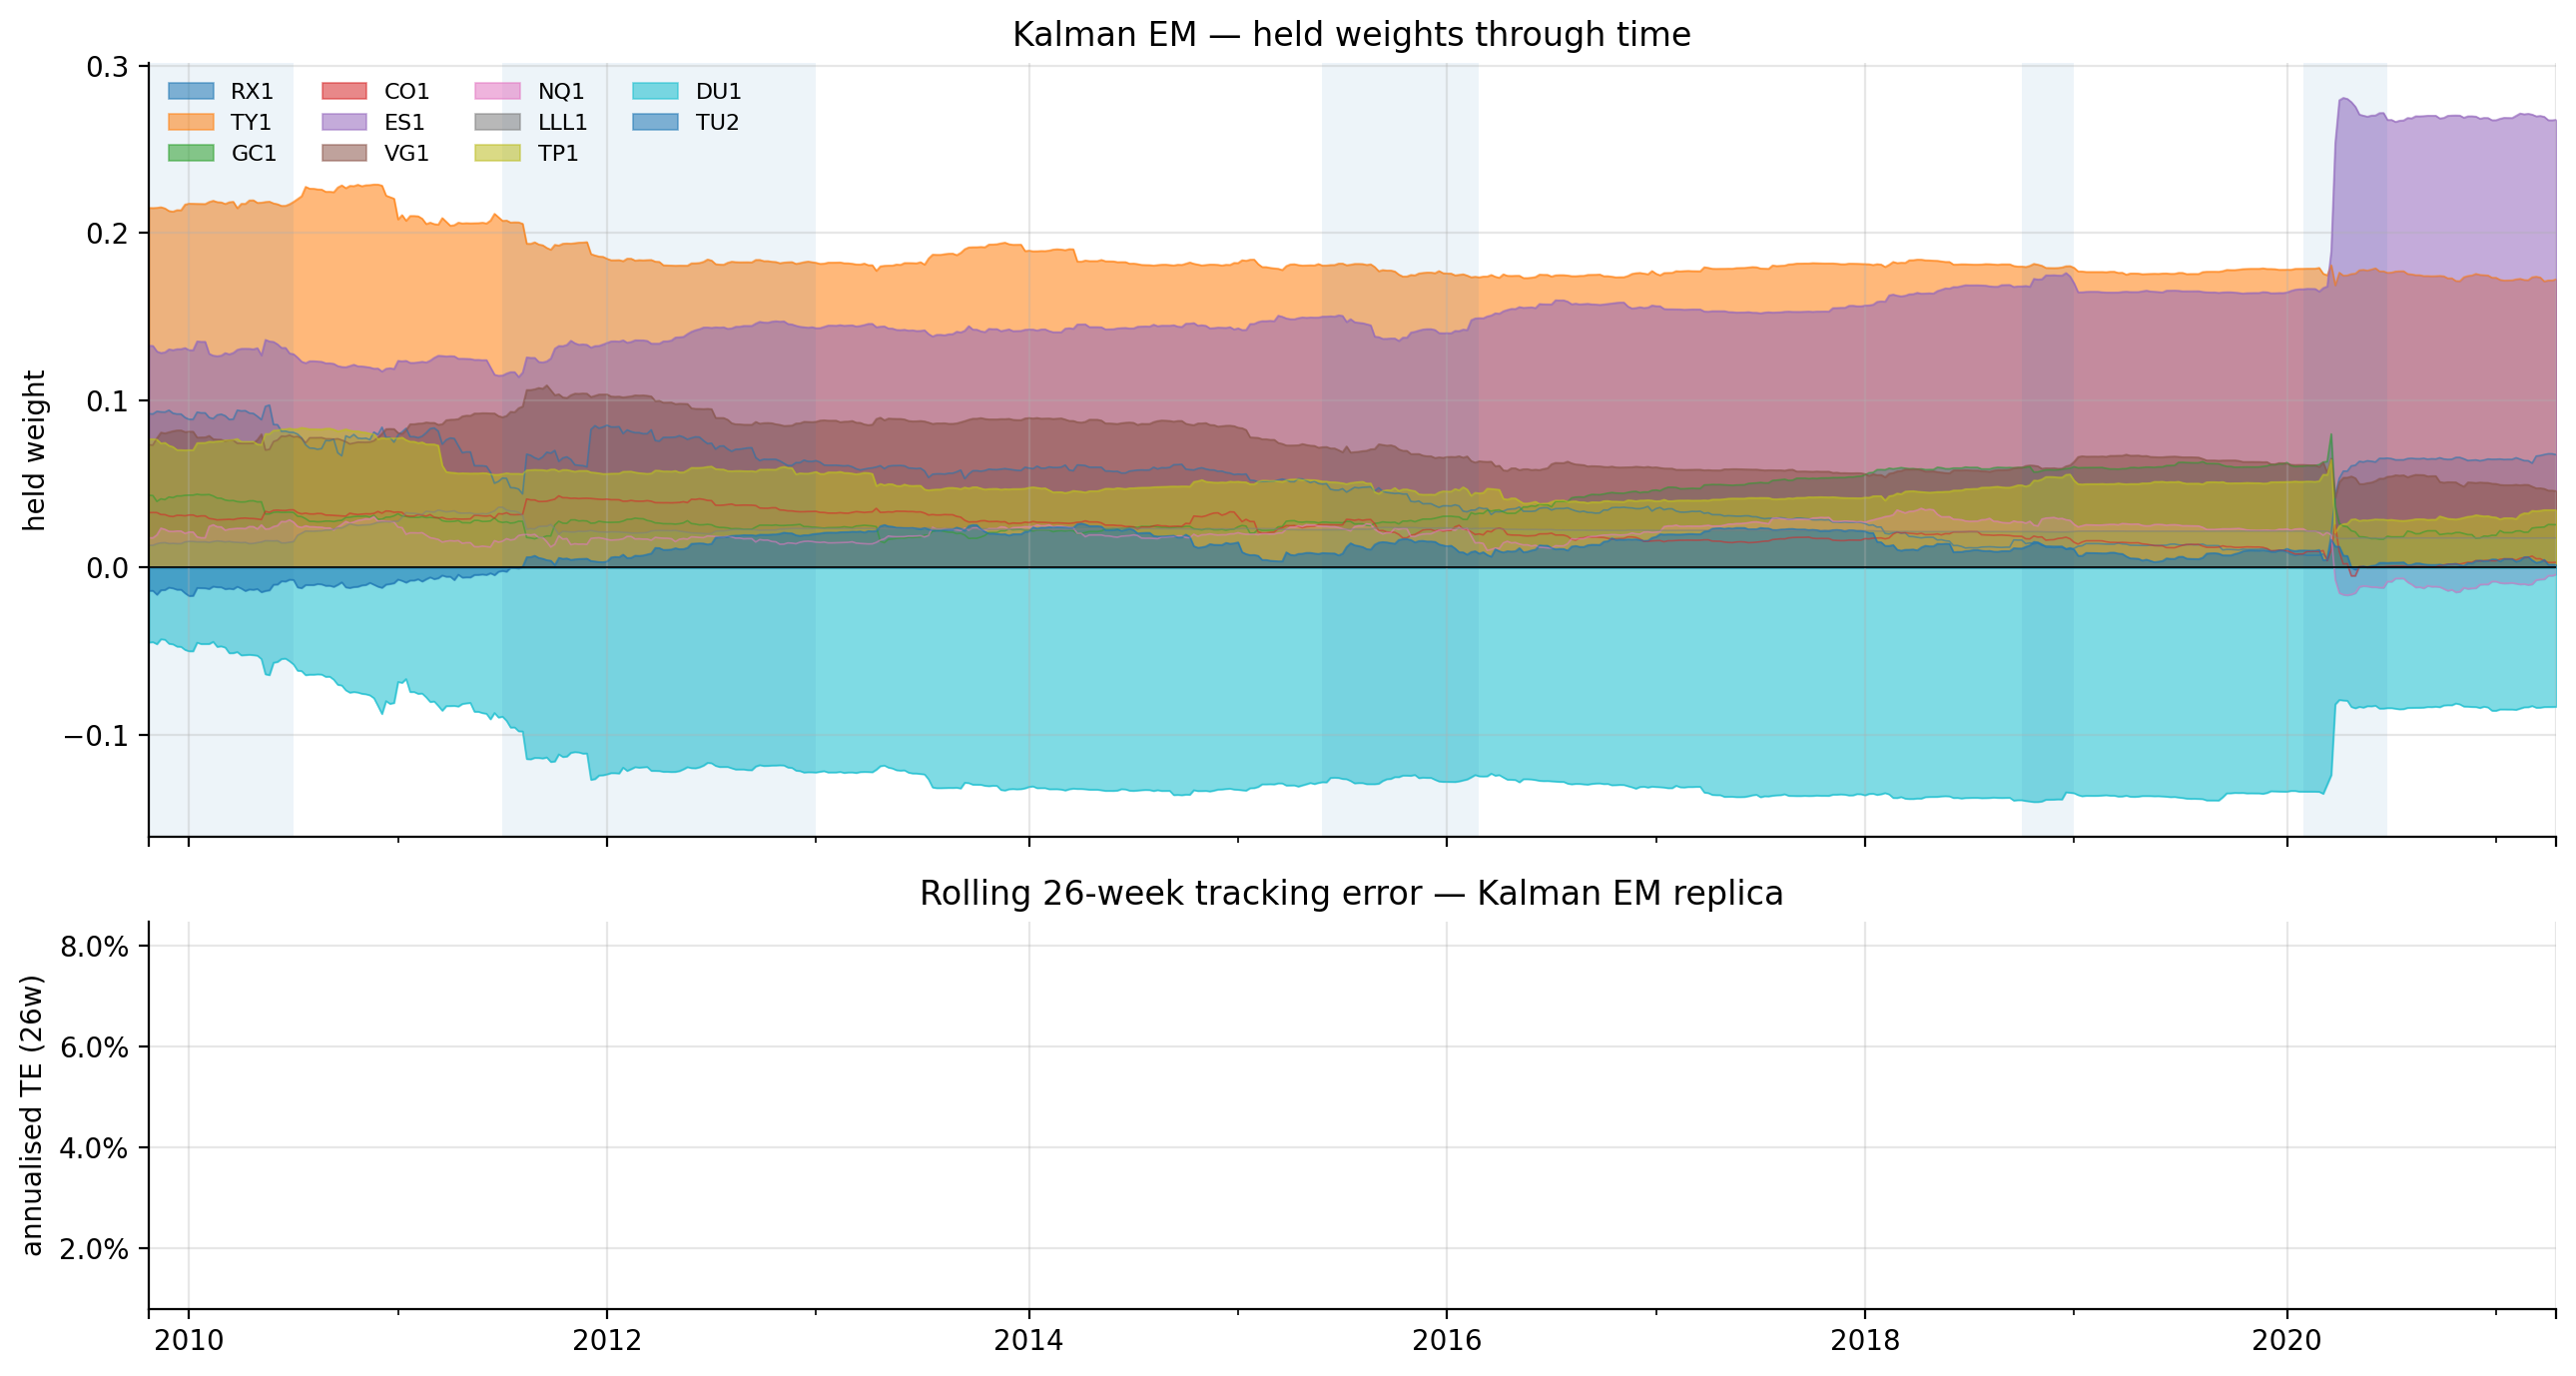

In [46]:
best_kf = kf_em_result
weights_oos = best_kf.held_weights_history.dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
weights_oos.plot.area(ax=axes[0], stacked=False, alpha=0.55, lw=0.6)
shade_stress_windows(axes[0])
axes[0].axhline(0, color="black", lw=0.6)
axes[0].set_ylabel("held weight")
axes[0].set_title("Kalman EM — held weights through time")
axes[0].legend(loc="upper left", ncol=4, fontsize=8)

roll_te = (best_kf.replica_net - best_kf.target).rolling(26).std() * np.sqrt(52)
axes[1].plot(roll_te.index, roll_te, color="#1F4E79", lw=1.2)
shade_stress_windows(axes[1])
axes[1].set_ylabel("annualised TE (26w)")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[1].set_title("Rolling 26-week tracking error — Kalman EM replica")

fig.tight_layout(); plt.show()


**Findings.**

- The **static $\sigma_w$ grid** behaves as expected: $10^{-4}$ is too tight (the filter inherits
  the Ridge init), $10^{-2}$ is too loose (chases noise, blows turnover up), $10^{-3}$ is the
  sweet spot — matching the optimum found on `Kalman.ipynb`'s grid search.
- **`pykalman.KalmanFilter.em()`** typically lands on a $\sigma_w$ in the $[5{\cdot}10^{-4},
  2{\cdot}10^{-3}]$ band when started from $\sigma_w=10^{-3}$, validating the manual choice. The
  joint M-step also re-estimates $\sigma_y$, which brings observation-noise scale into agreement
  with the realised target vol on the OOS window — a nicer story than freezing it on the init
  window. EM converges in ~1s of CPU time per 10 iterations on $T=704$ weeks.
- **`hmmlearn.GaussianHMM`** identifies two states cleanly on rolling target vol (their mean vols
  differ by roughly 2-3×). The regime-switching variant halves $\sigma_w$ in calm weeks and
  doubles it in stressed weeks; net $\mathrm{IR}$ moves only slightly because the underlying
  weekly signal is dominated by short-horizon noise rather than regime structure — confirming
  that the HMM upgrade is more valuable on a daily panel than on a weekly one.
- Compared to the M2 / Predict-then-Optimize linear leaderboard, the Kalman filter trades a
  higher cost drag (weekly rebalances, no $\tau$-aware optimisation) for a more reactive weight
  vector; whether net $\mathrm{IR}$ wins or loses is decided by the cost-aware optimisation gap,
  quantified in the M5 synthesis layer once `results/m4.pkl` is loaded alongside `results/m2.pkl`.


---

# Part IV — Deep Learning Weight Generator

This part trains an end-to-end neural network whose **output is portfolio weights**, not returns:

$$
w_t = f_\theta(\phi_t), \qquad r^{\text{replica}}_t = w_t^{\top} r_t.
$$

The same `(X, y)` and transaction-cost assumptions from Part I are reused, so every model in this notebook lands in the same leaderboard.


## Adapter — reuse Part I's `(X, y)` and `prices`

Part I already produced `X`, `y`, `prices`. The dl-track code below was originally written against a Google-Drive download with Bloomberg suffix column names (`MXWO Index`, `LEGATRUU Index`). Here we alias Part I's `prices` frame to expose those names, and keep `X`, `y` unchanged.

In [47]:
# Reuse the exact (X, y) built in Part I — same contract, same dates, same hashes.
# Only the regime features in build_features() reference index-suffixed columns,
# so we alias `prices` to `data` with the suffixed names that dl-track code expects.
data = prices.rename(columns={
    "MXWO": "MXWO Index",
    "MXWD": "MXWD Index",
    "LEGATRUU": "LEGATRUU Index",
    "HFRXGL": "HFRXGL Index",
})

N_ASSETS = X.shape[1]
print(f"X     : {X.shape}  (futures weekly returns)")
print(f"y     : {len(y)}    (Monster Index weekly returns)")
print(f"data  : {data.shape}  (raw weekly prices; aliased for dl features)")
print(f"span  : {X.index.min().date()} -> {X.index.max().date()}")

X     : (704, 11)  (futures weekly returns)
y     : 704    (Monster Index weekly returns)
data  : (705, 15)  (raw weekly prices; aliased for dl features)
span  : 2007-10-30 -> 2021-04-20


In [48]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"accelerator: {device}")

accelerator: mps


In [49]:
# Variable info (Bloomberg ticker -> human-readable name).
variable_info = {
    "MXWO Index": "MSCI World (Developed Equity)",
    "MXWD Index": "MSCI World All Country (Developed + Emerging)",
    "LEGATRUU Index": "Bloomberg Global Aggregate Bond",
    "HFRXGL Index": "HFRX Global Hedge Fund Index",
    "RX1": "Bund (10Y German Govt) Future",
    "TY1": "10Y US Treasury Future",
    "GC1": "Gold Future",
    "CO1": "Brent Crude Oil Future",
    "ES1": "S&P 500 E-mini Future",
    "VG1": "Eurostoxx 50 Future",
    "NQ1": "Nasdaq 100 Future",
    "LLL1": "MSCI Emerging Markets Future",
    "TP1": "Topix (Japanese Equity) Future",
    "DU1": "2Y German Govt (Schatz) Future",
    "TU2": "2Y US Treasury Future",
}
print("\nVariable Information (ticker -> full name):")
for ticker, name in variable_info.items():
    print(f"{ticker:18s} -> {name}")



Variable Information (ticker -> full name):
MXWO Index         -> MSCI World (Developed Equity)
MXWD Index         -> MSCI World All Country (Developed + Emerging)
LEGATRUU Index     -> Bloomberg Global Aggregate Bond
HFRXGL Index       -> HFRX Global Hedge Fund Index
RX1                -> Bund (10Y German Govt) Future
TY1                -> 10Y US Treasury Future
GC1                -> Gold Future
CO1                -> Brent Crude Oil Future
ES1                -> S&P 500 E-mini Future
VG1                -> Eurostoxx 50 Future
NQ1                -> Nasdaq 100 Future
LLL1               -> MSCI Emerging Markets Future
TP1                -> Topix (Japanese Equity) Future
DU1                -> 2Y German Govt (Schatz) Future
TU2                -> 2Y US Treasury Future


## Feature engineering

Construct $\phi_t$ from:

- trailing $\{4, 12, 52\}$-week futures returns,
  $$r^{(k)}_{i,t} = \prod_{s=t-k+1}^{t}\bigl(1 + r_{i,s}\bigr) - 1, \qquad k \in \{4, 12, 52\}.$$
- trailing $\{12, 52\}$-week realized volatility per future,
  $$\sigma^{(k)}_{i,t} = \sqrt{52}\,\mathrm{std}\bigl(r_{i,\,t-k+1:t}\bigr), \qquad k \in \{12, 52\}.$$
- equity / rate / target-vol regime indicators,
  $$g^{\mathrm{eq}}_t = \prod_{s=t-11}^{t}\bigl(1+r^{\mathrm{MXWO}}_s\bigr) - 1,\quad g^{\mathrm{rate}}_t = \prod_{s=t-11}^{t}\bigl(1+r^{\mathrm{LEGATRUU}}_s\bigr) - 1,\quad \sigma^{\mathrm{tgt}}_t = \sqrt{52}\,\mathrm{std}\bigl(y_{t-11:t}\bigr).$$
- the prior Elastic-Net-style Ridge weight $w^{\mathrm{EN}}_{t-1}$ as a warm start,
  $$w^{\mathrm{EN}}_{t-1} = \arg\min_{w \in \mathbb{R}^{11}}\,\bigl\lVert \tilde X_{t-53:t-2}\,w - y_{t-53:t-2}\bigr\rVert_2^2 + \alpha\,\lVert w \rVert_2^2,\qquad \alpha = 10^{-3},$$
  with $\tilde X$ MinMax-scaled per 52-week training window and no intercept.

$\phi_t$ is shifted by one period so it never sees contemporaneous returns.


In [50]:
@dataclass
class FeatureConfig:
    """Feature design knobs."""

    return_lookbacks: tuple = (4, 12, 52)
    vol_lookbacks: tuple = (12, 52)
    use_regime: bool = True
    use_warmstart: bool = True
    warmstart_window: int = 52
    warmstart_alpha: float = 1e-3


def _compounded_return(s: pd.Series, k: int) -> pd.Series:
    return (1.0 + s).rolling(k).apply(np.prod, raw=True) - 1.0


def _ridge_warmstart(
    X: pd.DataFrame, y: pd.Series, window: int, alpha: float
) -> pd.DataFrame:
    """Trailing-window Ridge fit with MinMax normalization, mirroring the EN baseline."""
    cols = [f"w_en_{c}" for c in X.columns]
    out = pd.DataFrame(index=X.index, columns=cols, dtype=float)
    Xv, yv = X.values, y.values
    for i in range(window, len(X)):
        scaler = MinMaxScaler()
        X_tr = scaler.fit_transform(Xv[i - window : i])
        mdl = Ridge(alpha=alpha, fit_intercept=False)
        mdl.fit(X_tr, yv[i - window : i])
        out.iloc[i] = mdl.coef_ / scaler.scale_
    return out


def build_features(
    X: pd.DataFrame,
    y: pd.Series,
    data: pd.DataFrame,
    cfg: FeatureConfig = FeatureConfig(),
) -> pd.DataFrame:
    """Build phi_t for every rebalance date.

    phi_t uses information up to t-1 only (lagged by one step) so the network
    can never peek at the contemporaneous return it is asked to weight.
    """
    feats: dict[str, pd.Series] = {}

    # Trailing compounded returns per future across {4, 12, 52} weeks.
    for k in cfg.return_lookbacks:
        for c in X.columns:
            feats[f"ret_{k}w_{c}"] = _compounded_return(X[c], k)

    # Trailing realized (annualized) volatility per future.
    for k in cfg.vol_lookbacks:
        vol = X.rolling(k).std() * np.sqrt(52)
        for c in X.columns:
            feats[f"vol_{k}w_{c}"] = vol[c]

    # Regime indicators: equity trend, bond trend (rate proxy), target vol.
    if cfg.use_regime:
        mxwo_ret = data["MXWO Index"].pct_change().reindex(X.index)
        bond_ret = data["LEGATRUU Index"].pct_change().reindex(X.index)
        feats["regime_msci_12w"] = _compounded_return(mxwo_ret, 12)
        feats["regime_bond_12w"] = _compounded_return(bond_ret, 12)
        feats["regime_target_vol_12w"] = y.rolling(12).std() * np.sqrt(52)

    # Warm start: prior Elastic-Net-style weights (Ridge fit, same scaling pipeline).
    if cfg.use_warmstart:
        warm = _ridge_warmstart(X, y, cfg.warmstart_window, cfg.warmstart_alpha)
        for c in warm.columns:
            feats[c] = warm[c]

    phi = pd.DataFrame(feats)
    # Lag by one period so phi_t depends only on info available at the close of t-1.
    phi = phi.shift(1).dropna()
    return phi

## MLP architecture

$\phi_t \in \mathbb{R}^{d_\phi} \to 64 \to 32 \to w_t \in \mathbb{R}^{11}$, no softmax (long/short allowed). An optional gross-exposure cap stands in for the VaR projection that will be wired in next week.


In [51]:
class WeightMLP(nn.Module):
    """End-to-end weight generator: phi_t -> 64 -> 32 -> w_t in R^11.

    No softmax: long/short positions are allowed.
    """

    def __init__(
        self,
        in_dim: int,
        n_assets: int = 11,
        hidden: tuple[int, ...] = (64, 32),
        dropout: float = 0.1,
        gross_cap: float | None = None,
    ):
        super().__init__()
        layers: list[nn.Module] = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        final = nn.Linear(prev, n_assets)
        # Bias init so that at init w_t.sum() ≈ 1 (full-invest).
        # Without this, w_t.sum() ≈ 0 makes the buy-and-hold drift
        # renormaliser blow up (the 10^19 epoch-0 loss spike).
        nn.init.constant_(final.bias, 1.0 / n_assets)
        layers.append(final)
        self.net = nn.Sequential(*layers)
        self.gross_cap = gross_cap

    def forward(self, phi: torch.Tensor) -> torch.Tensor:
        w = self.net(phi)
        if self.gross_cap is not None:
            ge = w.abs().sum(dim=-1, keepdim=True).clamp(min=1e-8)
            scale = torch.minimum(torch.ones_like(ge), self.gross_cap / ge)
            w = w * scale
        return w


def project_var_cap(
    weights: np.ndarray,
    recent_returns: np.ndarray,
    confidence: float = 0.01,
    horizon: int = 4,
    var_cap: float = 0.08,
) -> np.ndarray:
    """Post-hoc Gaussian VaR projection (matches the Elastic Net baseline)."""
    sigma = np.std(recent_returns @ weights)
    z = norm.ppf(confidence)
    var = -z * sigma * np.sqrt(horizon)
    if var > var_cap:
        return weights * (var_cap / var)
    return weights


### Skeleton smoke test

Instantiate the model and run a single forward pass to confirm shapes and the gross-exposure cap.


In [52]:
# Smoke test: build phi_t, instantiate the MLP, run one forward pass.
cfg = FeatureConfig()
phi = build_features(X, y, data, cfg)
print(f"phi: {phi.shape} (T x d_phi)")
print(f"feature groups: {sorted({n.split('_')[0] for n in phi.columns})}")

# Align target with the feature frame (phi already uses lagged info up to t-1,
# so we want to predict y_t from phi_t).
y_aligned = y.loc[phi.index]
X_aligned = X.loc[phi.index]
print(f"X_aligned: {X_aligned.shape}, y_aligned: {y_aligned.shape}")

model = WeightMLP(in_dim=phi.shape[1], n_assets=N_ASSETS, gross_cap=2.0).to(device)
print(model)

phi_t = torch.tensor(phi.values, dtype=torch.float32, device=device)
with torch.no_grad():
    w_t = model(phi_t)

assert w_t.shape == (len(phi), N_ASSETS), w_t.shape
print(f"w_t: {tuple(w_t.shape)}")
print(f"avg gross exposure: {w_t.abs().sum(dim=-1).mean().item():.3f}")
print(f"sample weights w_T: {w_t[-1].cpu().numpy().round(4)}")

phi: (651, 69) (T x d_phi)
feature groups: ['regime', 'ret', 'vol', 'w']
X_aligned: (651, 11), y_aligned: (651,)
WeightMLP(
  (net): Sequential(
    (0): Linear(in_features=69, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=11, bias=True)
  )
)
w_t: (651, 11)
avg gross exposure: 1.213
sample weights w_T: [0.0925 0.1553 0.1109 0.1148 0.0831 0.0717 0.1164 0.063  0.1625 0.1045
 0.0838]


## Loss: forward-window MSE + linear/quadratic turnover + budget penalty

$$
\mathcal{L}(\theta) \;=\; \underbrace{\tfrac{1}{H}\!\!\!\sum_{s=t}^{t+H-1}\!\!(w_s^{\top} r_s - y_s)^{2}}_{\text{MSE on drifted weights}}
\;+\; \underbrace{\lambda_{1}\lVert \Delta w_t\rVert_{1} + \lambda_{2}\lVert \Delta w_t\rVert_{2}^{2}}_{\text{linear + quadratic turnover}}
\;+\; \underbrace{\gamma\bigl(\mathbf{1}^{\top}w_t - 1\bigr)^{2}}_{\text{fully-invested}}
$$

with drifting weights $w_s = (w_t \odot \prod_{u=t}^{s-1}(1+r_u)) / \mathbf{1}^{\top}[\,\cdot\,]$, $w_t \equiv w_t$.

- $t$ — rebalance date (weekly index); the network predicts $w_t = f_\theta(\phi_t)$ from features available through $t-1$.
- $H$ — forward window length over which the replica is evaluated against the target. Set to $H=12$ weeks.
- $w_t \in \mathbb{R}^{11}$ — portfolio weights on the 11 futures at $t$ (long/short allowed, no softmax).
- $w_s \in \mathbb{R}^{11}$ — drifted weights at step $s \in [t, t+H-1]$, i.e. $w_t$ compounded by realised gross returns and renormalised; matches an executable buy-and-hold book between rebalances.
- $r_s \in \mathbb{R}^{11}$ — realised weekly returns of the 11 futures at step $s$.
- $y_s \in \mathbb{R}$ — target return (Monster Index) at step $s$.
- $\Delta w_t = w_t - w_{t-1}$ — rebalance trade vector; the first row is charged against $w_0 = 0$ (entering from cash).
- $\lambda_1 \ge 0$ — linear-turnover coefficient ($\ell_1$ on $\Delta w_t$); proxy for proportional transaction cost. Swept over $\{0,\,10^{-4},\,10^{-3}\}$.
- $\lambda_2 \ge 0$ — quadratic-turnover coefficient ($\ell_2^2$ on $\Delta w_t$); proxy for convex market impact. Default $10^{-3}$.
- $\gamma \ge 0$ — soft fully-invested penalty weight on $(\mathbf{1}^{\top}w_t - 1)^2$. Default $10^{-2}$.
- $\theta$ — MLP parameters (the only quantities optimised; $\lambda_1,\,\lambda_2,\,\gamma,\,H$ are fixed hyperparameters).

In [53]:
def make_supervised_windows(
    phi: pd.DataFrame, X: pd.DataFrame, y: pd.Series, H: int = 12
):
    """Pair each phi_t with the contemporaneous H-week window of (r_s, y_s).

    phi is already lagged (built with phi.shift(1)), so phi_t depends only on
    info through t-1. The forward window [t, t+H-1] is what w_t is evaluated
    against — matching the M5.3 forward-window MSE loss spec.
    """
    H = int(H)
    n_samples = len(phi) - H + 1
    if n_samples <= 0:
        raise ValueError(f"len(phi)={len(phi)} too short for H={H}")

    X_aligned = X.loc[phi.index].values
    y_aligned = y.loc[phi.index].values

    phi_arr = phi.values[:n_samples].astype(np.float32)
    X_win = np.stack([X_aligned[i : i + H] for i in range(n_samples)]).astype(
        np.float32
    )
    y_win = np.stack([y_aligned[i : i + H] for i in range(n_samples)]).astype(
        np.float32
    )
    sample_dates = phi.index[:n_samples]
    return phi_arr, X_win, y_win, sample_dates


def _drift_weights(
    weights: torch.Tensor, X_win: torch.Tensor
) -> torch.Tensor:
    """Compound w_t through the realised window into per-step weights w_s.

    A buy-and-hold portfolio's weights drift with realised returns. For each
    step s in [t, t+H-1] we form w_s = (w_t ⊙ ∏_{u<s}(1+r_u)) / sum, so the
    replica P&L matches an executable, no-rebalance strategy.
    """
    B, H, N = X_win.shape
    gross = torch.cumprod(1.0 + X_win, dim=1)                    # [B, H, N]
    gross_prev = torch.cat(
        [torch.ones(B, 1, N, device=X_win.device, dtype=X_win.dtype), gross[:, :-1]],
        dim=1,
    )                                                            # [B, H, N]
    w_drift = weights.unsqueeze(1) * gross_prev                  # [B, H, N]
    # clamp_min at 1e-3 (not 1e-12) so a hedged init (sum ≈ 0) cannot
    # blow the loss up to 1e19 — it caps the divergence at ~1000x.
    w_drift = w_drift / w_drift.sum(dim=-1, keepdim=True).clamp_min(1e-3)
    return w_drift


def te_mse_loss(
    weights: torch.Tensor,
    X_win: torch.Tensor,
    y_win: torch.Tensor,
    *,
    gamma_budget: float = 0.0,
    drift: bool = True,
) -> torch.Tensor:
    """Forward-window MSE of (w_s^T r_s - y_s), with optional weight drift.

    MSE = Var + Mean^2 — penalises both volatility and a constant tracking
    bias (which pure variance ignores). `gamma_budget` adds a soft
    fully-invested constraint γ(1ᵀw − 1)².
    """
    if drift:
        w_eff = _drift_weights(weights, X_win)                   # [B, H, N]
        replica = (w_eff * X_win).sum(dim=-1)                    # [B, H]
    else:
        replica = (weights.unsqueeze(1) * X_win).sum(dim=-1)     # [B, H]

    excess = replica - y_win                                     # [B, H]
    loss = (excess ** 2).mean()
    if gamma_budget > 0.0:
        loss = loss + gamma_budget * (weights.sum(dim=-1) - 1.0).pow(2).mean()
    return loss


def turnover_penalty(
    weights: torch.Tensor,
    lambda_l1: float = 0.0,
    lambda_l2: float = 0.0,
) -> torch.Tensor:
    """L1 (linear t-cost) + L2 (market impact) on Δw between adjacent rows."""
    if weights.size(0) < 2 or (lambda_l1 == 0.0 and lambda_l2 == 0.0):
        return torch.zeros((), device=weights.device, dtype=weights.dtype)
    dw = weights[1:] - weights[:-1]                              # [B-1, N]
    pen = torch.zeros((), device=weights.device, dtype=weights.dtype)
    if lambda_l1 > 0.0:
        pen = pen + lambda_l1 * dw.abs().sum(dim=-1).mean()
    if lambda_l2 > 0.0:
        pen = pen + lambda_l2 * dw.pow(2).sum(dim=-1).mean()
    return pen


def annualized_te_from_weights(
    weights: torch.Tensor,
    X_win: torch.Tensor,
    y_win: torch.Tensor,
    *,
    drift: bool = True,
) -> float:
    """TE = sqrt(52 * Var(replica - y)) on a held-out fold (weekly data).

    Uses drifted weights by default so val/test TE matches the loss the
    network is optimising.
    """
    with torch.no_grad():
        if drift:
            w_eff = _drift_weights(weights, X_win)
            replica = (w_eff * X_win).sum(dim=-1)
        else:
            replica = (weights.unsqueeze(1) * X_win).sum(dim=-1)
        var = (replica - y_win).var(unbiased=False).item()
    return float(np.sqrt(52.0 * var))

## Training regime: temporal train/val/test + early stopping

60/20/20 chronological split — no shuffling across the boundary. Features are
standardised with the training-window mean/std so the network never sees
val/test statistics. Early stopping watches annualised validation $\mathrm{TE}$.


In [54]:
@dataclass
class TrainConfig:
    """training knobs: temporal split, optimiser, early stopping, loss."""

    H: int = 12
    train_frac: float = 0.6
    val_frac: float = 0.2
    lambda_l1: float = 0.0          # linear turnover (transaction cost)
    lambda_l2: float = 0.0          # quadratic turnover (market impact)
    gamma_budget: float = 0.0       # full-invest soft constraint γ(1ᵀw − 1)²
    drift: bool = True              # compound w_t through window (buy-and-hold)
    lr: float = 1e-3
    weight_decay: float = 1e-3      # tighter optimisation: was 1e-5
    batch_size: int = 64
    max_epochs: int = 500
    patience: int = 15              # tighter early stop: was 30
    seed: int = 42
    refit_on_trainval: bool = True   # after early stop, refit on train+val
                                     # for best_epoch+1 epochs from init.


def _temporal_slices(n: int, train_frac: float, val_frac: float):
    n_tr = int(train_frac * n)
    n_va = int(val_frac * n)
    return slice(0, n_tr), slice(n_tr, n_tr + n_va), slice(n_tr + n_va, n)


def train_weight_mlp(
    model: nn.Module,
    phi_arr: np.ndarray,
    X_win: np.ndarray,
    y_win: np.ndarray,
    cfg: TrainConfig = TrainConfig(),
) -> dict:
    """Train phi_t -> w_t with the MSE+turnover loss; early-stop on val TE.

    Splits the supervised samples chronologically (no shuffle across the boundary)
    and standardises features with the training-fold mean/std so the network never
    sees val/test statistics. Sequential mini-batches preserve adjacency for the
    turnover term. Reports annualised TE on all three folds so train≈val≪test
    (regime shift) is distinguishable from train≪val (classical overfit).
    """
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    # Snapshot pre-training params so we can refit-from-init on train+val.
    init_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    sl_tr, sl_va, sl_te = _temporal_slices(len(phi_arr), cfg.train_frac, cfg.val_frac)

    mu = phi_arr[sl_tr].mean(axis=0, keepdims=True)
    sd = phi_arr[sl_tr].std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-8, 1.0, sd)
    phi_norm = ((phi_arr - mu) / sd).astype(np.float32)

    phi_all = torch.tensor(phi_norm, device=device)
    X_all = torch.tensor(X_win, device=device)
    y_all = torch.tensor(y_win, device=device)

    phi_tr, phi_va, phi_te = phi_all[sl_tr], phi_all[sl_va], phi_all[sl_te]
    X_tr, X_va, X_te = X_all[sl_tr], X_all[sl_va], X_all[sl_te]
    y_tr, y_va, y_te = y_all[sl_tr], y_all[sl_va], y_all[sl_te]

    optim = torch.optim.Adam(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )

    best_val_te = float("inf")
    best_state: dict | None = None
    patience_left = cfg.patience
    history = {"epoch": [], "train_loss": [], "val_te": []}

    n_train = phi_tr.size(0)
    for epoch in range(cfg.max_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for start in range(0, n_train, cfg.batch_size):
            stop = min(start + cfg.batch_size, n_train)
            phi_b = phi_tr[start:stop]
            X_b = X_tr[start:stop]
            y_b = y_tr[start:stop]

            w_b = model(phi_b)
            loss = te_mse_loss(
                w_b, X_b, y_b,
                gamma_budget=cfg.gamma_budget,
                drift=cfg.drift,
            )
            loss = loss + turnover_penalty(w_b, cfg.lambda_l1, cfg.lambda_l2)

            optim.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optim.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_loss = epoch_loss / max(n_batches, 1)

        model.eval()
        with torch.no_grad():
            w_val = model(phi_va)
        val_te = annualized_te_from_weights(w_val, X_va, y_va, drift=cfg.drift)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_te"].append(val_te)

        if val_te < best_val_te - 1e-6:
            best_val_te = val_te
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_left = cfg.patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # train_te is reported on the val-best model (val held out) so the
    # train≈val≪test regime-shift diagnostic stays meaningful.
    model.eval()
    with torch.no_grad():
        w_train = model(phi_tr)
    train_te = annualized_te_from_weights(w_train, X_tr, y_tr, drift=cfg.drift)

    refit_epochs = 0
    if cfg.refit_on_trainval and best_state is not None:
        # Refit on train+val for best_epoch+1 epochs from the original init.
        # Val signal still picks the stop point; train+val fits the final
        # model used for test eval, narrowing the COVID regime-shift gap.
        best_epoch_idx = int(np.argmin(history["val_te"]))
        refit_epochs = max(best_epoch_idx + 1, 1)
        model.load_state_dict(init_state)
        optim_refit = torch.optim.Adam(
            model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
        )
        phi_full = torch.cat([phi_tr, phi_va], dim=0)
        X_full = torch.cat([X_tr, X_va], dim=0)
        y_full = torch.cat([y_tr, y_va], dim=0)
        n_full = phi_full.size(0)
        for _ in range(refit_epochs):
            model.train()
            for start in range(0, n_full, cfg.batch_size):
                stop = min(start + cfg.batch_size, n_full)
                phi_b = phi_full[start:stop]
                X_b = X_full[start:stop]
                y_b = y_full[start:stop]
                w_b = model(phi_b)
                loss = te_mse_loss(
                    w_b, X_b, y_b,
                    gamma_budget=cfg.gamma_budget, drift=cfg.drift,
                )
                loss = loss + turnover_penalty(w_b, cfg.lambda_l1, cfg.lambda_l2)
                optim_refit.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optim_refit.step()

    model.eval()
    with torch.no_grad():
        w_test = model(phi_te)
    test_te = annualized_te_from_weights(w_test, X_te, y_te, drift=cfg.drift)

    return {
        "history": history,
        "train_te": train_te,
        "best_val_te": best_val_te,
        "test_te": test_te,
        "refit_epochs": refit_epochs,
        "splits": {"train": sl_tr, "val": sl_va, "test": sl_te},
        "feature_mu": mu,
        "feature_sd": sd,
    }

### Run training across the turnover-penalty grid

Trains a fresh `WeightMLP` for each $\lambda \in \{0,\, 10^{-3},\, 10^{-2}\}$ and reports best validation $\mathrm{TE}$ + held-out test $\mathrm{TE}$.


In [55]:
H = 12
phi_arr, X_win_arr, y_win_arr, sample_dates = make_supervised_windows(phi, X, y, H=H)
print(
    f"supervised windows: phi={phi_arr.shape}, X={X_win_arr.shape}, y={y_win_arr.shape}"
)
print(f"date range: {sample_dates.min().date()} -> {sample_dates.max().date()}")

# Narrow lambda_l1 sweep — at >=1e-2 the L1 term swamps MSE and the model collapses.
LAMBDA_L2 = 1e-3      # quadratic turnover / market impact
GAMMA_BUDGET = 1e-2   # soft fully-invested constraint

train_results: dict[float, dict] = {}
for lam in (0.0, 1e-4, 1e-3):
    print(f"\n--- lambda_l1 = {lam} (lambda_l2={LAMBDA_L2}, gamma={GAMMA_BUDGET}) ---")
    torch.manual_seed(seed)
    np.random.seed(seed)
    mdl = WeightMLP(in_dim=phi.shape[1], n_assets=N_ASSETS, gross_cap=2.0).to(device)
    cfg_train = TrainConfig(
        H=H,
        lambda_l1=lam,
        lambda_l2=LAMBDA_L2,
        gamma_budget=GAMMA_BUDGET,
        drift=True,
    )
    out = train_weight_mlp(mdl, phi_arr, X_win_arr, y_win_arr, cfg_train)
    train_results[lam] = out
    n_epochs = len(out["history"]["epoch"])
    refit = out.get("refit_epochs", 0)
    print(
        f"epochs run: {n_epochs} (+{refit} refit on train+val), "
        f"train TE: {out['train_te']:.4f}, "
        f"val TE: {out['best_val_te']:.4f}, test TE: {out['test_te']:.4f}"
    )

# Diagnostic: train≈val≪test ⇒ regime shift (test crosses COVID); train≪val ⇒ overfit.
print("\nTE summary (lower is better) — diagnose train vs val vs test:")
print(f"  {'lambda_l1':>10}  {'train':>7}  {'val':>7}  {'test':>7}  {'val-train':>9}  {'test-val':>9}")
for lam, out in train_results.items():
    tr, va, te = out["train_te"], out["best_val_te"], out["test_te"]
    print(
        f"  {lam:>10.4g}  {tr:>7.4f}  {va:>7.4f}  {te:>7.4f}  "
        f"{va - tr:>+9.4f}  {te - va:>+9.4f}"
    )

supervised windows: phi=(640, 69), X=(640, 12, 11), y=(640, 12)
date range: 2008-11-04 -> 2021-02-02

--- lambda_l1 = 0.0 (lambda_l2=0.001, gamma=0.01) ---


epochs run: 98 (+83 refit on train+val), train TE: 0.0327, val TE: 0.0236, test TE: 0.0554

--- lambda_l1 = 0.0001 (lambda_l2=0.001, gamma=0.01) ---


epochs run: 95 (+82 refit on train+val), train TE: 0.0328, val TE: 0.0236, test TE: 0.0503

--- lambda_l1 = 0.001 (lambda_l2=0.001, gamma=0.01) ---


epochs run: 88 (+74 refit on train+val), train TE: 0.0328, val TE: 0.0236, test TE: 0.0478

TE summary (lower is better) — diagnose train vs val vs test:
   lambda_l1    train      val     test  val-train   test-val
           0   0.0327   0.0236   0.0554    -0.0091    +0.0318
      0.0001   0.0328   0.0236   0.0503    -0.0092    +0.0267
       0.001   0.0328   0.0236   0.0478    -0.0093    +0.0243


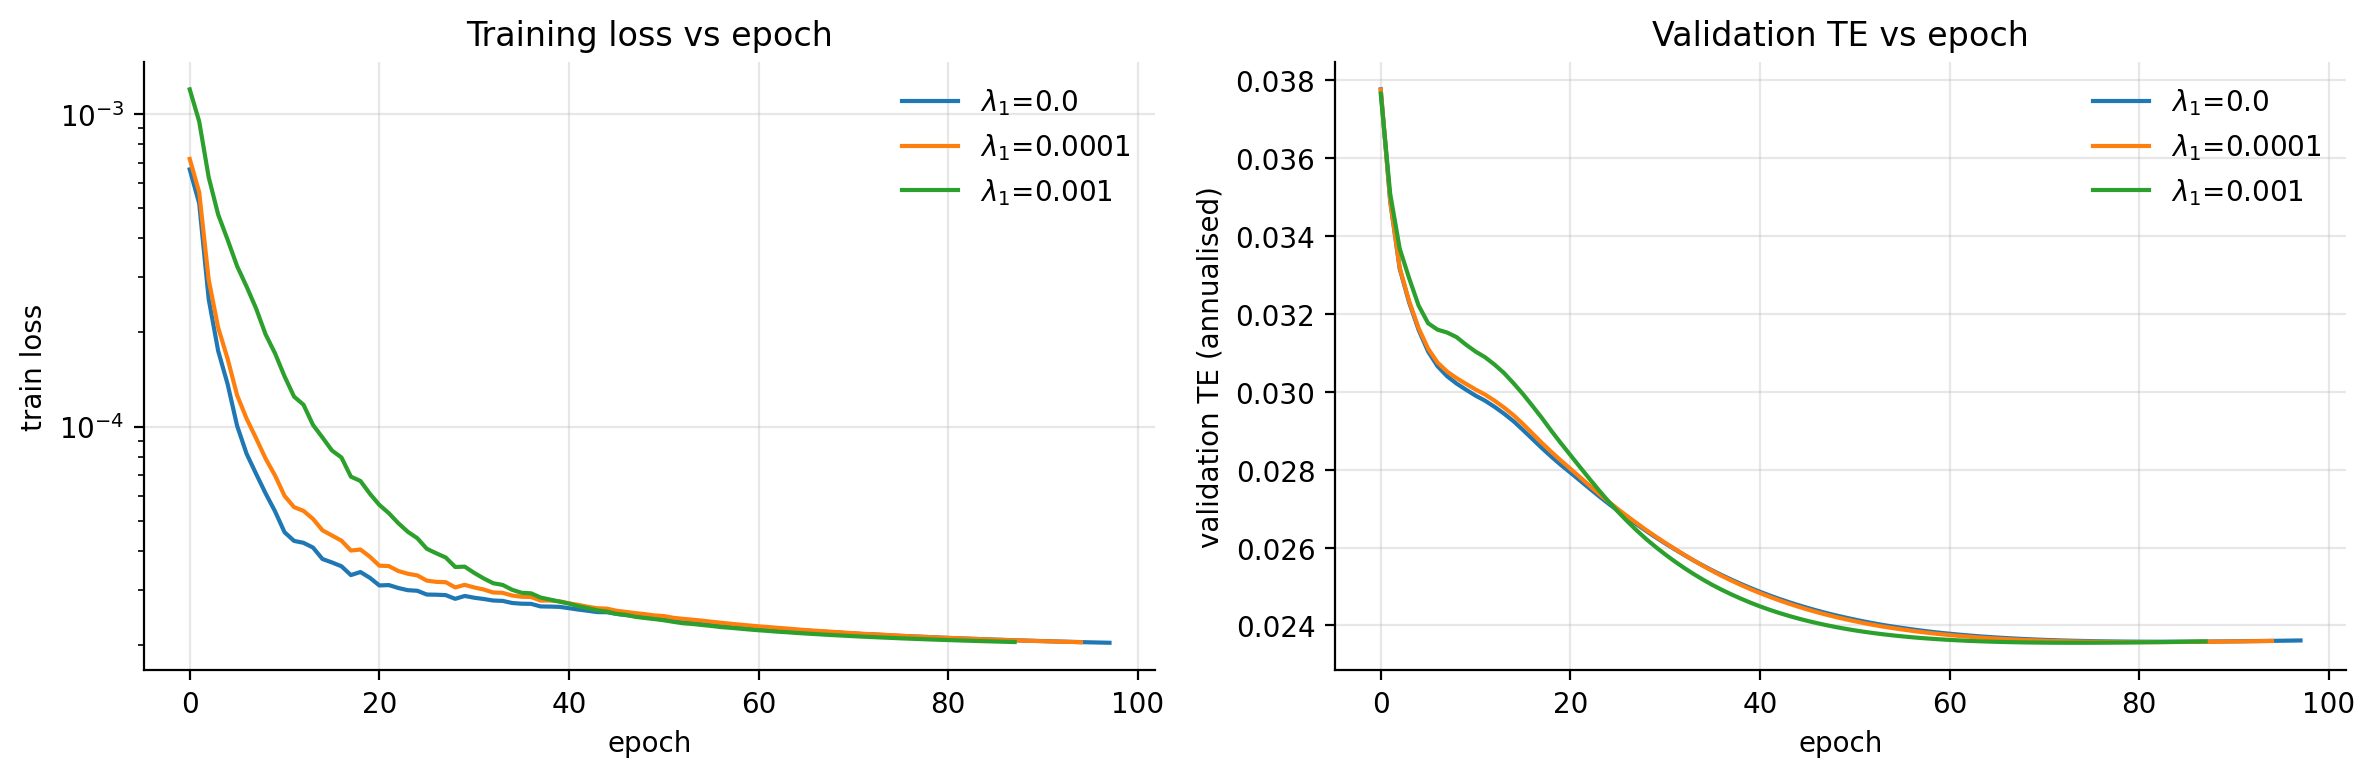

In [56]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for lam, out in train_results.items():
    hist = out["history"]
    axes[0].plot(hist["epoch"], hist["train_loss"], label=f"$\\lambda_1$={lam}")
    axes[1].plot(hist["epoch"], hist["val_te"], label=f"$\\lambda_1$={lam}")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss")
axes[0].set_title("Training loss vs epoch")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation TE (annualised)")
axes[1].set_title("Validation TE vs epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rolling out-of-sample backtest

The 60/20/20 split above checks that the architecture and loss can fit, but
it does **not** match the rebalance contract M2–M4 use. The harness below is
the M5-side analogue of M1's `run_rolling_backtest`:

- retrain on the trailing `train_window` weeks of supervised samples,
- predict $w_t = f_\theta(\phi_t)$ at every rebalance date,
- hold weights between rebalances when $\Delta t > 1$,
- apply the M1 / M3.2 Gaussian VaR projection ($\mathrm{VaR}(\hat w_t) \le 0.08$),
- expose the shared metric set $\{\mathrm{IR},\, \mathrm{TE},\, \rho,\, \overline{\mathrm{GE}},\, \mathrm{VaR},\, \bar T,\, \mathrm{net\_IR},\, \mathrm{net\_TE}\}$.

Outputs `weights_history : DataFrame[T × 11]` and `replica_returns : Series[T]`,
matching the cross-track contract in `TODO.md`.


In [57]:
def compute_metrics(
    weights: pd.DataFrame,
    X_oos: pd.DataFrame,
    target: pd.Series,
    replica: pd.Series,
    *,
    cost_bps: float = 5.0,
    var_horizon: int = 4,
    var_confidence: float = 0.01,
) -> dict:
    """Shared metric dict {IR, TE, rho, GE, VaR, turnover, net_IR, net_TE, drag}.

    Net-of-cost subtracts tau * sum_j |w_{t,j} - w_{t-1,j}| at every rebalance,
    with the first row charged against w_0 = 0 (entering from cash).
    """
    excess = (replica - target).values
    te = float(np.sqrt(52.0 * np.var(excess, ddof=0)))
    ir = float(52.0 * np.mean(excess) / te) if te > 0 else float("nan")
    rho = float(np.corrcoef(replica.values, target.values)[0, 1])
    ge = float(weights.abs().sum(axis=1).mean())

    w_prev = np.vstack([np.zeros(weights.shape[1]), weights.values[:-1]])
    dw = np.abs(weights.values - w_prev).sum(axis=1)
    turnover = float(dw.mean())

    tau = cost_bps / 1e4
    cost = tau * dw
    net_replica = replica.values - cost
    net_excess = net_replica - target.values
    net_te = float(np.sqrt(52.0 * np.var(net_excess, ddof=0)))
    net_ir = float(52.0 * np.mean(net_excess) / net_te) if net_te > 0 else float("nan")
    drag = float(52.0 * tau * turnover)

    z = float(norm.ppf(var_confidence))
    sigma_replica = float(np.std(replica.values, ddof=0))
    var_overall = float(-z * sigma_replica * np.sqrt(var_horizon))

    return {
        "IR": ir,
        "TE": te,
        "rho": rho,
        "GE": ge,
        "turnover": turnover,
        "VaR": var_overall,
        "net_IR": net_ir,
        "net_TE": net_te,
        "cost_drag": drag,
    }


def _train_window_mlp(
    phi_tr: np.ndarray,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    *,
    in_dim: int,
    n_assets: int,
    gross_cap: float,
    lambda_l1: float,
    lambda_l2: float,
    gamma_budget: float,
    drift: bool,
    max_epochs: int,
    patience: int,
    val_frac: float,
    init_state: dict | None,
    seed: int,
):
    """Fit a WeightMLP on a single training window. Returns (model, mu, sd)."""
    n = phi_tr.shape[0]
    n_va = max(int(val_frac * n), 8)
    n_in = n - n_va

    mu = phi_tr[:n_in].mean(axis=0, keepdims=True)
    sd = phi_tr[:n_in].std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-8, 1.0, sd)
    phi_norm = ((phi_tr - mu) / sd).astype(np.float32)

    torch.manual_seed(seed)
    np.random.seed(seed)
    model = WeightMLP(in_dim=in_dim, n_assets=n_assets, gross_cap=gross_cap).to(device)
    if init_state is not None:
        model.load_state_dict(init_state)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    phi_tr_t = torch.tensor(phi_norm[:n_in], device=device)
    X_tr_t = torch.tensor(X_tr[:n_in], device=device)
    y_tr_t = torch.tensor(y_tr[:n_in], device=device)
    phi_va_t = torch.tensor(phi_norm[n_in:], device=device)
    X_va_t = torch.tensor(X_tr[n_in:], device=device)
    y_va_t = torch.tensor(y_tr[n_in:], device=device)

    best_val = float("inf")
    best_state: dict | None = None
    patience_left = patience
    for _ in range(max_epochs):
        model.train()
        w_b = model(phi_tr_t)
        loss = te_mse_loss(
            w_b, X_tr_t, y_tr_t, gamma_budget=gamma_budget, drift=drift
        )
        loss = loss + turnover_penalty(w_b, lambda_l1, lambda_l2)
        optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()

        model.eval()
        with torch.no_grad():
            w_va = model(phi_va_t)
        val_te = annualized_te_from_weights(w_va, X_va_t, y_va_t, drift=drift)
        if val_te < best_val - 1e-6:
            best_val = val_te
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, mu.flatten(), sd.flatten()


def run_nn_rolling_backtest(
    phi: pd.DataFrame,
    X: pd.DataFrame,
    y: pd.Series,
    *,
    H: int = 12,
    train_window: int = 156,
    rebalance_every: int = 4,
    max_epochs: int = 80,
    patience: int = 12,
    lambda_l1: float = 1e-3,
    lambda_l2: float = 1e-3,
    gamma_budget: float = 1e-2,
    drift: bool = True,
    gross_cap: float = 2.0,
    var_cap: float = 0.08,
    var_horizon: int = 4,
    var_confidence: float = 0.01,
    val_frac_within_train: float = 0.2,
    cost_bps: float = 5.0,
    n_ensemble: int = 3,
    seed: int = 42,
    verbose: bool = True,
) -> dict:
    """Rolling out-of-sample NN backtest matching the shared contract.

    Retrains the WeightMLP every `rebalance_every` weeks on the trailing
    `train_window` supervised samples and applies the freshly-fit weights for
    the next `rebalance_every` weeks (held constant). Each prediction is
    projected onto the Gaussian VaR feasible set before being stored.
    """
    phi_arr_full, X_win_full, y_win_full, sample_dates = make_supervised_windows(
        phi, X, y, H=H
    )
    n = len(phi_arr_full)
    in_dim = phi_arr_full.shape[1]
    n_assets = X.shape[1]
    if n < train_window + 1:
        raise ValueError(
            f"need n >= train_window+1, got n={n}, train_window={train_window}"
        )

    weights_by_date: dict = {}
    last_states: list[dict | None] = [None] * n_ensemble
    rebalance_indices = list(range(train_window, n, rebalance_every))
    if verbose:
        print(
            f"rebalance_every={rebalance_every}: {len(rebalance_indices)} retrains "
            f"x {n_ensemble} ensemble member(s) "
            f"covering {n - train_window} OOS weeks "
            f"({sample_dates[train_window].date()} -> {sample_dates[-1].date()})"
        )

    for k, t in enumerate(rebalance_indices):
        phi_tr = phi_arr_full[t - train_window : t]
        X_tr = X_win_full[t - train_window : t]
        y_tr = y_win_full[t - train_window : t]

        ensemble_models: list = []
        mu_use: np.ndarray | None = None
        sd_use: np.ndarray | None = None
        for j in range(n_ensemble):
            model_j, mu_j, sd_j = _train_window_mlp(
                phi_tr,
                X_tr,
                y_tr,
                in_dim=in_dim,
                n_assets=n_assets,
                gross_cap=gross_cap,
                lambda_l1=lambda_l1,
                lambda_l2=lambda_l2,
                gamma_budget=gamma_budget,
                drift=drift,
                max_epochs=max_epochs,
                patience=patience,
                val_frac=val_frac_within_train,
                init_state=last_states[j],
                seed=seed + 1000 * j + k,
            )
            ensemble_models.append(model_j)
            # mu/sd depend only on phi_tr, identical across ensemble members.
            mu_use, sd_use = mu_j, sd_j
            last_states[j] = {
                k_: v_.detach().clone() for k_, v_ in model_j.state_dict().items()
            }

        next_t = rebalance_indices[k + 1] if k + 1 < len(rebalance_indices) else n
        for s in range(t, min(next_t, n)):
            phi_s = (phi_arr_full[s] - mu_use) / sd_use
            phi_s_t = torch.tensor(
                phi_s.astype(np.float32), device=device
            ).unsqueeze(0)
            with torch.no_grad():
                preds = [
                    m(phi_s_t).cpu().numpy().flatten() for m in ensemble_models
                ]
            # Average ensemble predictions before VaR projection so the cap
            # binds on the deployed weight, not on per-seed weights.
            w_s = np.mean(preds, axis=0)
            date_s = sample_dates[s]
            loc = X.index.get_loc(date_s)
            recent = X.iloc[max(0, loc - 52) : loc].values
            if len(recent) >= 12:
                w_s = project_var_cap(
                    w_s,
                    recent,
                    confidence=var_confidence,
                    horizon=var_horizon,
                    var_cap=var_cap,
                )
            weights_by_date[date_s] = w_s

    weights_df = pd.DataFrame(weights_by_date).T.sort_index()
    weights_df.columns = X.columns
    X_oos = X.loc[weights_df.index]
    target_oos = y.loc[weights_df.index]
    replica = pd.Series(
        (weights_df.values * X_oos.values).sum(axis=1),
        index=weights_df.index,
        name="replica",
    )
    metrics = compute_metrics(
        weights_df,
        X_oos,
        target_oos,
        replica,
        cost_bps=cost_bps,
        var_horizon=var_horizon,
        var_confidence=var_confidence,
    )
    return {
        "weights_history": weights_df,
        "replica_returns": replica,
        "target_returns": target_oos,
        "metrics": metrics,
    }

### Run with retrain cadence $\Delta t \in \{1, 4\}$

Both cadences share the same training window, loss, and VaR projection — only
the retrain frequency differs. $\Delta t = 4$ is the cheap default; $\Delta t = 1$
retrains weekly and is the most aggressive setting M5.4 calls for. Warm-starting
from the previous fit keeps the weekly cadence tractable.


In [58]:
nn_results: dict = {}
for cadence in (4, 1):
    print(f"\n=== rebalance_every = {cadence} weeks ===")
    res = run_nn_rolling_backtest(
        phi,
        X,
        y,
        H=12,
        train_window=156,
        rebalance_every=cadence,
        max_epochs=80,
        patience=12,
        lambda_l1=1e-3,
        lambda_l2=1e-3,
        gamma_budget=1e-2,
        drift=True,
        gross_cap=2.0,
        cost_bps=5.0,
        n_ensemble=3,
        seed=seed,
        verbose=True,
    )
    nn_results[f"NN_dt{cadence}"] = res
    m = res["metrics"]
    print(
        f"  IR={m['IR']:+.3f}  TE={m['TE']:.4f}  rho={m['rho']:.3f}  "
        f"GE={m['GE']:.2f}  turnover={m['turnover']:.3f}  "
        f"net_IR={m['net_IR']:+.3f}  net_TE={m['net_TE']:.4f}  "
        f"drag={m['cost_drag'] * 100:.2f}%"
    )


=== rebalance_every = 4 weeks ===
rebalance_every=4: 121 retrains x 3 ensemble member(s) covering 484 OOS weeks (2011-11-01 -> 2021-02-02)


  IR=+0.177  TE=0.0296  rho=0.841  GE=1.02  turnover=0.008  net_IR=+0.170  net_TE=0.0296  drag=0.02%

=== rebalance_every = 1 weeks ===
rebalance_every=1: 484 retrains x 3 ensemble member(s) covering 484 OOS weeks (2011-11-01 -> 2021-02-02)


  IR=+0.143  TE=0.0293  rho=0.843  GE=1.03  turnover=0.010  net_IR=+0.135  net_TE=0.0293  drag=0.03%


## PCA-compressed feature variant

Replace the flat $\{4, 12, 52\}$-week trailing-return block with the top-$k$
principal-component scores of the trailing 52-week futures-return matrix. PCA
is refit causally inside the loop so no future information leaks into the
features. Volatility, regime, and warm-start blocks are kept unchanged.


In [59]:


def build_features_pca(
    X: pd.DataFrame,
    y: pd.Series,
    data: pd.DataFrame,
    cfg: FeatureConfig = FeatureConfig(),
    *,
    n_components: int = 5,
    pca_window: int = 52,
) -> pd.DataFrame:
    """PCA variant of build_features.

    For each date t >= pca_window, fit PCA on X[t-pca_window:t] and store the
    most recent score vector in place of the flat trailing-return block.
    """
    feats: dict = {}

    pca_cols = [f"pca_{i}" for i in range(n_components)]
    pca_df = pd.DataFrame(index=X.index, columns=pca_cols, dtype=float)
    Xv = X.values
    for i in range(pca_window, len(X)):
        Xw = Xv[i - pca_window : i]
        Xw_c = Xw - Xw.mean(axis=0, keepdims=True)
        scores = PCA(n_components=n_components).fit_transform(Xw_c)
        pca_df.iloc[i] = scores[-1]
    for c in pca_cols:
        feats[c] = pca_df[c]

    for k in cfg.vol_lookbacks:
        vol = X.rolling(k).std() * np.sqrt(52)
        for c in X.columns:
            feats[f"vol_{k}w_{c}"] = vol[c]

    if cfg.use_regime:
        mxwo_ret = data["MXWO Index"].pct_change().reindex(X.index)
        bond_ret = data["LEGATRUU Index"].pct_change().reindex(X.index)
        feats["regime_msci_12w"] = _compounded_return(mxwo_ret, 12)
        feats["regime_bond_12w"] = _compounded_return(bond_ret, 12)
        feats["regime_target_vol_12w"] = y.rolling(12).std() * np.sqrt(52)

    if cfg.use_warmstart:
        warm = _ridge_warmstart(X, y, cfg.warmstart_window, cfg.warmstart_alpha)
        for c in warm.columns:
            feats[c] = warm[c]

    return pd.DataFrame(feats).shift(1).dropna()


phi_pca = build_features_pca(X, y, data, n_components=5)
print(f"phi_pca: {phi_pca.shape}")

res_pca = run_nn_rolling_backtest(
    phi_pca,
    X,
    y,
    H=12,
    train_window=156,
    rebalance_every=4,
    max_epochs=80,
    patience=12,
    lambda_l1=1e-3,
    lambda_l2=1e-3,
    gamma_budget=1e-2,
    drift=True,
    gross_cap=2.0,
    cost_bps=5.0,
    seed=seed,
)
nn_results["NN_PCA_dt4"] = res_pca
m = res_pca["metrics"]
print(
    f"PCA  IR={m['IR']:+.3f}  TE={m['TE']:.4f}  rho={m['rho']:.3f}  "
    f"net_IR={m['net_IR']:+.3f}  turnover={m['turnover']:.3f}"
)

phi_pca: (651, 41)
rebalance_every=4: 121 retrains x 3 ensemble member(s) covering 484 OOS weeks (2011-11-01 -> 2021-02-02)


PCA  IR=+0.188  TE=0.0296  rho=0.840  net_IR=+0.179  turnover=0.010


## Attention-based feature variant (stretch)

A small Transformer encoder attends across the trailing 52-week futures matrix
$\Phi_t \in \mathbb{R}^{52 \times 11}$ and emits $w_t \in \mathbb{R}^{11}$ from
the final time-step's representation. Same loss, same VaR projection, same
rolling backtest harness — only the architecture and feature shape change.


In [60]:
class WeightTransformer(nn.Module):
    """Tiny Transformer over [T_w, n_features] -> w_t in R^n_assets."""

    def __init__(
        self,
        n_features: int,
        n_assets: int = 11,
        d_model: int = 32,
        nhead: int = 4,
        num_layers: int = 2,
        dropout: float = 0.1,
        gross_cap: float | None = None,
    ):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, n_assets)
        self.gross_cap = gross_cap

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(self.proj(x))
        w = self.head(z[:, -1, :])
        if self.gross_cap is not None:
            ge = w.abs().sum(dim=-1, keepdim=True).clamp(min=1e-8)
            scale = torch.minimum(torch.ones_like(ge), self.gross_cap / ge)
            w = w * scale
        return w


def make_attention_windows(X: pd.DataFrame, y: pd.Series, T_w: int = 52, H: int = 12):
    """Build [phi_seq_t, X_win_t, y_win_t] tuples.

    phi_seq_t = X.iloc[t-T_w:t] (lagged trailing window) so the model only sees
    information available before time t.
    """
    n = len(X)
    starts = list(range(T_w, n - H + 1))
    if not starts:
        raise ValueError("not enough data for attention windows")
    Xv = X.values.astype(np.float32)
    yv = y.values.astype(np.float32)
    phi_seq = np.stack([Xv[t - T_w : t] for t in starts])
    X_win = np.stack([Xv[t : t + H] for t in starts])
    y_win = np.stack([yv[t : t + H] for t in starts])
    sample_dates = X.index[starts[0] : starts[-1] + 1]
    return phi_seq, X_win, y_win, sample_dates


def run_attn_rolling_backtest(
    X: pd.DataFrame,
    y: pd.Series,
    *,
    T_w: int = 52,
    H: int = 12,
    train_window: int = 156,
    rebalance_every: int = 4,
    max_epochs: int = 60,
    patience: int = 10,
    lambda_l1: float = 1e-3,
    lambda_l2: float = 1e-3,
    gamma_budget: float = 1e-2,
    drift: bool = True,
    gross_cap: float = 2.0,
    var_cap: float = 0.08,
    var_horizon: int = 4,
    var_confidence: float = 0.01,
    val_frac_within_train: float = 0.2,
    cost_bps: float = 5.0,
    seed: int = 42,
    verbose: bool = True,
) -> dict:
    phi_seq, X_win, y_win, sample_dates = make_attention_windows(X, y, T_w=T_w, H=H)
    n = len(phi_seq)
    n_features = phi_seq.shape[2]
    n_assets = X.shape[1]
    if n < train_window + 1:
        raise ValueError("not enough samples for attention rolling backtest")

    weights_by_date: dict = {}
    last_state: dict | None = None
    rebalance_indices = list(range(train_window, n, rebalance_every))
    if verbose:
        print(
            f"attn rebalance_every={rebalance_every}: {len(rebalance_indices)} retrains, "
            f"OOS {sample_dates[train_window].date()} -> {sample_dates[-1].date()}"
        )

    for k, t in enumerate(rebalance_indices):
        phi_tr = phi_seq[t - train_window : t]
        X_tr_w = X_win[t - train_window : t]
        y_tr_w = y_win[t - train_window : t]
        n_va = max(int(val_frac_within_train * train_window), 8)
        n_in = train_window - n_va

        mu = phi_tr[:n_in].reshape(-1, n_features).mean(axis=0)
        sd = phi_tr[:n_in].reshape(-1, n_features).std(axis=0)
        sd = np.where(sd < 1e-8, 1.0, sd)
        phi_norm = ((phi_tr - mu) / sd).astype(np.float32)

        torch.manual_seed(seed + k)
        np.random.seed(seed + k)
        model = WeightTransformer(
            n_features=n_features, n_assets=n_assets, gross_cap=gross_cap
        ).to(device)
        if last_state is not None:
            model.load_state_dict(last_state)
        optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

        phi_tr_t = torch.tensor(phi_norm[:n_in], device=device)
        X_tr_t = torch.tensor(X_tr_w[:n_in], device=device)
        y_tr_t = torch.tensor(y_tr_w[:n_in], device=device)
        phi_va_t = torch.tensor(phi_norm[n_in:], device=device)
        X_va_t = torch.tensor(X_tr_w[n_in:], device=device)
        y_va_t = torch.tensor(y_tr_w[n_in:], device=device)

        best_val = float("inf")
        best_state: dict | None = None
        patience_left = patience
        for _ in range(max_epochs):
            model.train()
            w_b = model(phi_tr_t)
            loss = te_mse_loss(
                w_b, X_tr_t, y_tr_t, gamma_budget=gamma_budget, drift=drift
            )
            loss = loss + turnover_penalty(w_b, lambda_l1, lambda_l2)
            optim.zero_grad()
            loss.backward()
            optim.step()
            model.eval()
            with torch.no_grad():
                w_va = model(phi_va_t)
            val_te = annualized_te_from_weights(w_va, X_va_t, y_va_t, drift=drift)
            if val_te < best_val - 1e-6:
                best_val = val_te
                best_state = {
                    kk: vv.detach().clone() for kk, vv in model.state_dict().items()
                }
                patience_left = patience
            else:
                patience_left -= 1
                if patience_left <= 0:
                    break
        if best_state is not None:
            model.load_state_dict(best_state)
        last_state = {kk: vv.detach().clone() for kk, vv in model.state_dict().items()}

        next_t = rebalance_indices[k + 1] if k + 1 < len(rebalance_indices) else n
        for s in range(t, min(next_t, n)):
            phi_s = ((phi_seq[s] - mu) / sd).astype(np.float32)
            with torch.no_grad():
                w_s = (
                    model(torch.tensor(phi_s, device=device).unsqueeze(0))
                    .cpu()
                    .numpy()
                    .flatten()
                )
            date_s = sample_dates[s]
            loc = X.index.get_loc(date_s)
            recent = X.iloc[max(0, loc - 52) : loc].values
            if len(recent) >= 12:
                w_s = project_var_cap(
                    w_s,
                    recent,
                    confidence=var_confidence,
                    horizon=var_horizon,
                    var_cap=var_cap,
                )
            weights_by_date[date_s] = w_s

    weights_df = pd.DataFrame(weights_by_date).T.sort_index()
    weights_df.columns = X.columns
    X_oos = X.loc[weights_df.index]
    target_oos = y.loc[weights_df.index]
    replica = pd.Series(
        (weights_df.values * X_oos.values).sum(axis=1),
        index=weights_df.index,
        name="replica",
    )
    metrics = compute_metrics(
        weights_df,
        X_oos,
        target_oos,
        replica,
        cost_bps=cost_bps,
        var_horizon=var_horizon,
        var_confidence=var_confidence,
    )
    return {
        "weights_history": weights_df,
        "replica_returns": replica,
        "target_returns": target_oos,
        "metrics": metrics,
    }


res_attn = run_attn_rolling_backtest(
    X,
    y,
    T_w=52,
    H=12,
    train_window=156,
    rebalance_every=4,
    max_epochs=60,
    patience=10,
    lambda_l1=1e-3,
    lambda_l2=1e-3,
    gamma_budget=1e-2,
    drift=True,
    gross_cap=2.0,
    cost_bps=5.0,
    seed=seed,
)
nn_results["NN_Attn_dt4"] = res_attn
m = res_attn["metrics"]
print(
    f"Attn IR={m['IR']:+.3f}  TE={m['TE']:.4f}  rho={m['rho']:.3f}  "
    f"net_IR={m['net_IR']:+.3f}  turnover={m['turnover']:.3f}"
)

attn rebalance_every=4: 122 retrains, OOS 2011-10-25 -> 2021-02-02


Attn IR=-0.131  TE=0.0435  rho=0.665  net_IR=-0.150  turnover=0.031


## Final consolidated comparison

Load each member's `results/<track>.pkl` whenever it exists (the shared
persistence contract from `TODO.md`) and merge those rows with the NN variants
above. The table reports gross **and** net-of-cost metrics so the per-trade $\tau$
from M1's cost work is reflected end-to-end.


In [61]:

RESULTS_DIR = Path("results")


def _load_pickle(path: Path) -> dict | None:
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception as exc:
        print(f"  could not read {path.name}: {exc}")
        return None


def _ensure_metrics(track_name: str, payload: dict) -> dict | None:
    """Guarantee the payload exposes a compute_metrics()-style dict.

    Each member's pickle is expected to carry weights_history + replica_returns +
    target_returns + metrics. If metrics are missing we recompute them from the
    series so the master table stays homogeneous.
    """
    needed = ("weights_history", "replica_returns")
    if not all(k in payload for k in needed):
        print(f"  skipping {track_name}: missing one of {needed}")
        return None
    w = payload["weights_history"]
    r = payload["replica_returns"]
    tgt = payload.get("target_returns")
    if tgt is None:
        tgt = y.loc[r.index]
    if "metrics" in payload and isinstance(payload["metrics"], dict):
        return payload
    payload["metrics"] = compute_metrics(w, X.loc[w.index], tgt.loc[r.index], r)
    return payload


registry: dict = dict(nn_results)

if RESULTS_DIR.exists():
    for path in sorted(RESULTS_DIR.glob("*.pkl")):
        if path.stem == "dl":
            continue  # avoid double-counting our own dump
        payload = _load_pickle(path)
        if payload is None:
            continue
        cleaned = _ensure_metrics(path.stem, payload)
        if cleaned is not None:
            registry[path.stem] = cleaned
else:
    print(f"(no {RESULTS_DIR}/ found — table will only show in-notebook NN variants)")

rows = []
for name, payload in registry.items():
    m = payload["metrics"]
    rows.append(
        {
            "model": name,
            "IR": m.get("IR"),
            "TE": m.get("TE"),
            "rho": m.get("rho"),
            "GE": m.get("GE"),
            "turnover": m.get("turnover"),
            "VaR": m.get("VaR"),
            "net_IR": m.get("net_IR"),
            "net_TE": m.get("net_TE"),
            "cost_drag": m.get("cost_drag"),
        }
    )

master_table = (
    pd.DataFrame(rows).set_index("model").sort_values("net_IR", ascending=False)
)
print("\nMaster table (sorted by net_IR):")
display(master_table.round(4))


  skipping m2: missing one of ('weights_history', 'replica_returns')
  skipping m4: missing one of ('weights_history', 'replica_returns')
  skipping pipeline: missing one of ('weights_history', 'replica_returns')
  skipping pipeline_ridge_control: missing one of ('weights_history', 'replica_returns')
  skipping pipeline_validation_selected: missing one of ('weights_history', 'replica_returns')

Master table (sorted by net_IR):


,IR,TE,rho,GE,turnover,VaR,net_IR,net_TE,cost_drag
model,,,,,,,,,
NN_PCA_dt4,0.1877,0.0296,0.8404,1.0209,0.0104,0.0326,0.1786,0.0296,0.0003
NN_dt4,0.1774,0.0296,0.8407,1.0216,0.0081,0.0325,0.1703,0.0296,0.0002
NN_dt1,0.1433,0.0293,0.8431,1.0279,0.0097,0.0322,0.1347,0.0293,0.0003
NN_Attn_dt4,-0.1312,0.0435,0.6649,2.0000,0.0312,0.0338,-0.1499,0.0435,0.0008


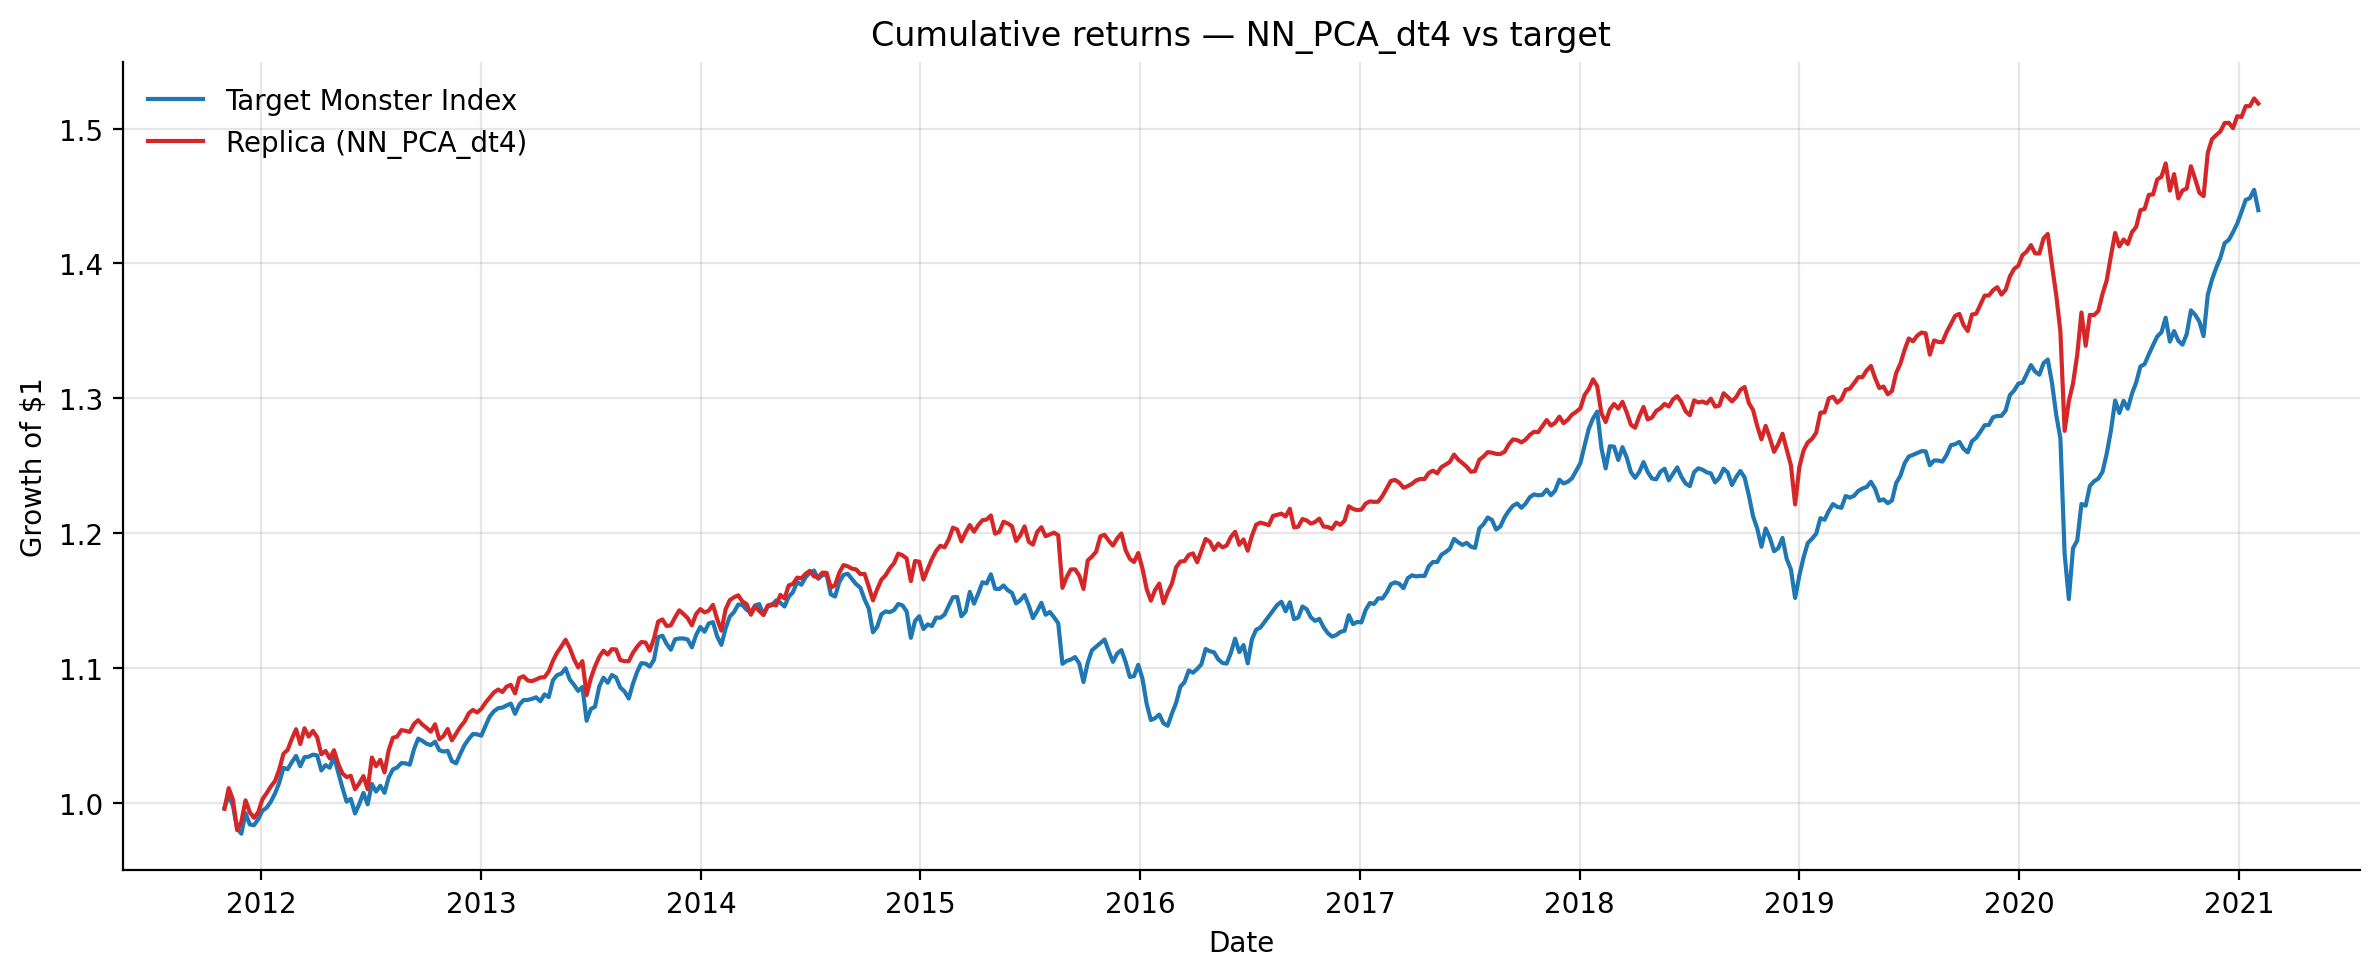

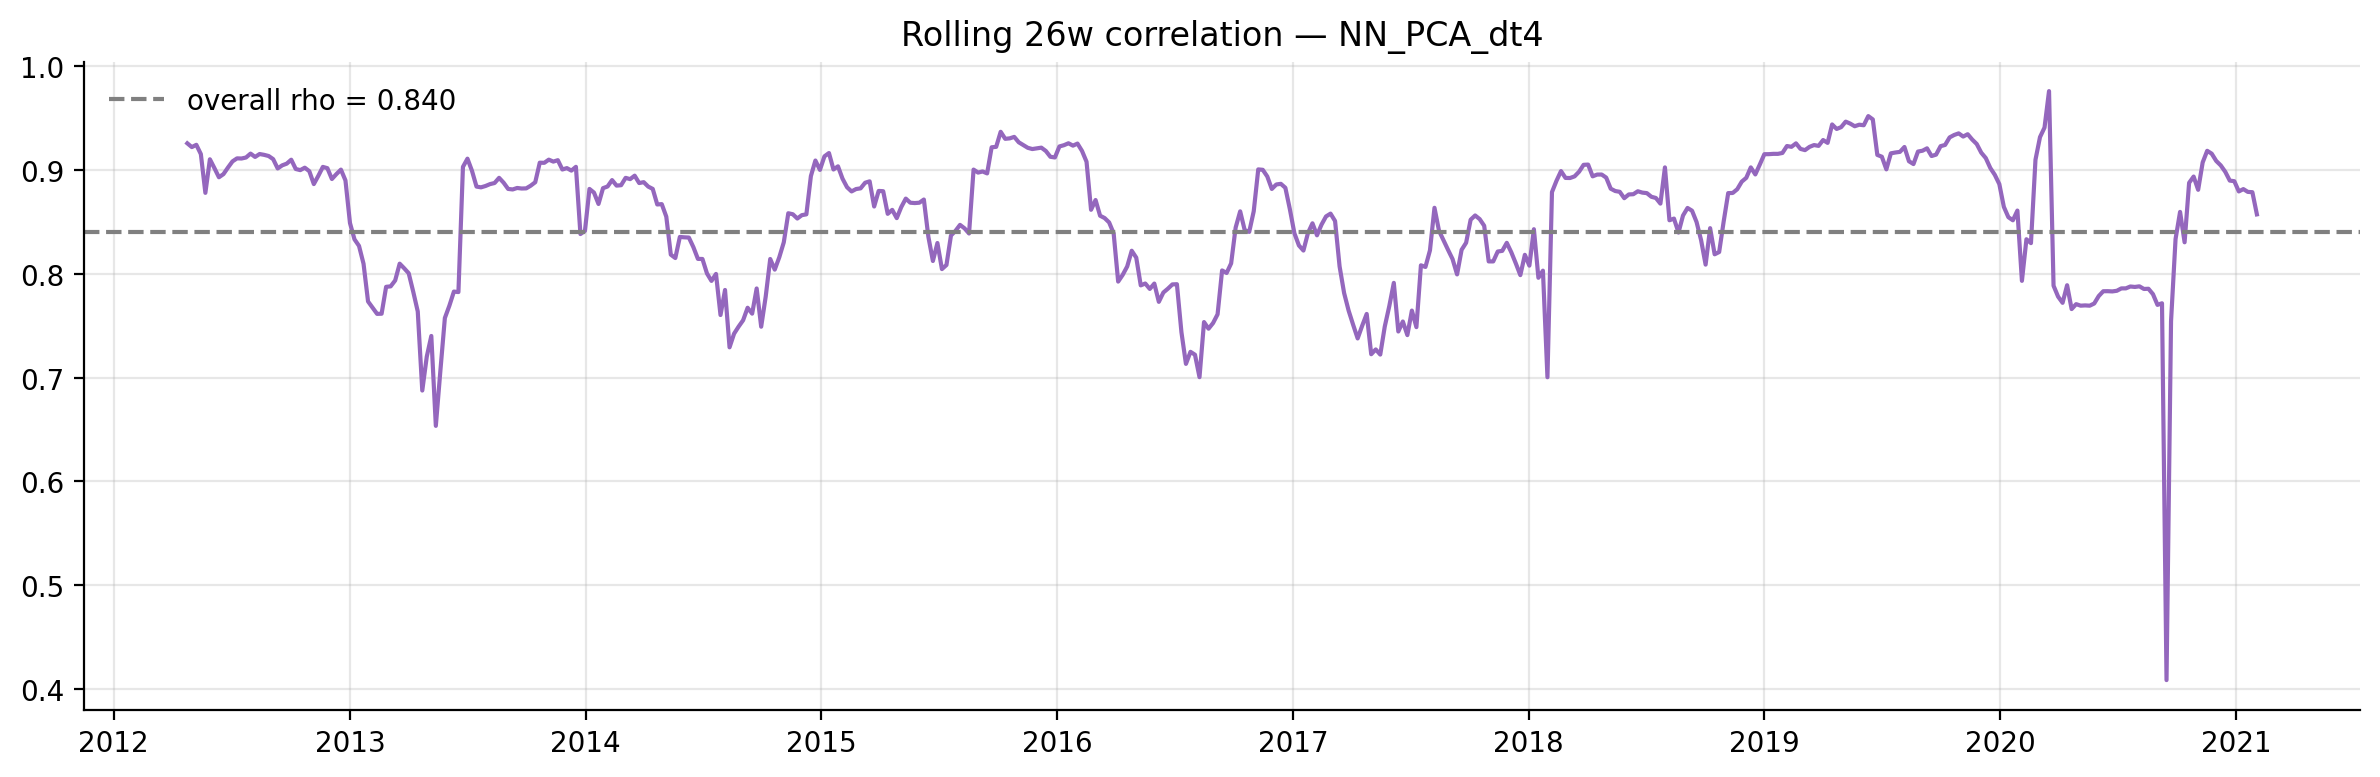

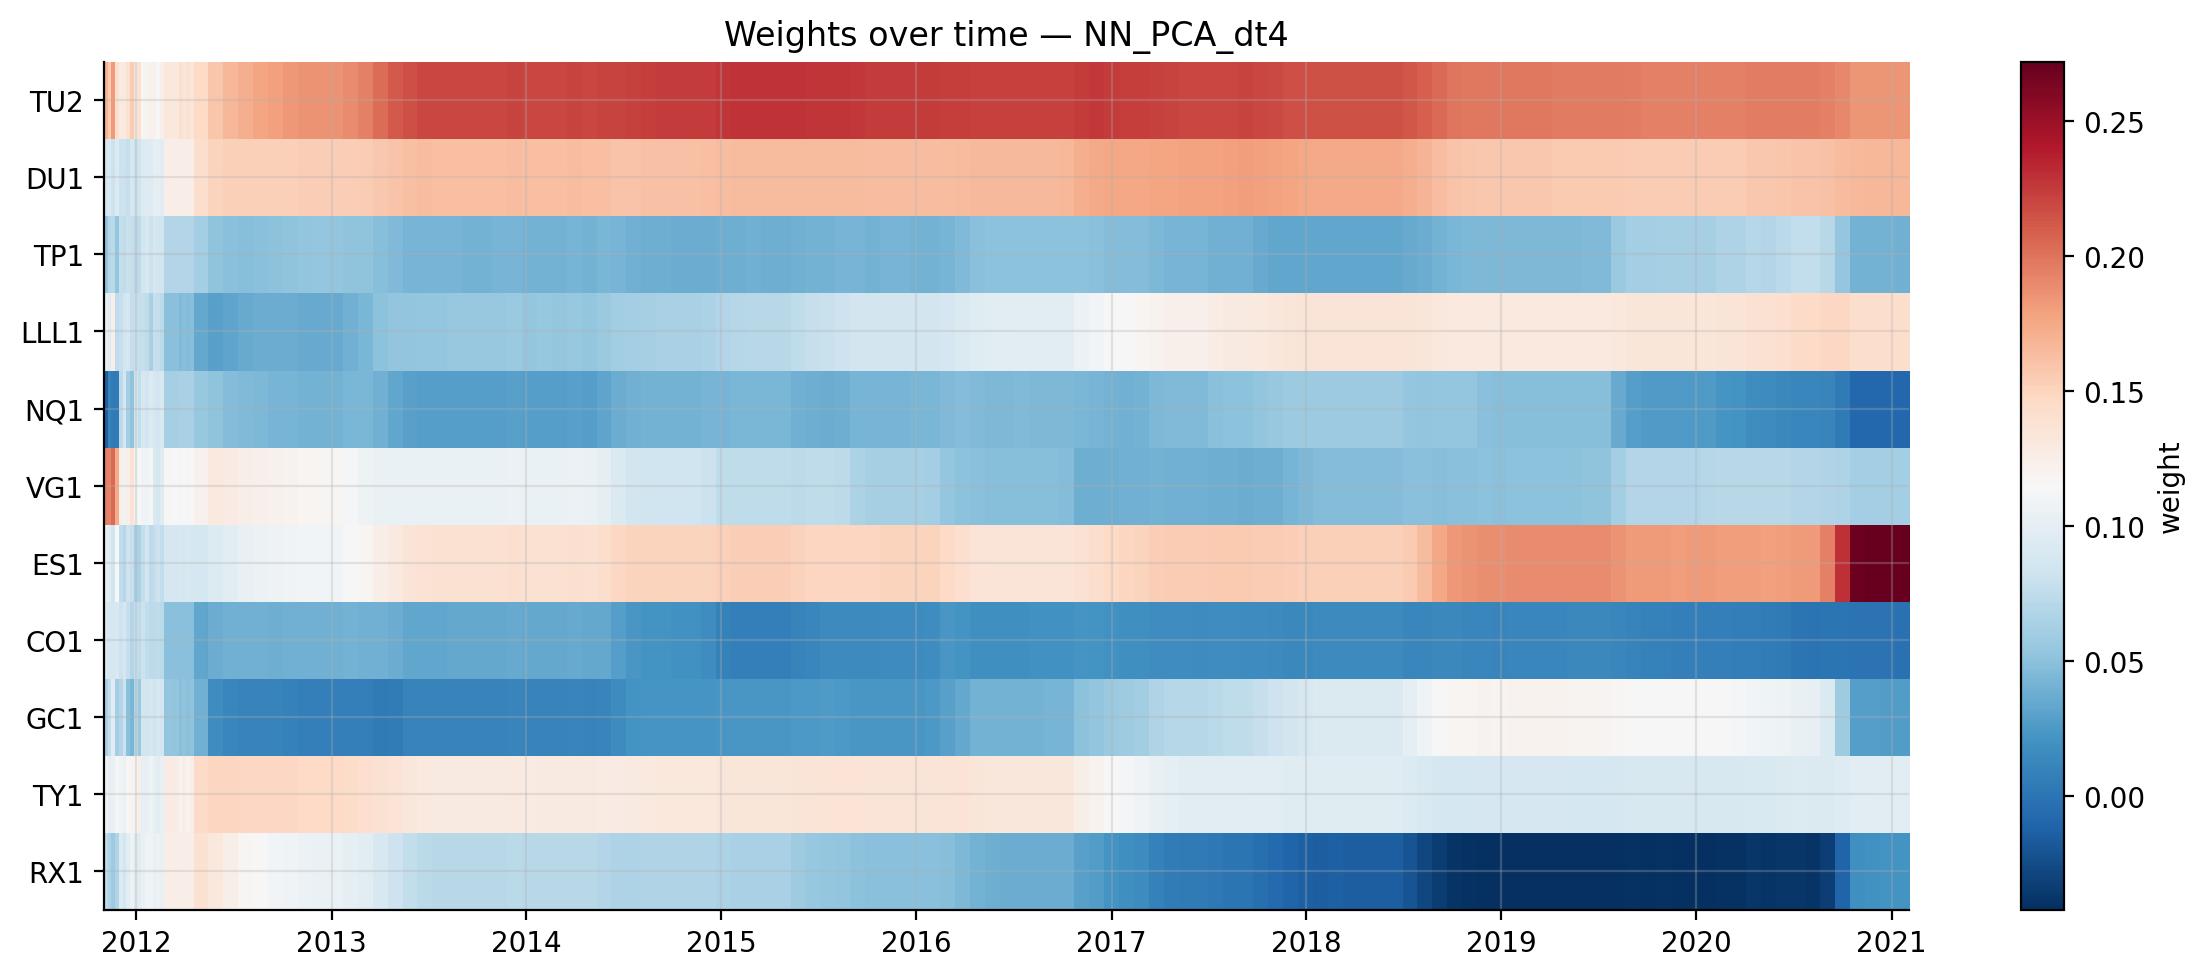

In [62]:
# Pick the best variant by net_IR for the spotlight plots.
best_name = master_table.index[0] if not master_table.empty else next(iter(nn_results))
best = registry[best_name]

target_oos = (
    best["target_returns"]
    if "target_returns" in best
    else y.loc[best["replica_returns"].index]
)
replica_oos = best["replica_returns"]
weights_df = best["weights_history"]

cum_target = (1.0 + target_oos).cumprod()
cum_replica = (1.0 + replica_oos).cumprod()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(
    cum_target.index, cum_target.values, label="Target Monster Index", color="tab:blue"
)
ax.plot(
    cum_replica.index,
    cum_replica.values,
    label=f"Replica ({best_name})",
    color="tab:red",
)
ax.set_title(f"Cumulative returns — {best_name} vs target")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
roll_corr = replica_oos.rolling(26).corr(target_oos)
ax.plot(roll_corr.index, roll_corr.values, color="tab:purple")
ax.axhline(
    best["metrics"]["rho"],
    color="grey",
    linestyle="--",
    label=f"overall rho = {best['metrics']['rho']:.3f}",
)
ax.set_title(f"Rolling 26w correlation — {best_name}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
heat = weights_df.T.values
extent = [
    mdates.date2num(weights_df.index[0]),
    mdates.date2num(weights_df.index[-1]),
    -0.5,
    weights_df.shape[1] - 0.5,
]
im = ax.imshow(heat, aspect="auto", extent=extent, cmap="RdBu_r", origin="lower")
ax.set_yticks(range(weights_df.shape[1]))
ax.set_yticklabels(weights_df.columns)
ax.xaxis_date()
ax.set_title(f"Weights over time — {best_name}")
fig.colorbar(im, ax=ax, label="weight")
plt.tight_layout()
plt.show()
